# Modelos de Series Temporais

Neste script axustaremos modelos de series temporais estudados no Máster aos nosos datos.

Cargamos as librarías precisas:

## Funcións

Comezamos cargando as funcións precisas para o traballo. Ditas funcións atópanse no script Funcións.ipnynb

In [1]:
# Básicas de manexo de datos
import pandas as pd
import numpy as np

# Visualización (por se queres facer algún plot rápido fóra das funcións)
import matplotlib.pyplot as plt
import seaborn as sns

import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats

# Configuración estética de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 3. A TÚA LIBRARÍA PERSONALIZADA ---
# Aquí cargamos todas as funcións que creamos (ARIMA, Métricas, Plots...)
import Funcions as ft

print("✅ Entorno configurado e librarías cargadas.")

✅ Entorno configurado e librarías cargadas.


## Lectura dos datos

Comezamos cargando os datos e vendo que non temos ningún problema.

In [2]:
ruta = 'TFM_datos_EDA.csv'
datos = ft.cargar_e_preparar_datos(ruta)

📂 Cargando datos dende: TFM_datos_EDA.csv
   ✅ Datos procesados: Atopáronse 3 clusters.


## Series de Tempo univariantes

O obxectivo do traballo é predecir o volume de pedidos futuros dun tipo de cliente dado.
Para comezar a análise da serie de tempo, debemos represntar o seu gráfico secuencial.

Imos crear un diccionario para gardar información sobre o Black Friday en cada cluster (e nomodelo xeral) e sobre os outliers:

In [3]:
# Diccionario global para gardar os datos procesados de cada modelo ARIMA
# Isto será o "input" para o Prophet despois
export_para_prophet = {}

# Dicionario para datos dos ARIMA
datos_arima = {}

fechas_bf = pd.to_datetime(['2022-11-21', '2023-11-20', '2024-11-25'])

### Modelo xeral

Comezamos axustando un modelo para predecir o volume de envíos en xeral, isto é, sen ter en conta a información do cliente.

In [4]:
df_global = datos['Global'].set_index('semana')

Comezaremos axustando un modelo de Box-Jenkins e avaliaremos o seu rendemento. Para iso, debemos dividir a serie nunha parte de entrenamento e outra de test. Daquela quedaremos coas semanas do 2025 para testear o modelo construído a partir da información dos anos 2022, 2023 e 2024.

#### Análise de intervención: efecto do Black Friday

Identificación do modelo:
1. Tipo de efecto (transitorio ou permanente)
2. Función de transferencia
3. Identificación do ARIMA

Comezamos entón representando o gráfico secuencial e vendo o impacto do Black Friday nos distintos anos:

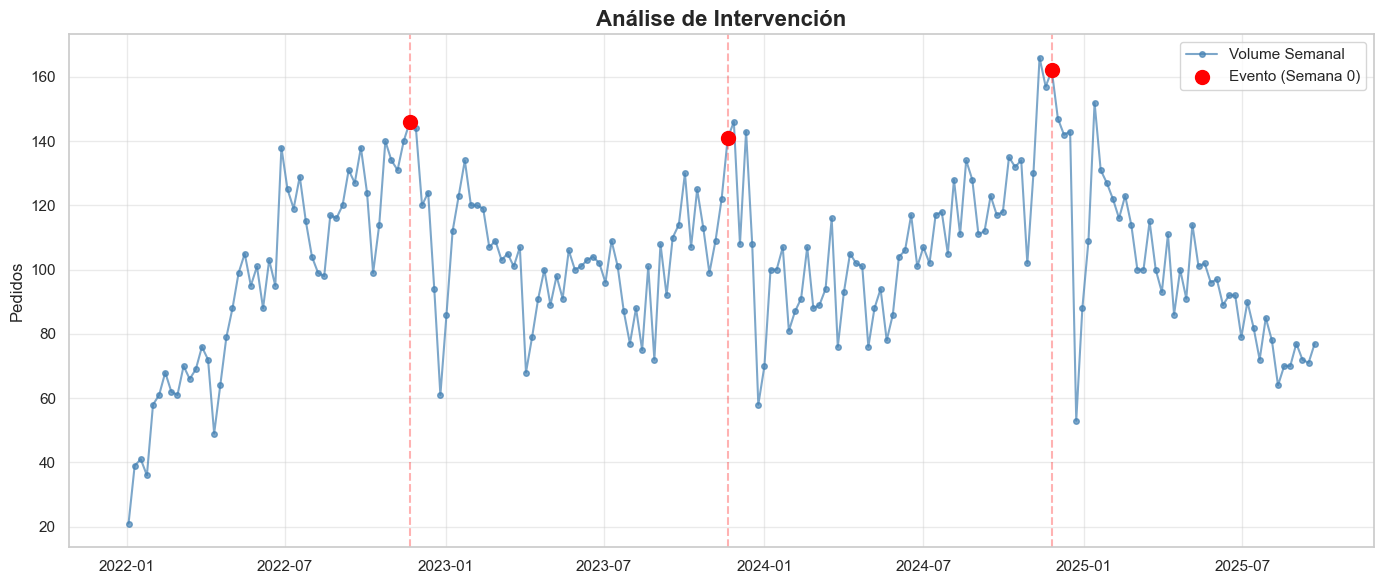

In [5]:
ft.plot_analisis_intervencion(df_input=df_global,
                              fechas_clave=fechas_bf)

**Nota**: Vemos a necesidade de plasmar o efecto do Black friday en semanas previas (seguramente 3) así como o impacto posterior (1-2 semanas). Como o modelo se axusta con variables dummys o efecto será o mesmo nos tres anos, co cal o modelo pode subestimar o pico de 2024 e sobreestimar o de 2022.

In [6]:
modelo = 'Global'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_global)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=2 
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q)X(P,D,Q)

Unha vez feita a análise de intervención, imos ver que modelo ARIMA se axusta mellor. Comezamos cunha interpretación gráfica para ter unha primeira idea.

#### Gráfico secuencial, fas e fap

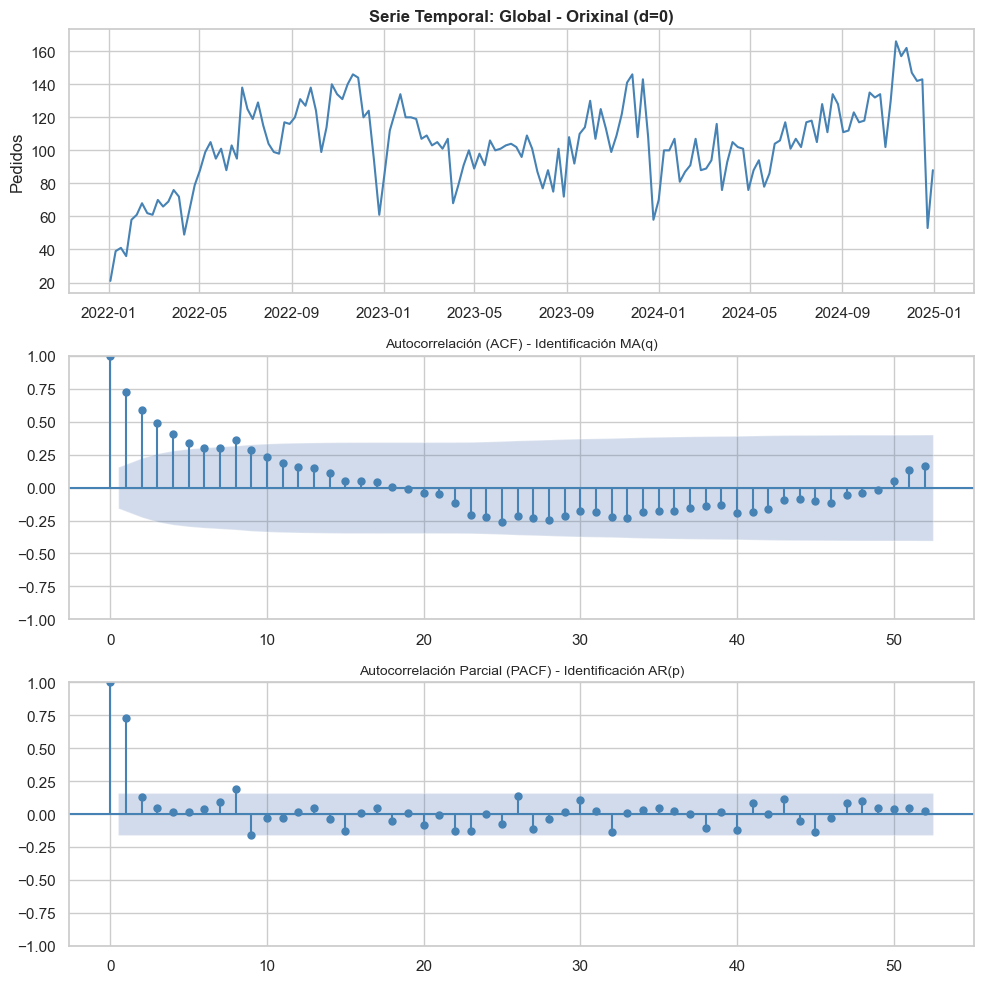

In [7]:
modelo = 'Global'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{'Global'} - Orixinal (d=0)"
)

Observando as gráficas, non parece que telamos problema de heterocedasticidade. Ademáis, en contra do que podiamos supoñer (por ser datos medidos en varios anos), tampouco presenciamos estacionalidade (que se observaría na gráfica das fas unha forte correlación positiva no retardo estacional). O único a sinalar é unha lixeira tendencia positiva. Podemos daquela diferenciar a serie (d=1) e repetir os gráficos:

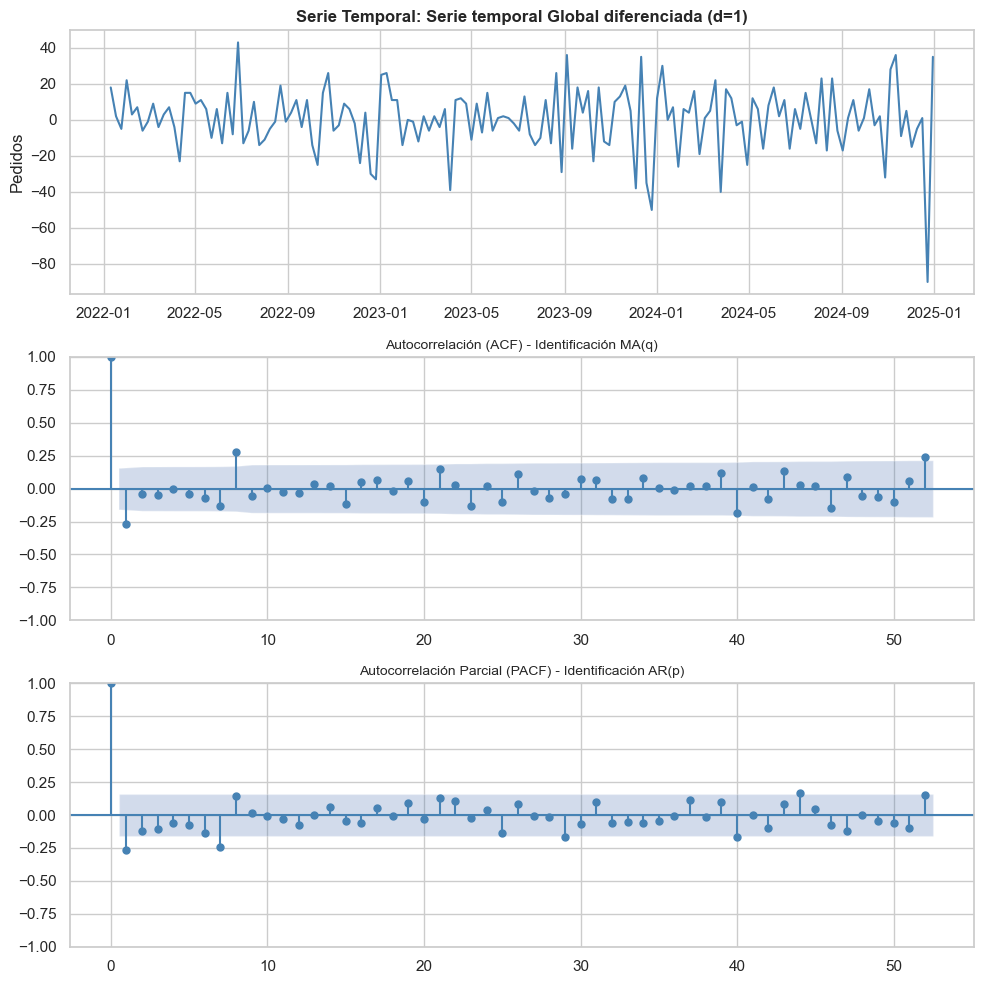

In [8]:
y_diff = datos_arima[modelo]['y_train'].diff().dropna()

ft.plot_identificacion_arima(
    y_diff,
    lags=52,
    titulo='Serie temporal Global diferenciada (d=1)'
)

Así, as gráficas suxiren que a serie diferenciada:
1. É estacionaria
2. Foi xerada por un proceso AR(1) ou MA(1).

Polo tanto, a serie orixinal parece compatible ou ben cun ARIMA(1,1,0) ou un ARIMA(0,1,1).

#### Selección do modelo mediante AIC

Unha vez proposto un primeiro modelo que poida explicar o comportamento da nosa serie, imos elixir o modelo que minimice o AIC:

In [9]:
modelo = 'Global'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1350.195, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1336.811, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1327.110, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1348.286, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1326.141, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1328.035, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1328.074, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1326.788, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1334.606, Time=0.13 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1326.653, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1325.080, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1325.588, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1334.927, Time=0.19 sec
 ARIMA(2,1,1)(0,0,0)[0]             :

In [10]:
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (1, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1334.927098449461


In [11]:
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 1)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima['Global']['y_train'], 
                X = datos_arima['Global']['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1325.5878636374523


Agora ben, comparemos o AIC do mellor modelo, que neste caso sae un ARIMA(1,1,1) sen constante, co AIC do modelo suxerido pola interpretación gráfica, ARIMA(1,1,0) ou ARIMA(0,1,1). En particular, o ARIMA(1,1,1) ten un AIC = 1327.71 e o ARIMA(0,1,1) un AIC = 1328.79, co cal (ao distar menos de dúas unidades) quedaremos con este segundo.

In [12]:
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -657.794
Date:                Tue, 23 Dec 2025   AIC                           1325.588
Time:                        16:35:31   BIC                           1340.837
Sample:                    01-03-2022   HQIC                          1331.781
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre        20.3568      6.991      2.912      0.004       6.654      34.060
bf_peak       34.0691     13.697      2.487      0.013       7.224      60.914
bf_post       22.3554      5.306      4.213      0.0

Unha vez identificado o modelo debemos axustalo e ver se se detectan algúns atípicos.

#### Detección de atípicos (aditivos e innovativos)

Antes de facer o estudo dos residuos, estudemos a posible presenza de datos atípicos na serie de tempo. Existen dous tipos de atípicos: 
1. Atípicos Aditivos (AO): o valor da **serie** no isntante t=h foi xerado de forma distinta ao resto.
2. Atípicos Innovativos (IO): o valor da **innovación** no instante t=h  foi xerado de forma distinta ao resto.

In [13]:
modelo = 'Global'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y= datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order


🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.82 > 3.59
   [Iter 2] Detectado: 2023-12-25 | t-stat: 3.74 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.11). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.821211     1  Negativo
1 2023-12-25 -3.735505     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20231225
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Detectamos daquela 2 atípicos: na semana do 23-12-2024 e na semana de 25-12-2023. A maneira de proceder será incluír o impacto de atípico con menor p-valor (o de estatístico máis grande en valor absoluto) mediante unha variable dummy (variable que toma o valor 1 no intre t=h e 0 no resto de casos) e axustamos un novo modelo incluíndo dita variable como variable exóxena:

#### Estimación ou axuste do modelo

In [14]:
modelo = 'Global'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima['Global']['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order=datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -634.506
Date:                Tue, 23 Dec 2025   AIC                           1283.011
Time:                        16:35:31   BIC                           1304.270
Sample:                    01-03-2022   HQIC                          1291.646
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              17.0100      5.987      2.841      0.004       5.277      28.744
bf_peak             28.9619     11.723     

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fixado un nivel de significación do 5% o termo correspondente ao efecto pre-black_friday non sería significativo. Porén, como só dispoñemos de 3 anos de histórico, pode ser que o efecto captado por dita variable non sexa moi significativo mais non o eliminaremos do modelo.

Vemos como todos os coeficientes do modelo son significativos. Pasamos entón a facer a análise dos residuos e validar o modelo.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as onnovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

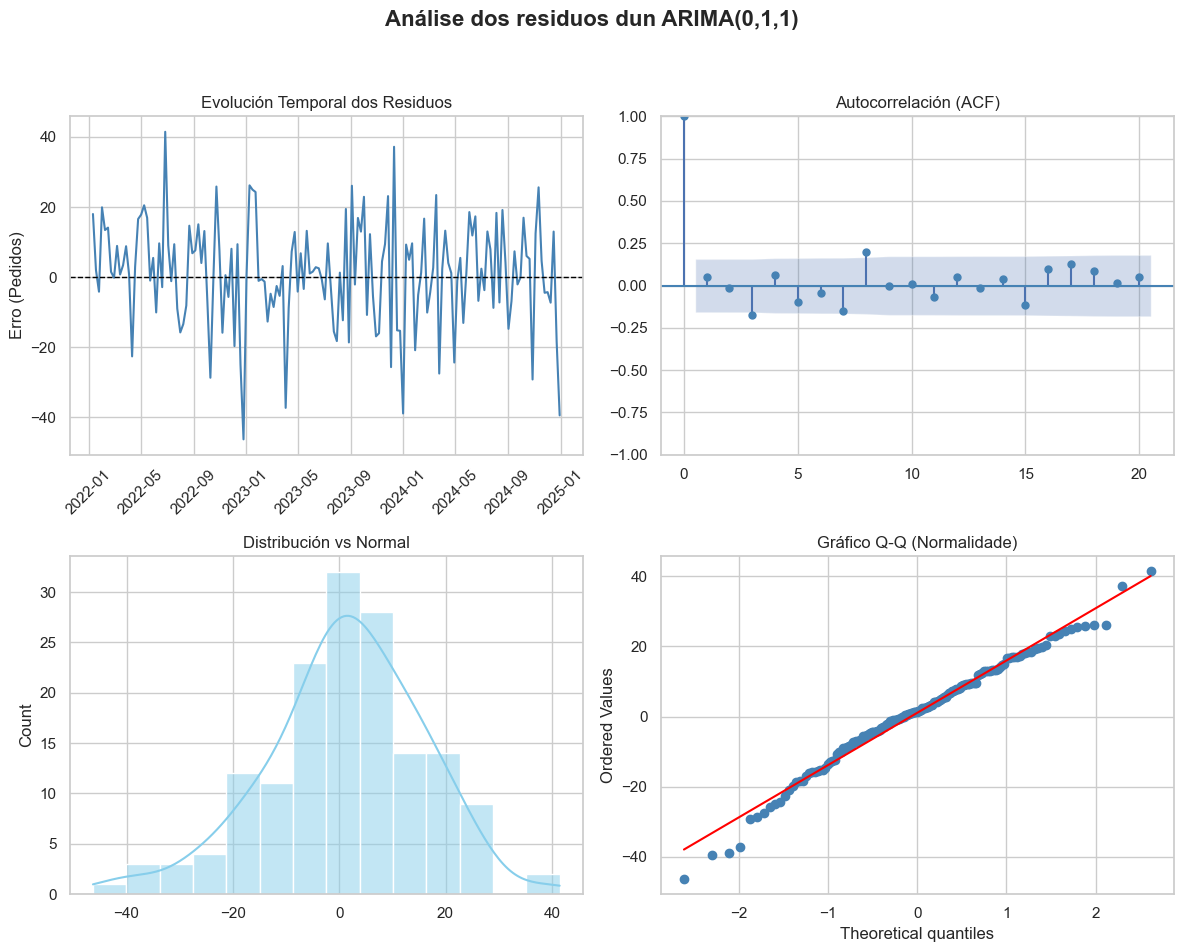


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,1) ---
1️⃣  Sesgo (Media=0):  p-value = 0.3700 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0909 ✅ (Aceptamos H0: Residuos normais)
------------------------------------------------------------


In [15]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,1)')

In [16]:
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -634.506
Date:                Tue, 23 Dec 2025   AIC                           1283.011
Time:                        16:35:32   BIC                           1304.270
Sample:                    01-03-2022   HQIC                          1291.646
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              17.0100      5.987      2.841      0.004       5.277      28.744
bf_peak             28.9619     11.723      2.470      0.013       5.985      51.939
bf_post             15.8726 

Na saída do summary podemos atopar os estatísticos e os p-valores asociados aos distintos contrastes. Fixando un nivel de significación do 5% terase que:

$\cdot$ Homocedasticidade: (test F), tense que o p-valor é 0.65, co cal non se rexeita a hipótese de homocedasticidade.

$\cdot$ Incorrelación: contraste de Ljung-Box, o p-valor é 0.51, polo tanto non se rexeita a hipótese de residuos incorrelados.

$\cdot$ Media cero: mediante o t-test, o p-valor é 0.3825 polo que podemos asumir que a media dos residuos é 0.

$\cdot$ Normalidade: contraste de Jarque-Bera (JB), o p-valor = 0.04 < 0.05, co cal rexeitariamos a hipótese de normalidade. En cambio o contraste de Shapiro-Wilk non rexeitaría dita hipótese, pois ten un p-valor asociado de 0.058. 
O contraste de Jarque-Bera baséase na simetría e curtose, co cal é moi sensible ás colas pesadas. Daquela, como co teste de Shapiro non rexeitamos, asumiremos a normalidade dos residuos. 

**Nota**: o non cumplimento da hipótese de normalidade non nos invalida o modelo, mais á hora de facer as predicións non poderemos "garantir" o nivel de confianza dos intervalos que construiremos en base á distribución do erro de predición. Daquela, faremos as predicións mediante bootstrap.

#### Predicións

**Nota**: para un estudo máis "realista" do rendemento do modelo imos facer \textit{Rolling-Window}. Este procedemento consiste en ir predicindo semana a semana, isto é, cada semana que pasa o dato real incorpórase ao histórico. Esta forma de proceder é a máis correcta para os intereses da empresa. Non queremos predecir os pedidos de todo o ano, senón que prepararnos para a demanda das vindeiras datas, co cal ten sentido que o modelo se vaia actualizando semana a semana. Aínda así, sinalemos que a metodoloxía de dividir en train (2022-2024) e test (2025) é correcta na construción do modelo.

Como o que nos interesa a nós é ver o rendemento do modelo, comparando as predicións cos valores reais para a mostra de test, non precisaremos de apoiarnos no bootstrap.

Debemos crear. parte test das variables exóxenas incluídas:

--- 🔮 VALIDACIÓN ROLLING WINDOW: Global ---
   Variables en modelo: 5
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   > Semana 10/38: Pred=110.54


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 20/38: Pred=102.24


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

   > Semana 30/38: Pred=79.61


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: M

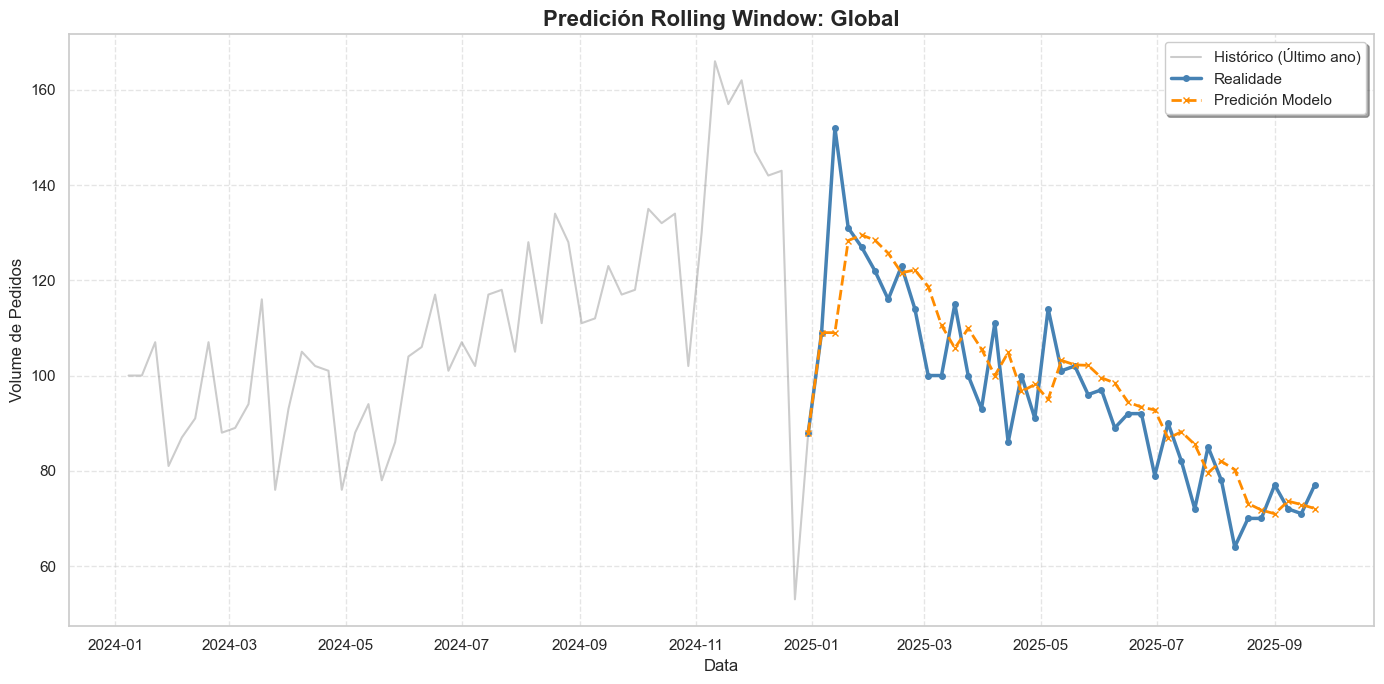

In [17]:
modelo = 'Global'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

Para avaliar o rendemento do modelo, imos calcular varias medidas do erro, é dicir, imos calcular o erro das predicións con respecto aos datos reais (datos de test):

In [18]:
modelo = 'Global'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Global (Rolling) ---
MAE:  7.90
RMSE: 11.15
MAPE: 8.18%
MASE: 0.60 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Os máis interpretables serían o MAPE e o MASE.
O MAPE sería como unha medida de porcentaxe do erro e observamos como co modelo actual temos un erro do 8.18%.
Pola súa parte, o MASE interpretaríase como unha proporción. Compara o erro do noso modelo co erro cometido polo preditor Naïve. Como MASE= 0.60, indica que o noso modelo ten un peor rendemento que o preditor Naïve.

Agora gardamos a información deste modelo para empregar no modelo Prophet:

In [19]:
modelo = 'Global'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Global ---
   💾 Empaquetando datos de Global para Prophet...

✅ Datos exportados para Global.
   Dimensións: (195, 7)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_pre  bf_peak  bf_post  outlier_20241223  \
190 2025-08-25         70       0        0        0                 0   
191 2025-09-01         77       0        0        0                 0   
192 2025-09-08         72       0        0        0                 0   
193 2025-09-15         71       0        0        0                 0   
194 2025-09-22         77       0        0        0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Modelo por cluster

Agora vamos a axustar un modelo que distinga en función do tipo de cliente para o que queramos predecir o volume de envíos. Daquela o que faremos será axustar un modelo ARIMA para cada tipo de cluster.

### Cluster 1

Comezamos polo primeiro cluster, que estaba formado polos clientes dos sectores de transporte, retail e electrónica.

In [20]:
df_cluster_1 = datos['Cluster 1'].set_index('semana')

#### Análise de intervención: Black Friday

Repetimos o procedemento anterio neste caso para os clientes do cluster 1.

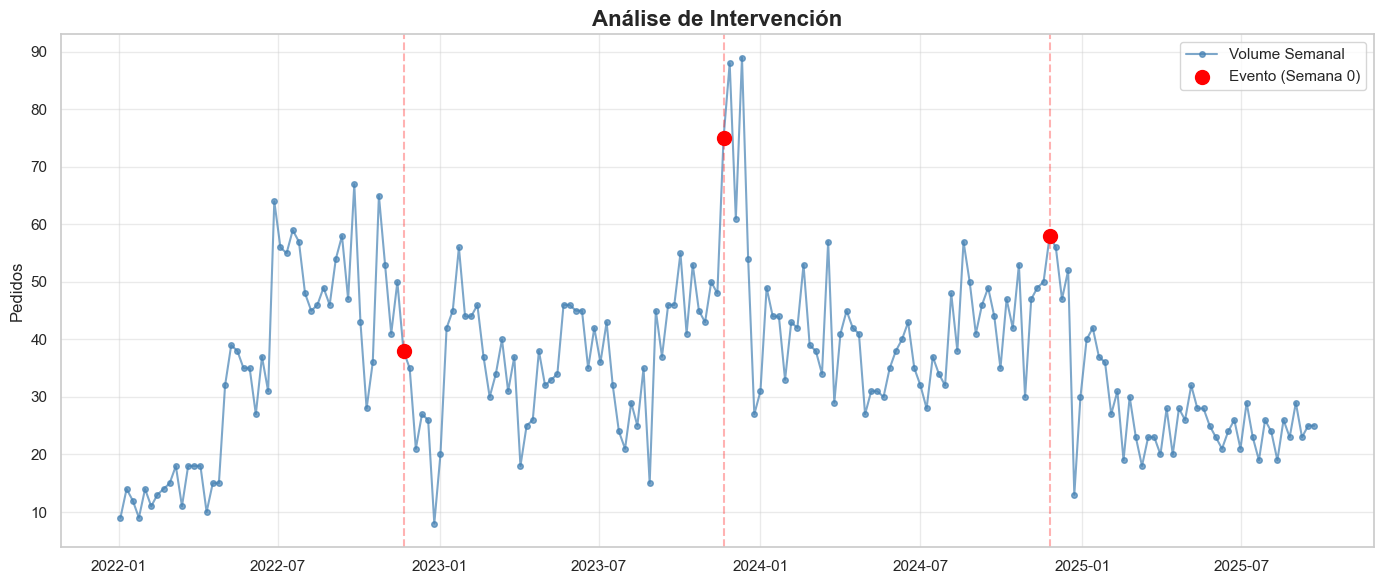

In [21]:
ft.plot_analisis_intervencion(df_input=df_cluster_1,
                              fechas_clave=fechas_bf)

Aquí vemos como o efecto do Black-Friday cambia drasticamente. Por unha parte, non parece apreciarse efecto previo á semana do evento (en particular no 2022 vese caída nas semanas previas). Ademáis, o efecto nas semanas posteriores é de caída nos anos 2022 e 2024 mentres que no 2023 si provoca un pico. Suxerencia: modelar o efecto do B-F con tres variables dummy que capten o efecto da semana anterior, a do propio evento e a posterior.

In [22]:
modelo = 'Cluster 1'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_1)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )
cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

Comezamos pola interpretación gráfica:

#### Gráfico secuencial, fas e fap

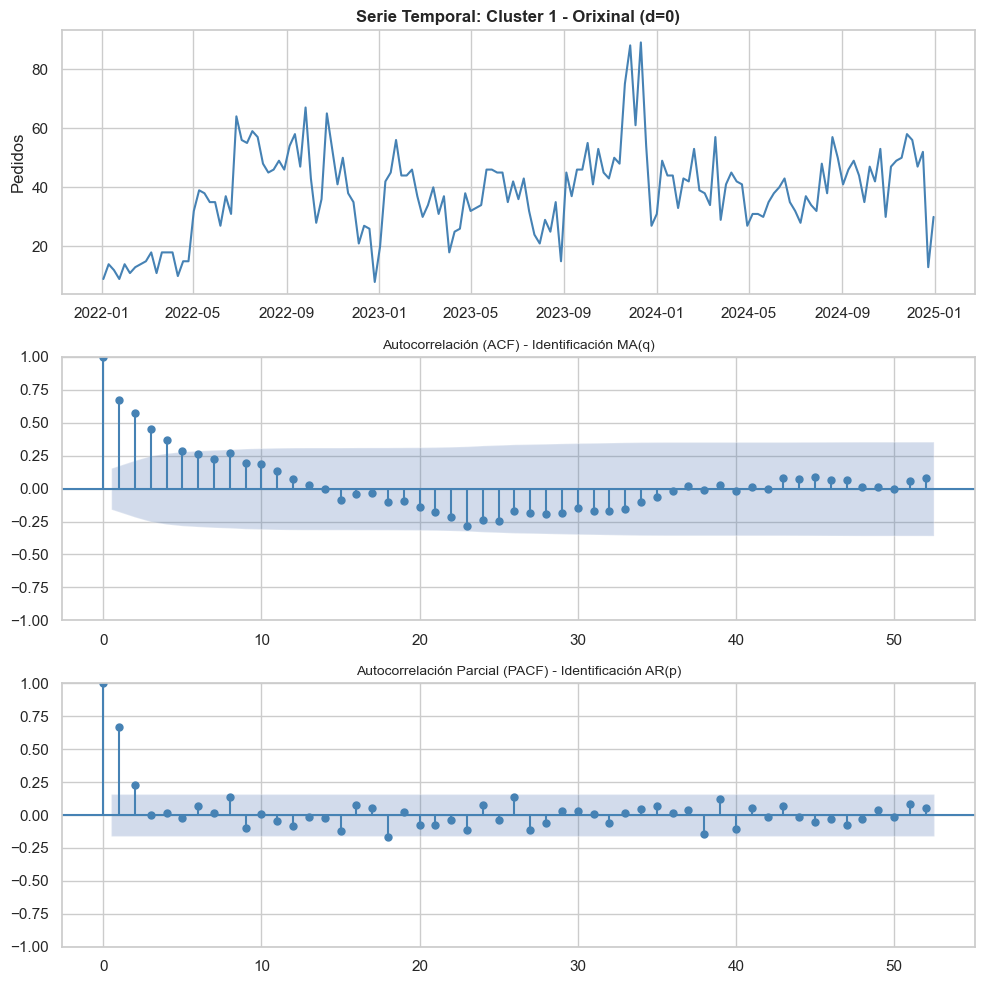

In [23]:
modelo = 'Cluster 1'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

De forma similar ao caso anterior, non observamos nin problemas de heterocedasticidade nin estacionalidade (gráfico secuencial e fas mostrais respectivamente). Porén, o único a sinalar sería unha certa tendencia positiva que podemos correxir aplicando unha diferencia regular (d=1) e repetindo os gráficos.

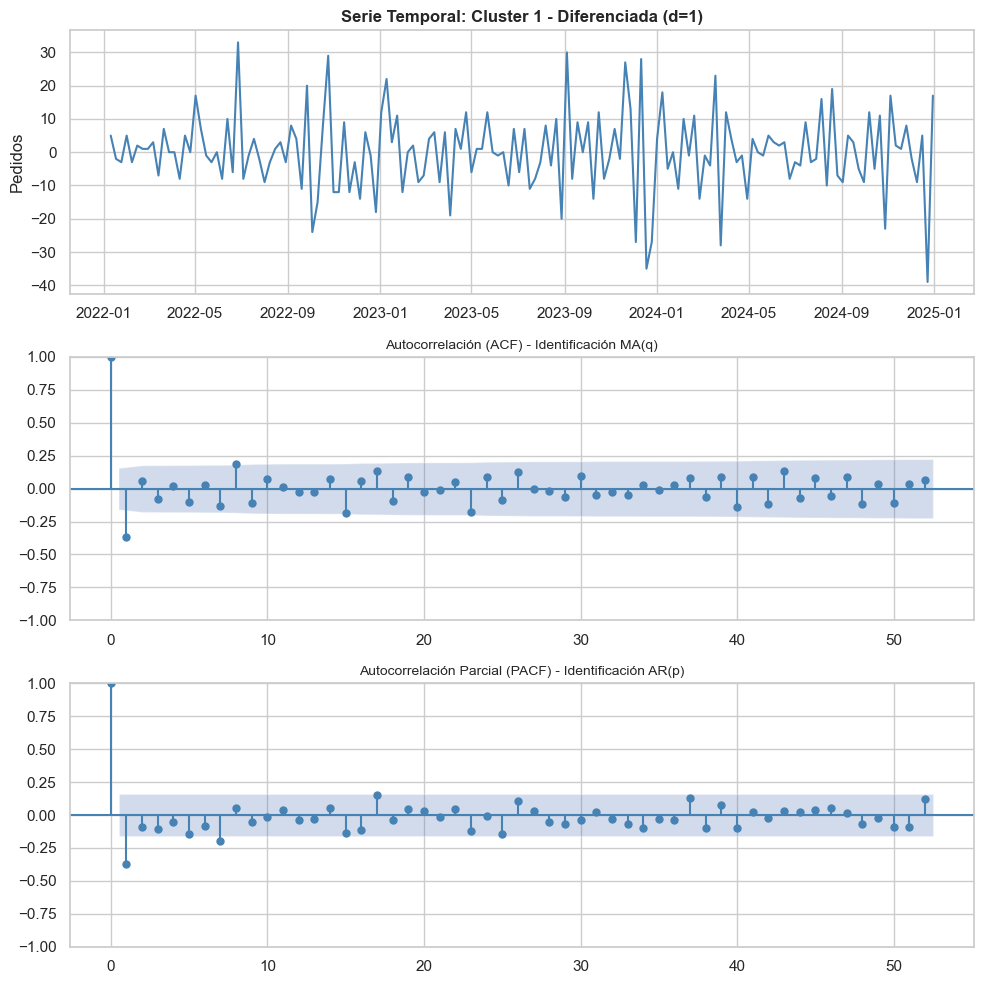

In [24]:
modelo = 'Cluster 1'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Unha vez diferenciada a serie, o gráfico secuencial e as fas e fap mostrais suxiren:
1. Serie estacionaria
2. Foi xerada por un MA(1) ou ben AR(1)

Polo tanto, a serie orixinal pode ser compatible cun ARIMA(1,1,0) ou ben ARIMA(0,1,1).

#### Selección do modelo mediante AICc

Unha vez suxerido un modelo que poida explicar a nosa serie, imos seleccionar aquel que minimiza o AIC

In [25]:
modelo = 'Cluster 1'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1212.044, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1192.155, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1186.562, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1210.065, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1185.673, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1187.016, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1192.152, Time=0.17 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1186.000, Time=0.25 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1183.948, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1184.645, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1190.179, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1184.

In [26]:
modelo = 'Cluster 1'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 1)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 1) axustado correctamente.
AIC = 1184.6449757991013


In [27]:
modelo = 'Cluster 1'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (1, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (1, 1, 0) axustado correctamente.
AIC = 1190.1790246533055


Mediante o criterio do AIC quedariamos cun ARIMA(1,1,2) sen constante. Polos métodos gráficos suxeriamos ou ben un ARIMA(1,1,0) ou ben un ARIMA(0,1,1). Como vemos o AIC do modelo óprimo é 1183.63, mentres que o do ARIMA (0,1,1) é 1184.64. Así, como dista en menos de dúas unidades, quedaremos co modelo máis sinxelo, i. e., ARIMA(0,1,1).

In [28]:
manual_order = (0,1,1)
print(model_manual.summary())
best_order = manual_order

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  157
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -590.090
Date:                Tue, 23 Dec 2025   AIC                           1190.179
Time:                        16:35:44   BIC                           1205.428
Sample:                    01-03-2022   HQIC                          1196.373
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         2.2545     12.045      0.187      0.852     -21.353      25.862
bf_peak       10.7478      7.442      1.444      0.149      -3.837      25.333
bf_post       11.7301      7.971      1.472      0.1

#### Detección de atípicos (aditivos e innovativos)

Fagamos agora o contraste de detección de outliers do mesmo xeito que no caso anterior:

**Nota**: xa temos a función construída.

In [29]:
modelo = 'Cluster 1'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

# Gardamos este novo X (que agora ten BF + Outliers) nun novo dicionario
# Este será o input para a seguinte fase (Refinado / Backward Elimination)
if 'datos_arima_final' not in locals():
    datos_arima_final = {}

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...


   [Iter 1] Non se atoparon máis atípicos significativos (Max t: 3.58). Fin.
   ✅ Non se atoparon outliers.
Empty DataFrame
Columns: [fecha, t_stat, iter, tipo]
Index: []
            bf_pre  bf_peak  bf_post
semana                              
2022-01-03       0        0        0
2022-01-10       0        0        0
2022-01-17       0        0        0
2022-01-24       0        0        0
2022-01-31       0        0        0


Non se atoparon atípicos.

#### Estimación ou axuste do modelo

Unha vez visto que non se detectan atípicos, axustemos o modelo e vexamos se todos os coeficientes son significativos ou non:

In [30]:
modelo = 'Cluster 1'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 1) con 3 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.602
Date:                Tue, 23 Dec 2025   AIC                           1171.205
Time:                        16:35:44   BIC                           1186.390
Sample:                    01-03-2022   HQIC                          1177.373
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         3.8554     12.157      0.317      0.751     -19.972      27.683
bf_peak       12.1533      6.399      1.899      0.058      -

Vemos como o efecto do pre-Black-Friday non é nada significativo (p-valor = 0.76). Polo tanto pasaremos a axustar o modelo sen dita variable dummy.

In [31]:
modelo = 'Cluster 1'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 1) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.842
Date:                Tue, 23 Dec 2025   AIC                           1169.685
Time:                        16:35:44   BIC                           1181.833
Sample:                    01-03-2022   HQIC                          1174.619
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak       10.9096      3.90

Vemos como agora todos os coeficientes son significativos.

#### Diagnose ou análise dos residuos

Imos comprobar as hipóteses do modelo e ver así se o modelo axustado é válido. 
A hipótese fundamental a contrastar é a que esixe que as innovacións $\{a_t\}$ sexan ruído blanco, isto é:
1. Media cero
2. Homocedasticidade
3. Incorreladas

Graficamente:

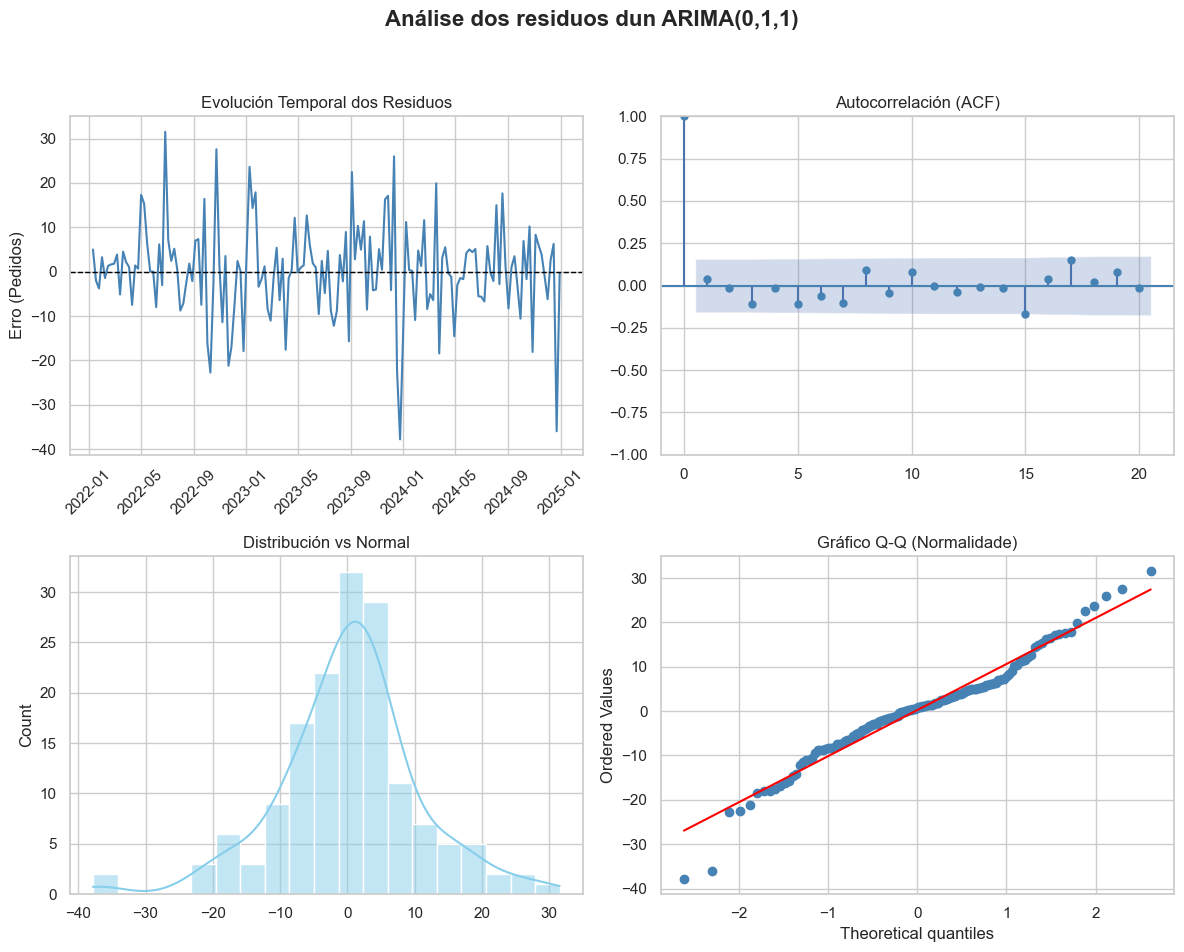


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,1) ---
1️⃣  Sesgo (Media=0):  p-value = 0.7809 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0006 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [32]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,1)')

Graficamente, no gráfico secuencial da serie non observamos problemas de heterocedasticidade. Nas fas mostrais tampouco vemos problemas de correlación. Ademáis, vendo o histograma e o QQ-plot, pode verse unha distribución con certa asimetría polo que é posible que falle a normalidade dos residuos.

Debemos facer os contrastes numéricos para asegurarnos do cumprimento das hipóteses do modelo.

In [33]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -580.842
Date:                Tue, 23 Dec 2025   AIC                           1169.685
Time:                        16:35:44   BIC                           1181.833
Sample:                    01-03-2022   HQIC                          1174.619
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak       10.9096      3.904      2.794      0.005       3.257      18.562
bf_post       14.6116      4.420      3.306      0.001       5.949      23.274
ma.L1         -0.4801      0.068     -7.010      0.000      -0.614      -0.346
sigma2       110.5210      9.272     11.920      0.000      92.349     128.693
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                21.32
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               0.75   Skew:                            -0.25
Prob(H) (two-sided):                  0.30   Kurtosis:                         4.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Na saída do summary podemos atopar os estatísticos e os p-valores asociados aos distintos contrastes. Fixando un nivel de significación do 5% terase que:

$\cdot$ Homocedasticidade: contraste de Breusch-Pagan (test F), tense que o p-valor é 0.30, co cal claramente non se rexeita a hipótese de homocedasticidade.

$\cdot$ Incorrelación: contraste de Ljung-Box, o p-valor é 0.64, polo tanto non se rexeita a hipótese de residuos incorrelados.

$\cdot$ Media cero: mediante o t-test, o p-valor é 0.78 polo que podemos asumir que a media dos residuos é 0.

$\cdot$ Normalidade: contraste de Jarque-Bera (JB), o p-valor < 0.05, co cal rexeitariamos a hipótese de normalidade (co test de shapiro tamén rexeitariamos dita hipótese). Porén, o non cumplimento da hipótese de normalidade non nos invalida o modelo, mais á hora de facer as predicións non poderemos "garantir" o nivel de confianza dos intervalos que construiremos en base á distribución do erro de predición.

#### Predicións

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 1 ---
   Variables en modelo: 2
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (0, 1, 1)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=25.25
   > Semana 20/38: Pred=28.43
   > Semana 30/38: Pred=21.69


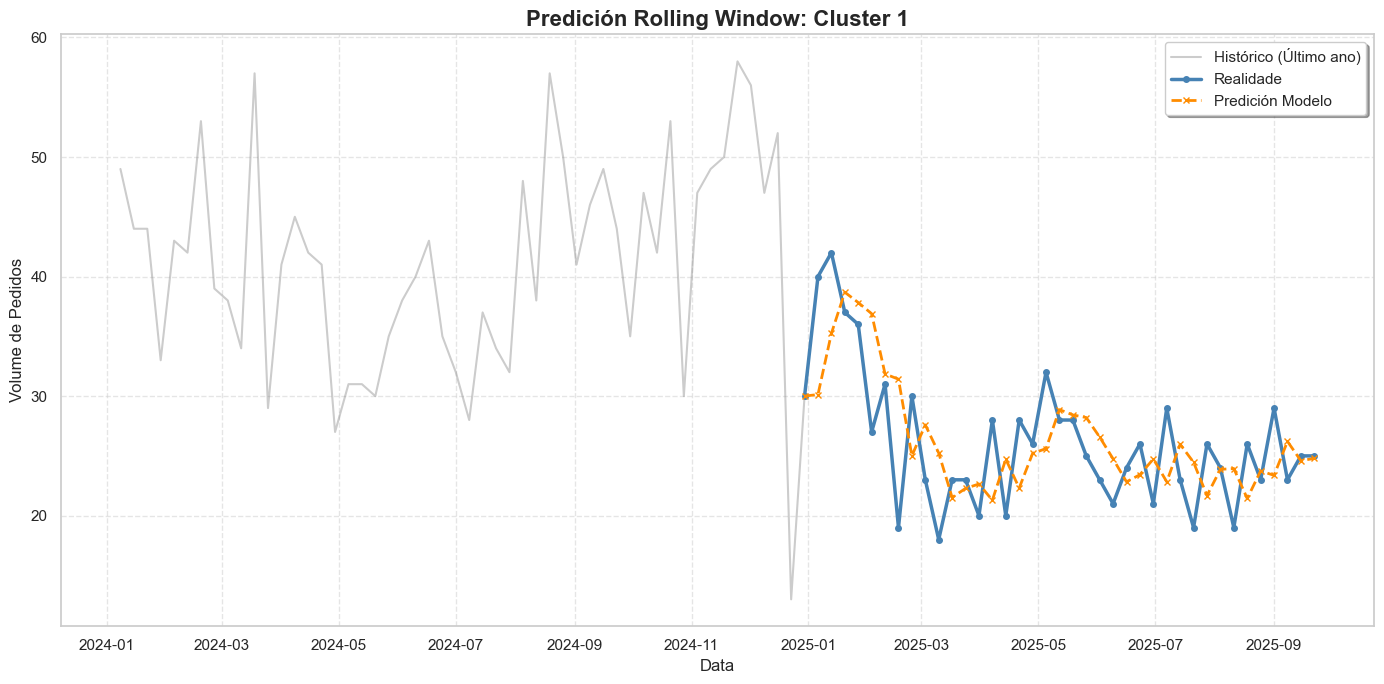

In [34]:
modelo = 'Cluster 1'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)
# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling
# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [35]:
modelo = 'Cluster 1'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Cluster 1 (Rolling) ---
MAE:  3.88
RMSE: 4.85
MAPE: 15.57%
MASE: 0.45 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Temos un MAPE = 15.57 % e un MASE = 0.45. Daquela temos uns grandes resultados.

Gardamos a información de atípicos e análise de intervención para empregar no Prophet:

In [36]:
modelo = 'Cluster 1'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 1 ---
   💾 Empaquetando datos de Cluster 1 para Prophet...

✅ Datos exportados para Cluster 1.
   Dimensións: (195, 4)
   Columnas incluídas: ['semana', 'n_pedidos', 'bf_peak', 'bf_post']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  bf_peak  bf_post
190 2025-08-25         23        0        0
191 2025-09-01         29        0        0
192 2025-09-08         23        0        0
193 2025-09-15         25        0        0
194 2025-09-22         25        0        0


### Cluster 2

Pasamos agora a axustar un modelo ARIMA para o cluster formado polos clientes de paquetería e froita.

In [37]:
df_cluster_2 = datos['Cluster 2'].set_index('semana')

#### Análise de intervención: Black Friday

Novamente repetimos a análise do impacto do Black Friday, agora sobre os clientes do segundo cluster.

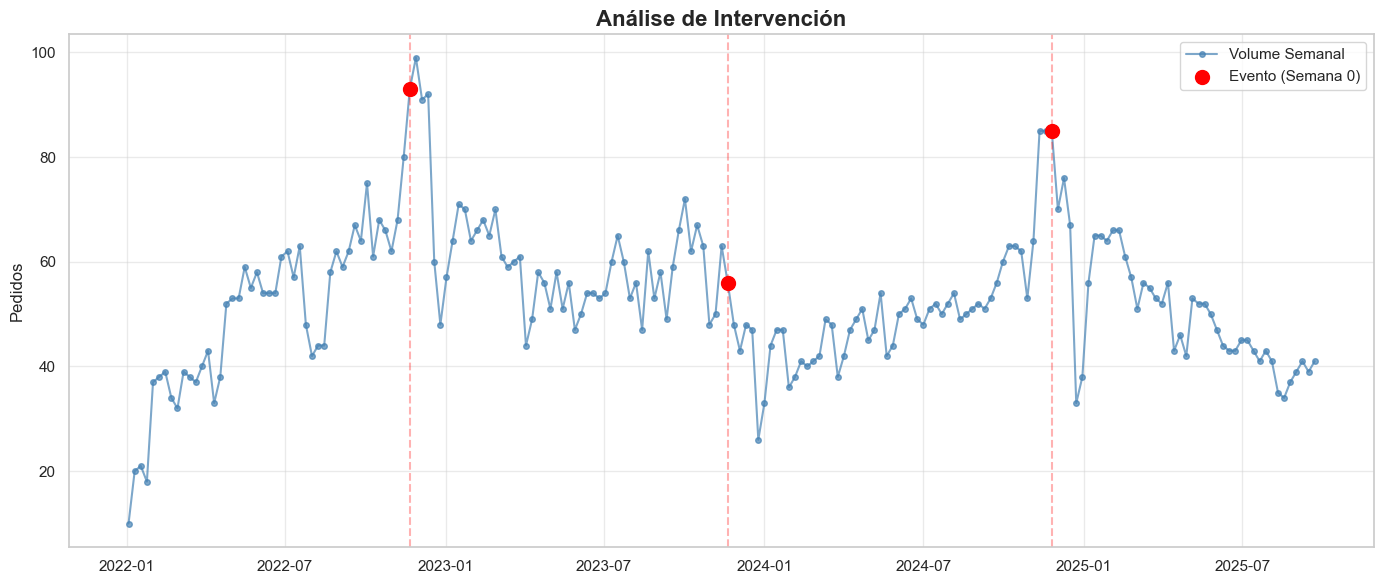

In [38]:
ft.plot_analisis_intervencion(df_input=df_cluster_2,
                              fechas_clave=fechas_bf)

Graficamente, vemos como o efecto previo do B-F se extende pricipalmente ás dúas semanas anteriores (sobre todo no 2022 e 2024). Ademáis, no 2022 observamos como o pico se exntende unha semana e despois cae, mentres uqe no 2023 e 2024 cae na seguinte semana (no 2023 en particular é maior o efecto na semana previa ca na propia semana do evento). 

Así, decidimos modelar o efecto do B-F con 3 variables dummys. Aprimeira plasmará o efecto das dúas semanas previas, a segunda a da propia semana e a última o efecto da semana posterior.

In [39]:
modelo = 'Cluster 2'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_2)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=2, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap

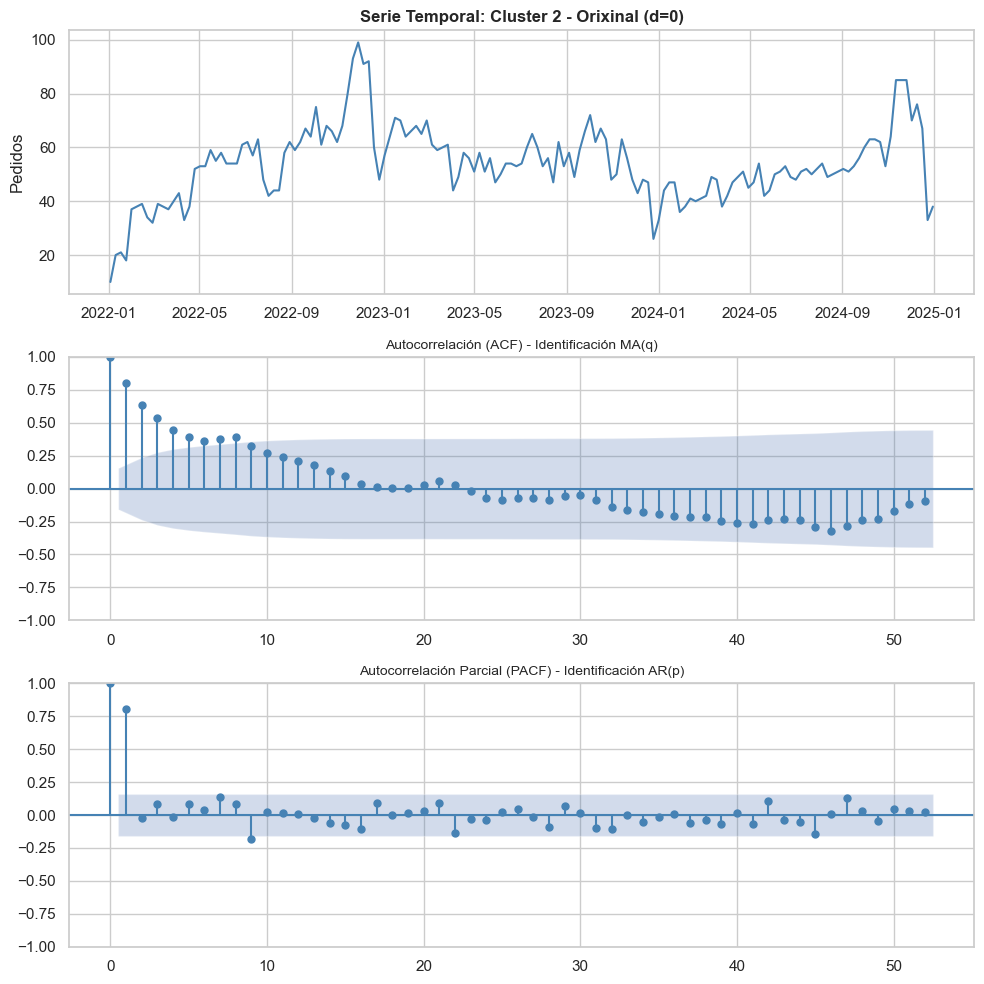

In [40]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

Observando o gráfico secuencial e a fas mostral, podemos intuir a presenza de tendencia. Polo tanto, podemos pensar en repetir os gráficos unha vez diferenciada a serie.

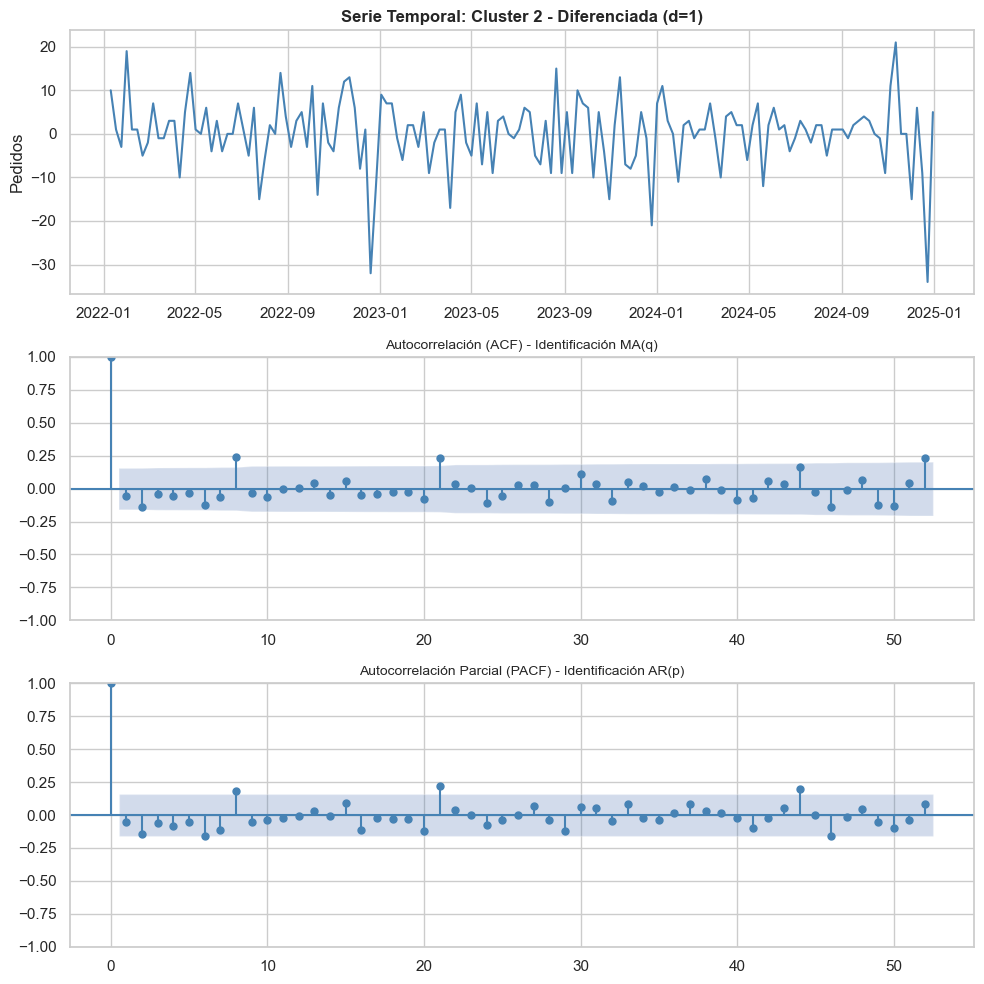

In [41]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Unha vez diferenciada a serie, non se observan problemas de estacionalidade nin heterocedasticidade. Ademáis, observando os gráficos das fas e fap mostrais podemos suxerir un ARMA(0,0) para a serie diferenciada. Daquela, para a serie orixinal poderiamos suxerir un ARIMA(0,1,0)

#### Selección do modelo mediante AICc

In [42]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1692.920, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1098.826, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1099.988, Time=0.18 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1099.570, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1089.669, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1252.527, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1091.669, Time=0.21 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1091.671, Time=0.14 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1159.580, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.25 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 1.534 seconds
                               SARIMAX Re

Segundo o criterio do AIC, o mellor modelo sería un ARIMA(1,0,0) con intercepto. Este modelo presenta un AIC = 1089.67.

Recordemos que segundo o criterio gráfico seleccionariamos un ARIMA(0,1,0), vexamos cal é o AIC deste modelo:

In [43]:
modelo = 'Cluster 2'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 0) axustado correctamente.
AIC = 1087.6006523616772


Vemos daquela como o modelo suxerido pola interpretación gráica sería mellor ao modelo axustado automaticamente. (Que a función auto_arima non probe modelos con d=1 débese a que non rexeita a estacionariedade da serie de partida. Sinalemos que graficamente tampouco é que se observase unha gran tendencia.). Obligamos entón ao criterio automático a avaliar os modelos con d=1.

In [44]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d=1
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1089.516, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1090.556, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1090.092, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1087.601, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1083.285, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=1082.829, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1087.437, Time=0.11 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=1084.713, Time=0.19 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=1083.347, Time=0.25 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1083.091, Time=0.19 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=1087.044, Time=0.18 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=1086.108, Time=0.23 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1081.496, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AI

Daquela agora o mellor modelo sería un ARIMA(2,1,1) cun AIC = 1081.50.

In [45]:
best_order = modelo_global.order

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora á detección de outliers mediante a función que definimos no primeiro modelo axustado:

In [46]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2024-12-23 | t-stat: 4.40 > 3.59


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   [Iter 2] Detectado: 2022-12-19 | t-stat: 3.65 > 3.59
   [Iter 3] Non se atoparon máis atípicos significativos (Max t: 3.07). Fin.
       fecha    t_stat  iter      tipo
0 2024-12-23 -4.403763     1  Negativo
1 2022-12-19 -3.654433     2  Negativo
            bf_pre  bf_peak  bf_post  outlier_20241223  outlier_20221219
semana                                                                  
2022-01-03       0        0        0                 0                 0
2022-01-10       0        0        0                 0                 0
2022-01-17       0        0        0                 0                 0
2022-01-24       0        0        0                 0                 0
2022-01-31       0        0        0                 0                 0


Detectamos dous atípicos correspondentes coas semanas do 23-12-2024 e a semana do 19-12-2022. Engadímolos ao modelo como variables dummy.

#### Estimación ou axuste do modelo

Axustamos o modelo resultante e vemos se os seus parámetros son significativos ou non.

In [47]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -518.644
Date:                Tue, 23 Dec 2025   AIC                           1055.288
Time:                        16:35:56   BIC                           1082.621
Sample:                    01-03-2022   HQIC                          1066.391
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre              10.6806      2.909      3.671      0.000       4.978      16.383
bf_peak             12.1994      3.598     

Vemos como o efecto de $\varphi_2$ non é significativo (ten unp-valor de 0.318). Axustamos o modelo sen dito parámetro, é dicir, un ARIMA(1,1,1):

In [48]:
modelo = 'Cluster 2'
best_order = (1,1,1)
datos_arima[modelo]['order'] = best_order
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(1, 1, 1) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -518.180
Date:                Tue, 23 Dec 2025   AIC                           1052.359
Time:                        16:35:56   BIC                           1076.655
Sample:                    01-03-2022   HQIC                          1062.228
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               9.6644      2.792      3.461      0.001       4.192      15.137
bf_peak             10.9817      3.216     

Agora vemos como o parámetro menos significativo é o correspondente á parte de medias móviles $\theta_1$. Axustemos logo un ARIMA(1,1,0):

In [49]:
modelo = 'Cluster 2'
best_order = (1,1,0)
datos_arima[modelo]['order'] = best_order
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(1, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -527.114
Date:                Tue, 23 Dec 2025   AIC                           1068.228
Time:                        16:35:56   BIC                           1089.532
Sample:                    01-03-2022   HQIC                          1076.881
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.8366      3.083      2.866      0.004       2.793      14.880
bf_peak             10.2400      3.978     

Agora o non significativo é o correspondente á parte autorregresiva ($\varphi_1$):

In [50]:
modelo = 'Cluster 2'
best_order = (0,1,0)
datos_arima[modelo]['order'] = best_order
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(0, 1, 0) con 5 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.402
Date:                Tue, 23 Dec 2025   AIC                           1066.805
Time:                        16:35:56   BIC                           1085.065
Sample:                    01-03-2022   HQIC                          1074.222
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               8.7500      3.289      2.660      0.008       2.304      15.196
bf_peak              9.8333      3.963     

Vemos como o efecto post-bf non é significativo (p-valor = 0.407). Daquela podemos eliminalo do modelo e reaxustar.

In [51]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(0, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.801
Date:                Tue, 23 Dec 2025   AIC                           1065.602
Time:                        16:35:56   BIC                           1080.819
Sample:                    01-03-2022   HQIC                          1071.783
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre           

Vemos agora como todos os coeficientes son significativos. Temos daquela axustado o modelo.

#### Diagnose ou análise dos residuos

Graficamente:

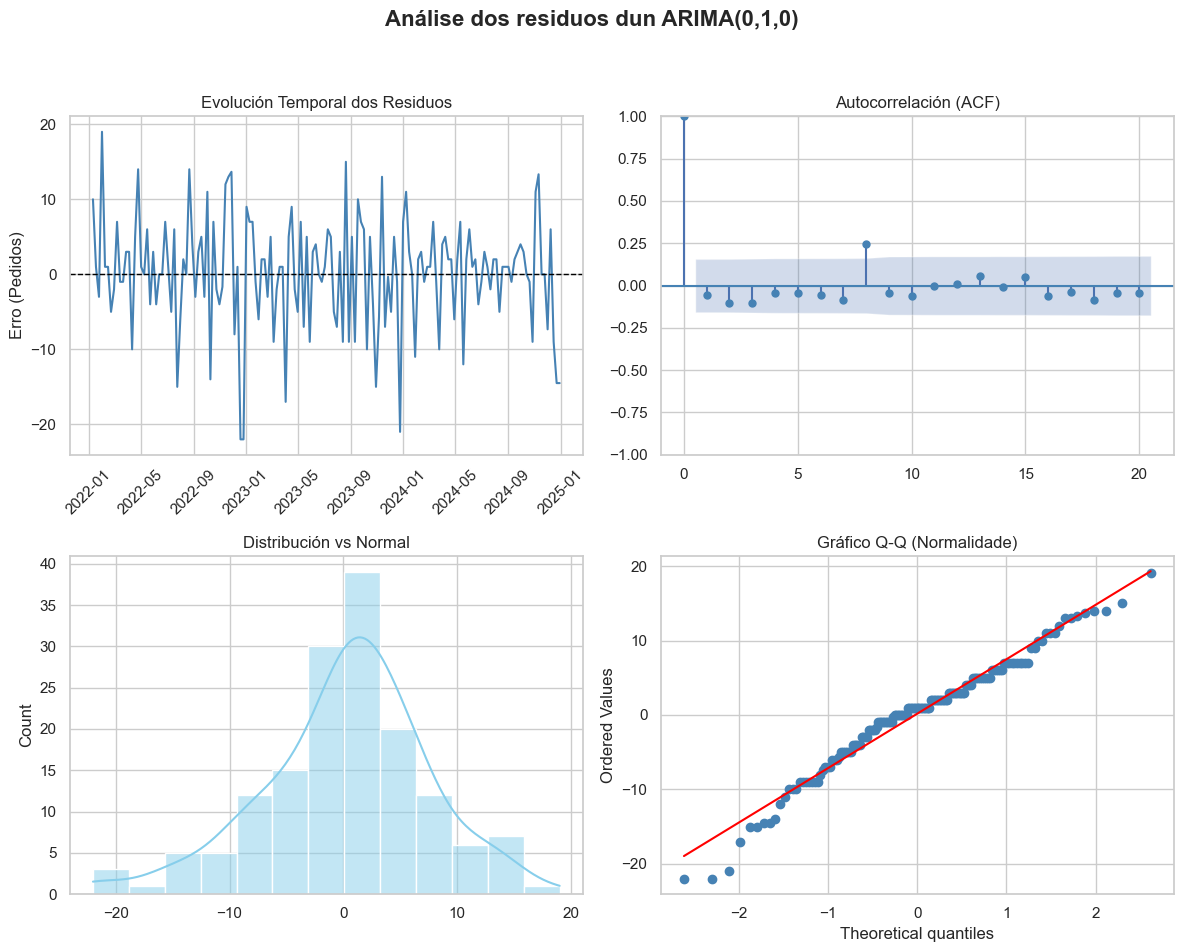


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(0,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.7601 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0044 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [52]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(0,1,0)')

Graficamente non asemella que teñamos problemas nin de heterocedasticidade, nin correlación. Ademáis, parece tamén que os residuos teñen media 0. Porén a normalidade dos residuos seguramente non se vaia a cumprir. Fagamos os contrastes pertinentes:

In [53]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -527.801
Date:                Tue, 23 Dec 2025   AIC                           1065.602
Time:                        16:35:57   BIC                           1080.819
Sample:                    01-03-2022   HQIC                          1071.783
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               7.6667      2.937      2.610      0.009       1.910      13.423
bf_peak              7.6667      2.846      2.694      0.007       2.089      13.245
outlier_20241223   -19.5000      2.590     -7.528      0.000     -24.577     -14.423
outlier_20221219   -10.0000      1.707     -5.858      0.000     -13.346      -6.654
sigma2              53.1148      5.189     10.235      0.000      42.944      63.286
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):                 9.63
Prob(Q):                              0.49   Prob(JB):                         0.01
Heteroskedasticity (H):               0.51   Skew:                            -0.49
Prob(H) (two-sided):                  0.02   Kurtosis:                         3.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Cuidado** non se cumpre a hipótese da homocedasticidade. Temos un p-valor no test de Homocedasticidade de 0.02 < 0.05, co cal debemos reaxustar o modelo.

#### Corrección da heterocedasticidade

Aplicaremos unha transformación logarítmica aos nosos datos e repetiremos o procedemento.

In [54]:
modelo = 'Cluster 2'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

**Selección das ordes (p,d,q)**

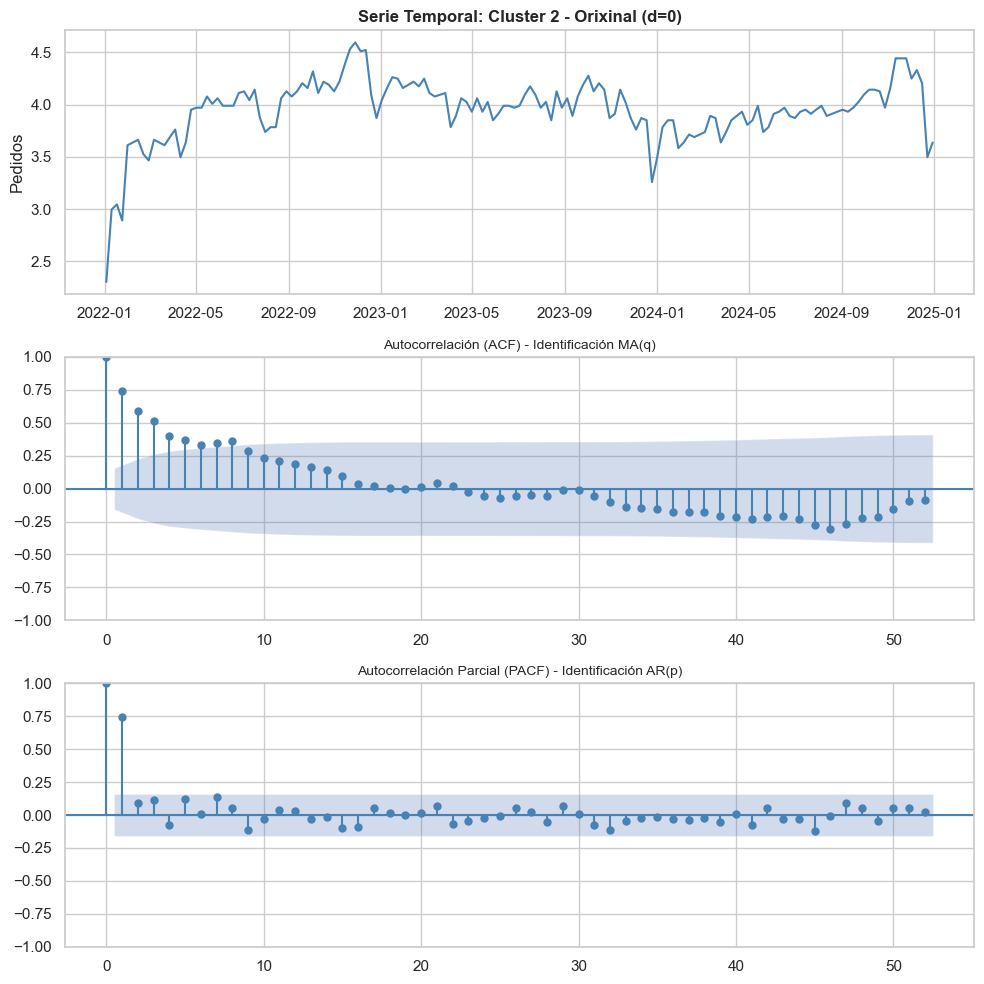

In [55]:
modelo = 'Cluster 2'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

Seguimos vendo problemas de tendencia. Diferenciemos a serie transformada.

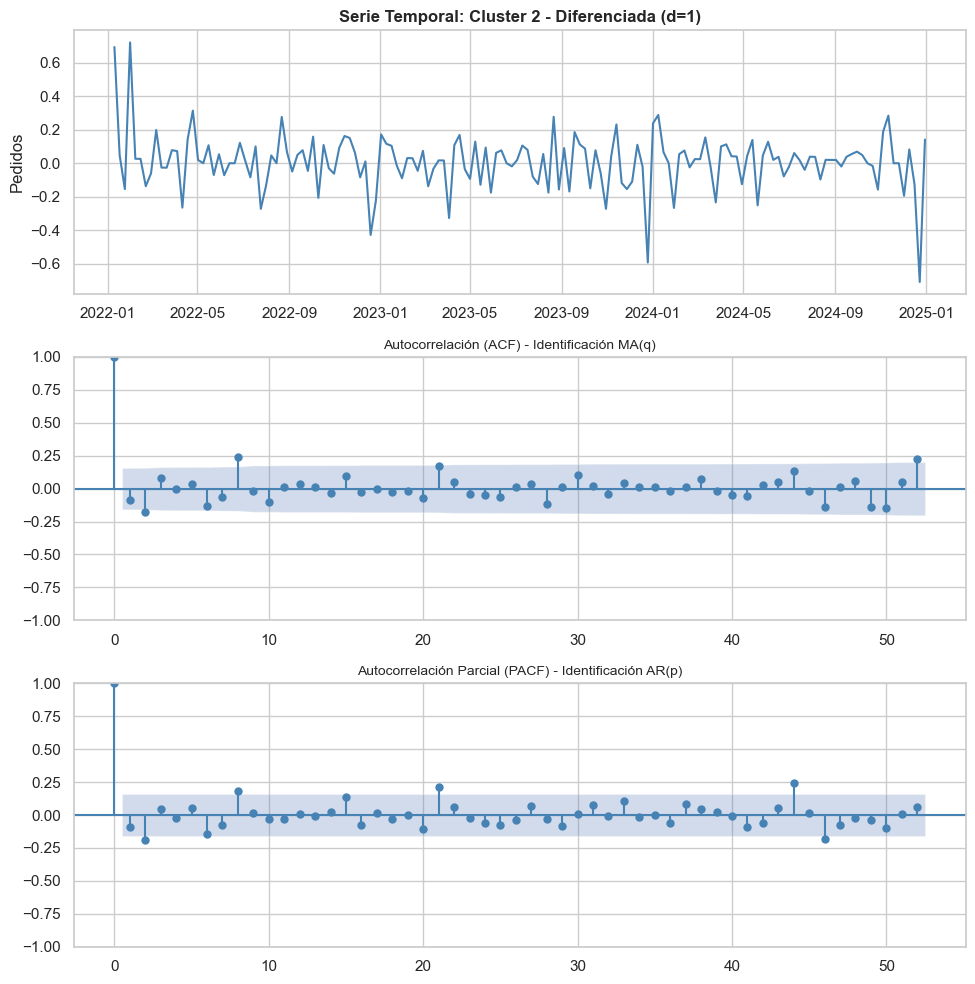

In [56]:
modelo = 'Cluster 2'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Diferenciada (d=1)"
)

Para a serie do log diferenciada podemos suxerir un ARMA(0,0). Co cal a serie tranformada pode vir explicada por un ARIMA(0,1,0).

**Selección automática**

In [57]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=871.007, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-106.677, Time=0.15 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-102.857, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-111.443, Time=0.39 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.72 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-106.076, Time=0.34 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-110.164, Time=0.23 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-108.031, Time=0.36 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-107.290, Time=0.22 sec

Best model:  ARIMA(1,0,2)(0,0,0)[0]          
Total fit time: 3.070 seconds
                               SARIMAX Results 

O mellor modelo segundo o AIC sería un ARIMA(1,0,2). Novamente sucede que a función auto_arima non avalía modelos con d=1. Probemos manuealmente o ARIMA(0,1,0) e comparemos o AIC co suposto óptimo.

In [58]:
modelo = 'Cluster 2'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (0, 1, 2)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (0, 1, 2) axustado correctamente.
AIC = -118.63561565544572


Novamente o AIC mellora ao considerar dito modelo, co cal repetiremos o proceso automático obrgando a que tome d=1:

In [59]:
modelo = 'Cluster 2'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train'],
    d = 1
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=1, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-111.135, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-110.987, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-112.282, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-112.711, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-113.735, Time=0.15 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-116.123, Time=0.16 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-118.122, Time=0.09 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-116.123, Time=0.15 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-114.122, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-119.331, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-112.520, Time=0.06 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-117.343, Time=0.12 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-117.345, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AI

Daquela o mellor modelo sería un ARIMA(2,1,0) con AIC = -119.33. Como o modelo suxerido graficamente (ARIMA(0,1,0)) empeora en máis de dúas unidades o AIC óptimo, quedamos co modelo proposto polo criterio automático.

In [60]:
best_order = modelo_global.order

**Detección de atípicos**

In [61]:
modelo = 'Cluster 2'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))

datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Detectado: 2022-01-31 | t-stat: 4.71 > 3.59
   [Iter 2] Detectado: 2024-12-23 | t-stat: 4.49 > 3.59
   [Iter 3] Detectado: 2023-12-25 | t-stat: 4.09 > 3.59
   [Iter 4] Non se atoparon máis atípicos significativos (Max t: 3.23). Fin.
       fecha    t_stat  iter      tipo
0 2022-01-31  4.710930     1  Positivo
1 2024-12-23 -4.489493     2  Negativo
2 2023-12-25 -4.094729     3  Negativo
            bf_pre  bf_peak  bf_post  outlier_20220131  outlier_20241223  \
semana                                                                     
2022-01-03       0        0        0                 0                 0   
2022-01-10       0        0        0                 0                 0   
2022-01-17       0        0        0                 0                 0   
2022-01-24       0        0        0                 0                 0   
2022-01-31       0        0        0                 1                 0   

            outl

Detectamos daquela 3 atípicos: na semana 31-01-2022, na semana 23-12-2024 e na semana 25-12-2023. Axustámolos no modelo mediante variables dummys.

**Estimación ou axuste do modelo**

In [62]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.595
Date:                Tue, 23 Dec 2025   AIC                           -171.190
Time:                        16:36:02   BIC                           -143.857
Sample:                    01-03-2022   HQIC                          -160.088
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1233      0.083      1.486      0.137      -0.039       0.286
bf_peak              0.1592      0.085     

Vemos como o coeficiente $\varphi_1$ non é significativo. Debemos fixalo a 0 reaxustar o modelo:

In [63]:
modelo = 'Cluster 2'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final = model_axuste.fit_constrained(constraints)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 0) con 6 variables exóxenas...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  94.416
Date:                Tue, 23 Dec 2025   AIC                           -172.831
Time:                        16:36:02   BIC                           -148.535
Sample:                    01-03-2022   HQIC                          -162.962
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre               0.1220      0.090      1.358      0.174      -0.054       0.298
bf_peak              0.1536      0.086     

Vemos agora que o efecto posterior do B-F non é significativo. Quítamolo do noso modelo e reaxustamos:

In [64]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 5 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  93.564
Date:                Tue, 23 Dec 2025   AIC                           -173.127
Time:                        16:36:03   BIC                           -151.868
Sample:                    01-03-2022   HQIC                          -164.492
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_pre           

Sucede o mesmo agora co efecto pre-BF, facemos o propio:

In [65]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 4 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  92.310
Date:                Tue, 23 Dec 2025   AIC                           -172.621
Time:                        16:36:03   BIC                           -154.399
Sample:                    01-03-2022   HQIC                          -165.219
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
bf_peak            

E agora co impacto do propio BF (parece que o modelo o capta directamente)...

In [66]:
modelo = 'Cluster 2'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Restrición
constraints = {'ar.L1': 0}

# 2. Adestramos
modelo_final =  model_refinado.fit_constrained(constraints)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
✅ Variable 'bf_peak' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 3 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.863
Date:                Tue, 23 Dec 2025   AIC                           -173.726
Time:                        16:36:03   BIC                           -158.541
Sample:                    01-03-2022   HQIC                          -167.558
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131 

Todos os termos significativos. Quedamos con este modelo.

**Diagnose ou validación do modelo**

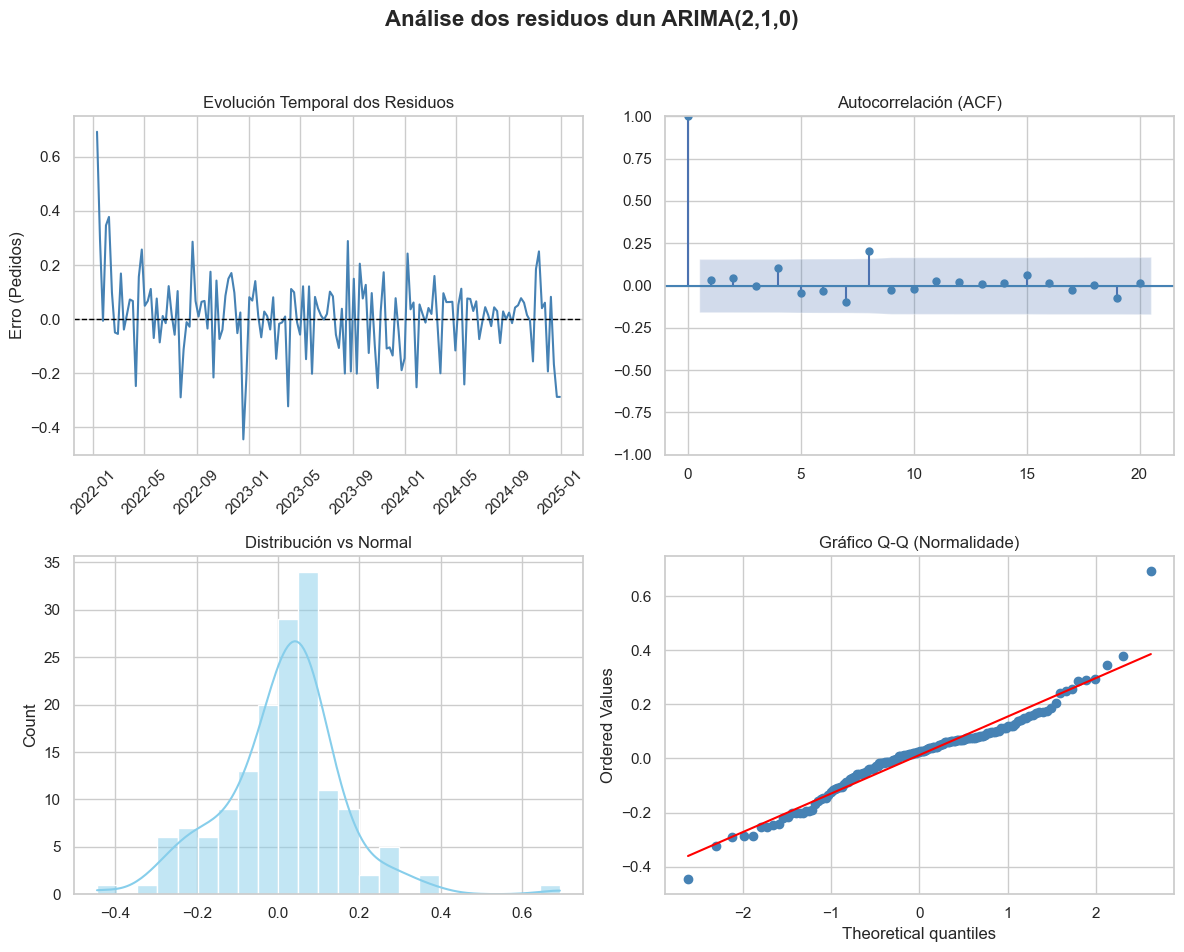


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(2,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.2760 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0000 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [67]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(2,1,0)')

O problema co primeiro residuo e pola propia construción do modelo (diferenciado) que non detecta dito dato como atípico polo algoritmo interno (non hai que preocuparse).

In [68]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                  91.863
Date:                Tue, 23 Dec 2025   AIC                           -173.726
Time:                        16:36:03   BIC                           -158.541
Sample:                    01-03-2022   HQIC                          -167.558
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
====================================================================================
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
outlier_20220131     0.3842      0.036     10.650      0.000       0.314       0.455
outlier_20241223    -0.4025      0.045     -9.016      0.000      -0.490      -0.315
outlier_20231225    -0.3793      0.073     -5.215      0.000      -0.522      -0.237
ar.L1 (fixed)             0        nan        nan        nan         nan         nan
ar.L2               -0.2129      0.093     -2.277      0.023      -0.396      -0.030
sigma2               0.0178      0.002     10.148      0.000       0.014       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 7.81
Prob(Q):                              0.70   Prob(JB):                         0.02
Heteroskedasticity (H):               0.57   Skew:                            -0.40
Prob(H) (two-sided):                  0.05   Kurtosis:                         3.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Agora vemos que non se rexeita a hipótese de incorrelación (p-valor = 0.70), nin a de homocedasticidade (p-valor = 0.05), nin tampouco a de media 0 (p-valor = 0.27). En cambio si se rexeita a hipótese de normalidade (JB: p-valor = 0.02 e SW: p-valor ~= 0). Polo tanto o modelo así axustado si é válido e podemos pasar á predición.

**DUDAS AQUÍ** Esto me propón chati (non se pode contrastar a homocedasticidade).

#### Predicións

Moi impostante sinalar que, como axustamos o modelo á serie transformada (log), debemos facer as predicións con estos datos e, para poder interpretar e avaliar as métricas, transformar as predicións mediante a función inversa (exp):

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 2 ---
   Variables en modelo: 3
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...
   > Semana 10/38: Pred=3.95
   > Semana 20/38: Pred=3.90
   > Semana 30/38: Pred=3.73


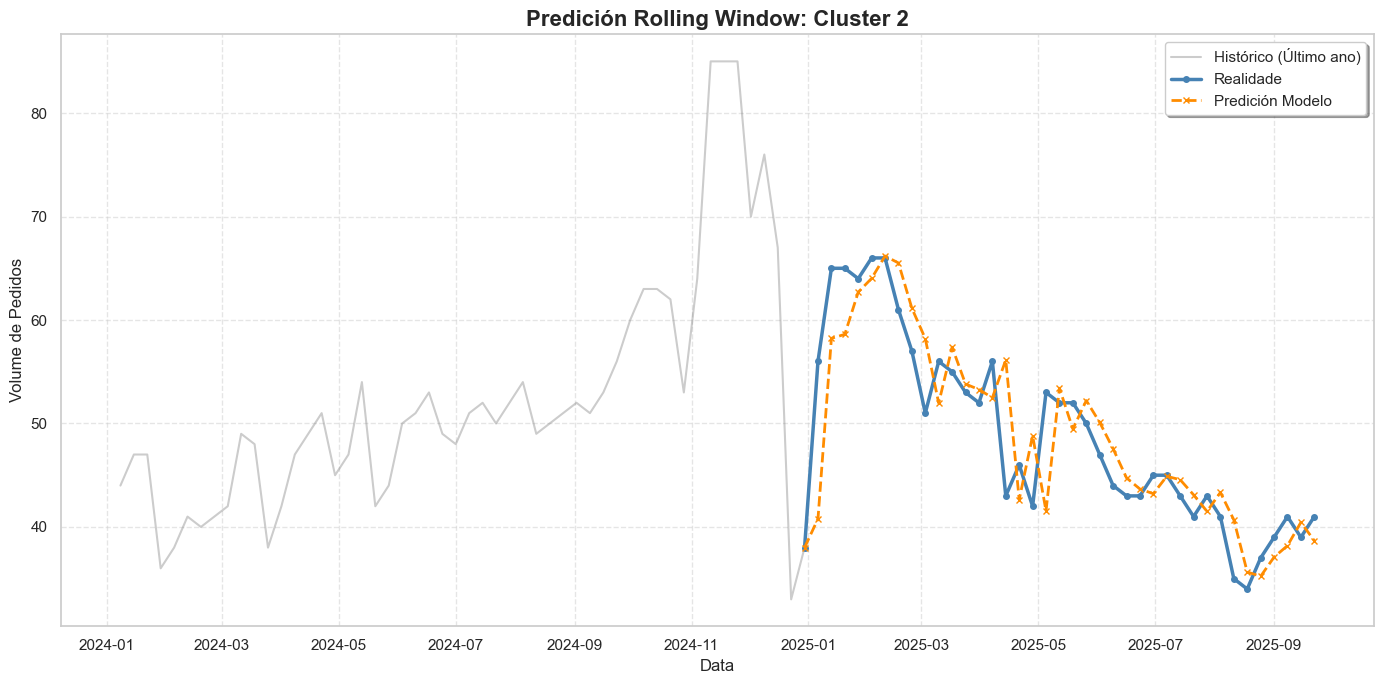

In [69]:
modelo = 'Cluster 2'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    titulo=f"Predición Rolling Window: {modelo}"
)

#### Medidas de adecuación das predicións

In [70]:
modelo = 'Cluster 2'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)
datos_arima[modelo]['metricas'] = metricas

--- 📊 AVALIACIÓN: Cluster 2 (Rolling) ---
MAE:  3.60
RMSE: 4.94
MAPE: 7.38%
MASE: 0.63 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos daquela que o MAPE é do 7.38% e o MASE de 0.63, co cal obtemos uns bos resultados.

Gardamos a información da análise de intervención e atípicos para empregar nos modelos Prophet:

In [71]:
modelo = 'Cluster 2'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 2 ---
   💾 Empaquetando datos de Cluster 2 para Prophet...

✅ Datos exportados para Cluster 2.
   Dimensións: (195, 5)
   Columnas incluídas: ['semana', 'n_pedidos', 'outlier_20220131', 'outlier_20241223', 'outlier_20231225']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos  outlier_20220131  outlier_20241223  \
190 2025-08-25       37.0                 0                 0   
191 2025-09-01       39.0                 0                 0   
192 2025-09-08       41.0                 0                 0   
193 2025-09-15       39.0                 0                 0   
194 2025-09-22       41.0                 0                 0   

     outlier_20231225  
190                 0  
191                 0  
192                 0  
193                 0  
194                 0  


### Cluster 3

Recordemos que o terceiro cluster estaba formado polos clientes de alimentación e industria.

In [72]:
df_cluster_3 = datos['Cluster 3'].set_index('semana')

#### Análise de intervención: efecto do Black Friday

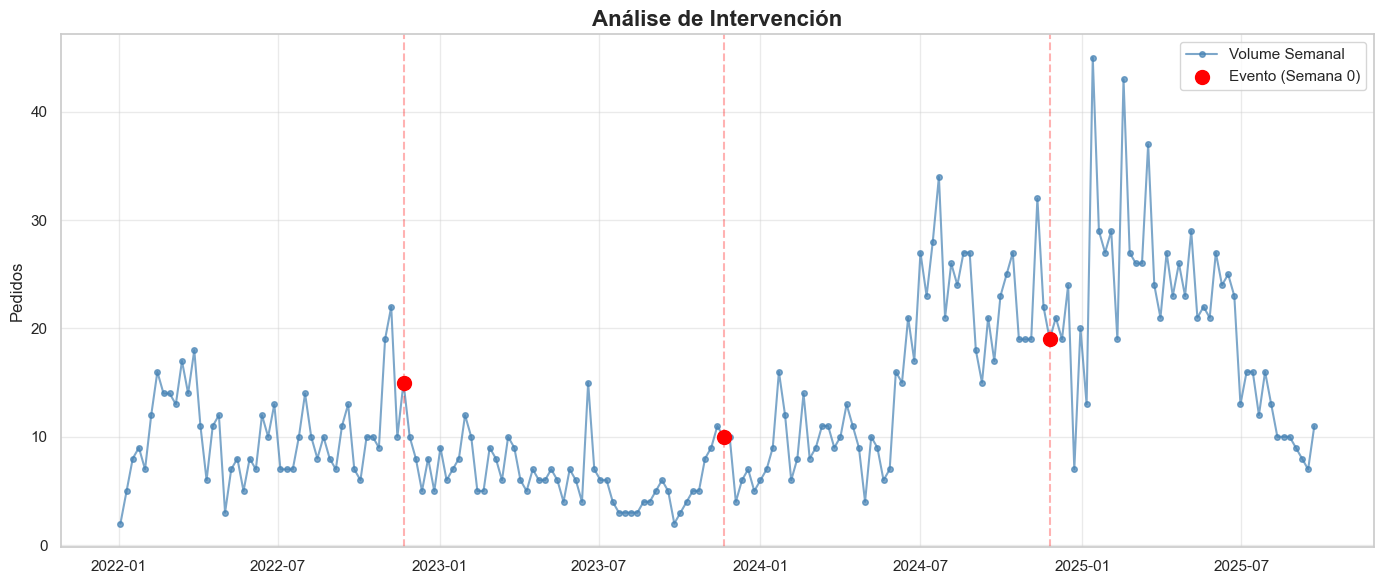

In [73]:
ft.plot_analisis_intervencion(df_input=df_cluster_3,
                              fechas_clave=fechas_bf)

Para os clientes deste cluster non apreciamos visualmente un gran impacto do Black Friday nin previo nin posterior. Porén, podemos modelar dita intervención e ver posterioremente se ten efecto significativo ou non á hora de axustar o modelo. 

In [74]:
modelo = 'Cluster 3'
y_train, y_test, df_full_proc = ft.preparar_datos_arima(df_cluster_3)
df_con_features = ft.crear_features_black_friday(
        df_full_proc, 
        fechas_bf, 
        weeks_pre=1, 
        weeks_post=1
    )

cols_exog = ['bf_pre', 'bf_peak', 'bf_post']
fecha_corte = '2024-12-30'
X_train = df_con_features.loc[df_con_features.index <= fecha_corte, cols_exog]
X_test  = df_con_features.loc[df_con_features.index > fecha_corte, cols_exog]

datos_arima[modelo] = {
    'y_train': y_train,
    'y_test':  y_test,
    'X_train': X_train,
    'X_test':  X_test,
    'full':    df_con_features
}

   ✂️ Split (2024-12-30): Train=157 | Test=38


#### Identificación das ordes (p,d,q) e (P,D,Q)s

##### Gráfico secuencial, fas e fap mostrais

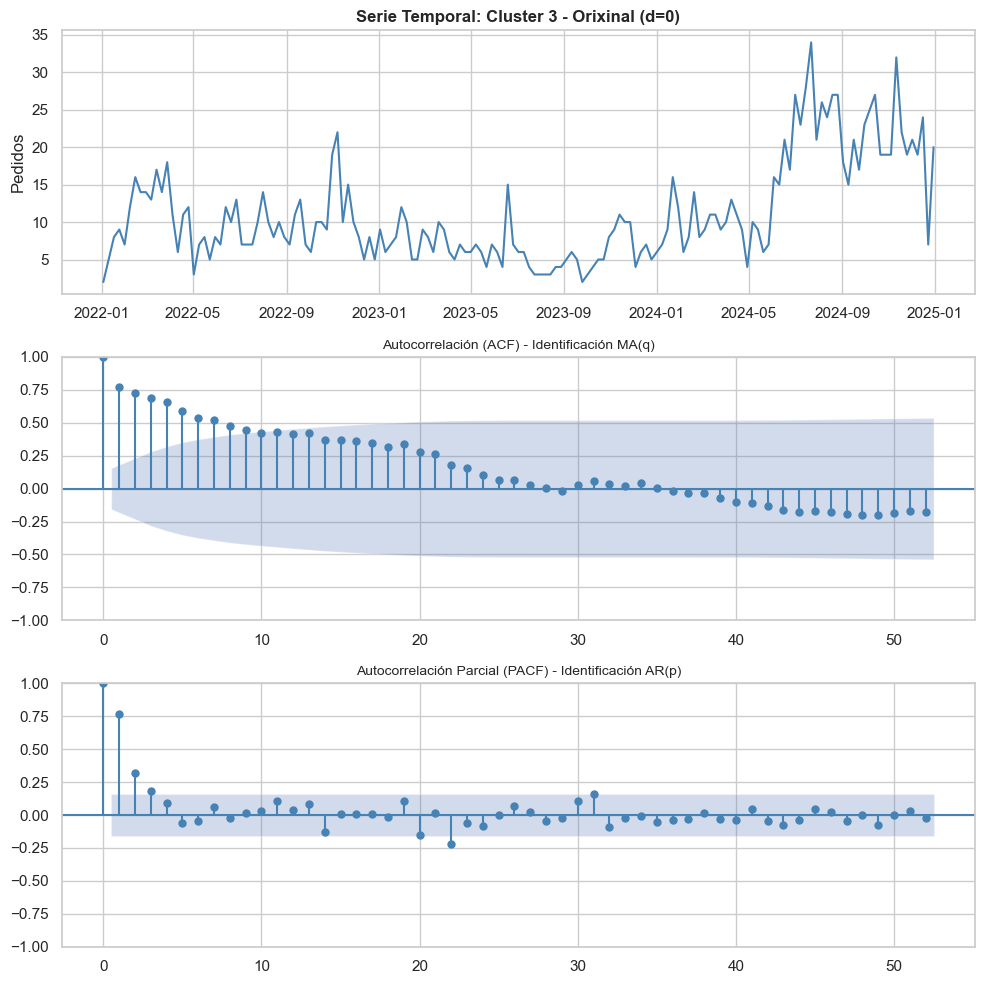

In [75]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Orixinal (d=0)"
)

No gráfico secuencial podemos observar un posible problema de heterocedasticidade, ata maio do 2024 a varianza é pequena, mentres que a partir deste momento, ademáis de crecer o nivel medio tamén oscila de forma máis significativa. Polo tanto procederemos a aplicar a transformación log á nosa serie.

In [76]:
modelo = 'Cluster 3'
datos_arima[modelo]['y_train'] = np.log(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.log(datos_arima[modelo]['y_test'])

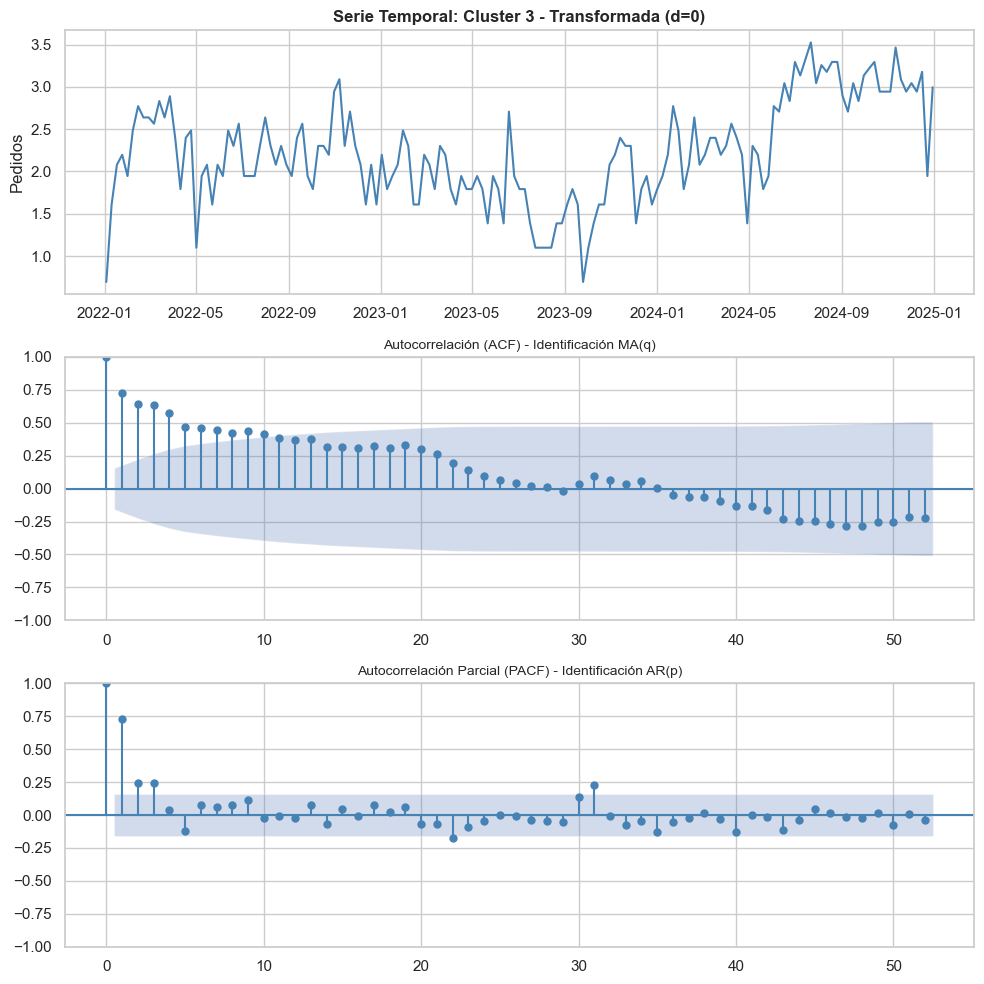

In [77]:
modelo = 'Cluster 3'
ft.plot_identificacion_arima(
    datos_arima[modelo]['y_train'], 
    lags=52, 
    titulo=f"{modelo} - Transformada (d=0)"
)

Estando o problema de heterocedasticidade corrixido, seguimos vendo tendencia a partir de maio de 2024 fundamentalmente. Daquela diferenciamos a serie.

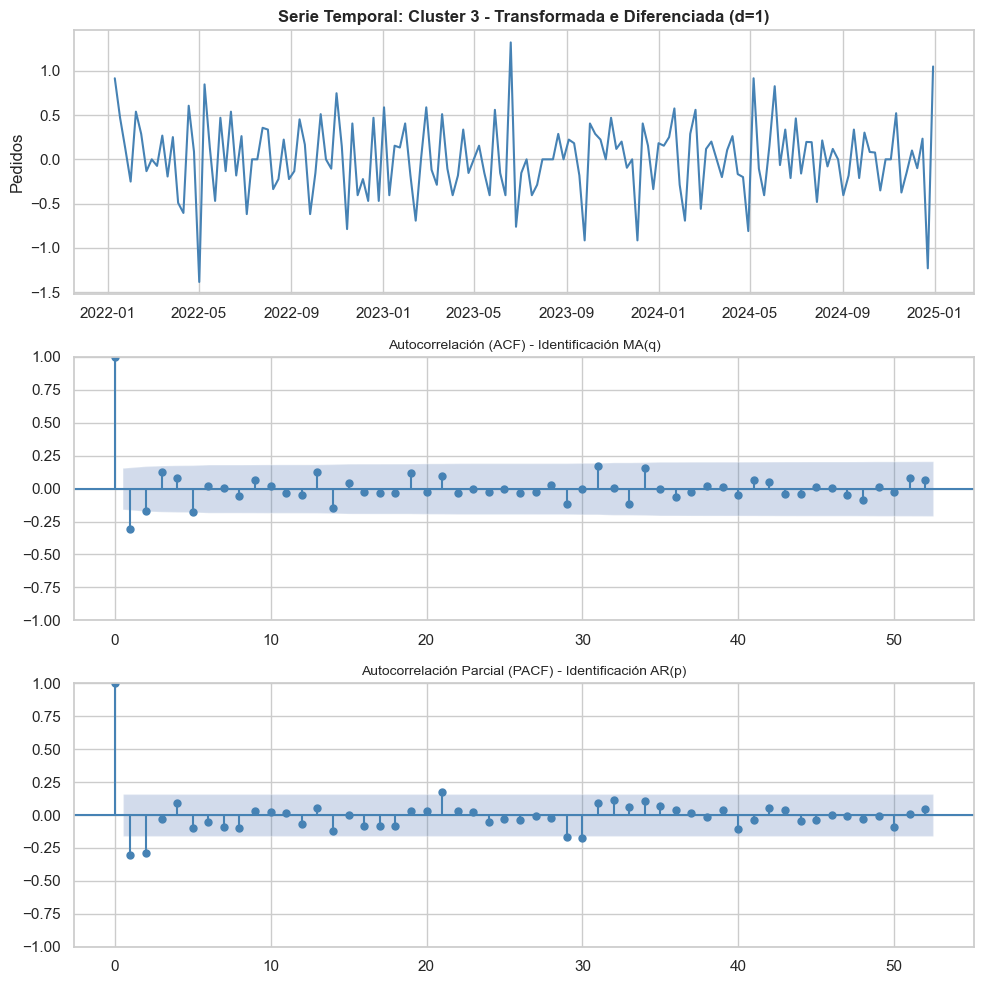

In [78]:
modelo = 'Cluster 3'
y_diff = datos_arima[modelo]['y_train'].diff().dropna()
ft.plot_identificacion_arima(
    y_diff, 
    lags=52, 
    titulo=f"{modelo} - Transformada e Diferenciada (d=1)"
)

Unha vez diferenciada a serie transformada, os problemas de tendencia corríxense.  

Daquela, a serie diferenciada pode vir explicada ou ben por un MA(1) ou ben por un AR(2). Así, un modelo para a serie orixinal (transformada) podería ser ARIMA(0,1,1) ou ARIMA(2,1,0).

#### Selección do modelo mediante AICc

In [79]:
modelo = 'Cluster 3'
modelo_global = ft.seleccionar_arima(
    y_train = datos_arima[modelo]['y_train'],
    X_train = datos_arima[modelo]['X_train']
)
print(modelo_global.summary())
print(modelo_global.aic())

   ⚙️ Config: m=1, Seasonal=False, Force_d=None, Force_D=None
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=179.126, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=165.801, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=153.816, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=177.322, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=153.911, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=153.281, Time=0.44 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=154.819, Time=0.27 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=154.709, Time=0.36 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=156.629, Time=0.65 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=151.787, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=152.207, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=153.291, Time=0.12 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=153.142, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=152.456,

In [80]:
modelo = 'Cluster 3'
# 1. Defines a orde manual que elixiches (p,d,q)
manual_order = (2, 1, 0)

# 2. Instancias o modelo coa orde fixa
# Non lle pasamos 'scoring' nin nada extra porque non imos comparar
model_manual = pm.ARIMA(order=manual_order, suppress_warnings=True, trend = 'n')

# 3. Adestras (Fit) cos datos e as exóxenas
model_manual.fit(datos_arima[modelo]['y_train'], 
                X = datos_arima[modelo]['X_train'])

# 4. ACTUALIZACIÓN CRÍTICA:
# Gardamos esta orde na variable 'best_order' para que o Bucle de Rolling Window a use
best_order = manual_order

print(f"✅ Modelo ARIMA {manual_order} axustado correctamente.")
print(f"AIC = {model_manual.aic()}")

✅ Modelo ARIMA (2, 1, 0) axustado correctamente.
AIC = 149.92350800883338


O modelo seleccionado polo criterio do AIC sería un ARIMA(0,1,2) con AIC= 151.79. Como graficamente era un ARIMA(0,1,1) con AIC = 152.21 e dista en menos de dúas unidades do óptimo, quedamos con dito modelo por ser máis sinxelo

#### Detección de atípicos (aditivos e innovativos)

Pasamos agora a facer o contraste de outliers e engadir dita información ao noso modelo:

In [81]:
modelo = 'Cluster 3'
df_outliers, X_train_con_outliers = ft.detect_outliers_iterativo(
    y=datos_arima[modelo]['y_train'],
    X_inicial=datos_arima[modelo]['X_train'],
    order=best_order,
    trend='n',
    alpha=0.05,    # Só detectamos outliers moi claros (95% confianza)
    max_iter=10,    # Limitamos a 10 para non sobreaxustar
    burn_in=3      # Ignoramos as primeiras 3 semanas de residuos
)
print(df_outliers)
print(X_train_con_outliers.head(5))


datos_arima[modelo]['X_train_final'] = X_train_con_outliers
datos_arima[modelo]['outliers_df'] = df_outliers
datos_arima[modelo]['order'] = best_order

🔄 Iniciando Detección Iterativa (Max iter: 10)...
   [Iter 1] Non se atoparon máis atípicos significativos (Max t: 3.12). Fin.
   ✅ Non se atoparon outliers.
Empty DataFrame
Columns: [fecha, t_stat, iter, tipo]
Index: []
            bf_pre  bf_peak  bf_post
semana                              
2022-01-03       0        0        0
2022-01-10       0        0        0
2022-01-17       0        0        0
2022-01-24       0        0        0
2022-01-31       0        0        0


Non se atoparon atípicos, co cal pasamos a axustar o modelo.

#### Estimación ou axuste do modelo

In [82]:
modelo = 'Cluster 3'
print(f"📊 Axustando modelo final SARIMAX{best_order} con {datos_arima[modelo]['X_train_final'].shape[1]} variables exóxenas...")

# 1. Instanciamos o modelo cos datos finais
# Importante: Usamos X_train_final (que inclúe Black Friday + Outliers)
model_axuste = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog = datos_arima[modelo]['X_train_final'],       # <--- A CLAVE: A matriz completa
    order = datos_arima[modelo]['order'],         # A túa orde escollida (ex. 0,1,1)
    trend ='n',                # Sen intercepto (se a serie é diferenciada)
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 2. Adestramos
modelo_final = model_axuste.fit(disp=False)

# 3. Mostramos a táboa de significación
print(modelo_final.summary())

📊 Axustando modelo final SARIMAX(2, 1, 0) con 3 variables exóxenas...


                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -64.630
Date:                Tue, 23 Dec 2025   AIC                            141.259
Time:                        16:36:10   BIC                            159.481
Sample:                    01-03-2022   HQIC                           148.661
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_pre         0.1316      0.181      0.728      0.467      -0.223       0.486
bf_peak        0.2496      0.286      0.871      0.384      -0.312       0.811
bf_post        0.2032      0.187      1.086      0.2

Vemos como os coeficientes correspondentes ao impacto do Black Friday non son significativos. Comezamos eliminando o menos significativo pre-BF:

In [83]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_pre'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_pre'...
✅ Variable 'bf_pre' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 2 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -64.860
Date:                Tue, 23 Dec 2025   AIC                            139.721
Time:                        16:36:10   BIC                            154.905
Sample:                    01-03-2022   HQIC                           145.889
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_peak        0.2038      0.26

Agora a menos significativa é a variable dummy que capta o efecto do propio BF. Quitámola do modelo:

In [84]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_peak'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    exog=datos_arima[modelo]['X_train_final'],        # <--- Usamos a matriz SEN bf_pre
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_peak'...
✅ Variable 'bf_peak' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 1 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.442
Date:                Tue, 23 Dec 2025   AIC                            138.884
Time:                        16:36:10   BIC                            151.032
Sample:                    01-03-2022   HQIC                           143.818
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
bf_post        0.1300      0.

In [85]:
modelo = 'Cluster 3'
print("✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...")

# 1. ELIMINACIÓN DA VARIABLE
# Borramos a columna tanto no train coma no test para manter a coherencia
variable_a_borrar = 'bf_post'

if variable_a_borrar in datos_arima[modelo]['X_train_final'].columns:
    X_train_refinado = datos_arima[modelo]['X_train_final'].drop(columns=[variable_a_borrar])
    X_test_refinado  = datos_arima[modelo]['X_test'].drop(columns=[variable_a_borrar])
    print(f"✅ Variable '{variable_a_borrar}' eliminada correctamente das matrices.")
else:
    print(f"⚠️ A variable '{variable_a_borrar}' non se atopou (quizais xa a borraste).")
    X_train_refinado = datos_arima[modelo]['X_train_final']
    X_test_refinado = datos_arima[modelo]['X_test']

datos_arima[modelo]['X_train_final'] =  X_train_refinado
datos_arima[modelo]['X_test_final'] = X_test_refinado


# 2. REAXUSTE DO MODELO (REFIT)
print(f"📊 Reaxustando SARIMAX{best_order} coas {
datos_arima[modelo]['X_train_final'].shape[1]} variables restantes...")

model_refinado = SARIMAX(
    datos_arima[modelo]['y_train'],
    order=datos_arima[modelo]['order'],
    trend='n',                    # Sen intercepto (como tiñas antes)
    enforce_stationarity=False,
    enforce_invertibility=False
)

modelo_final = model_refinado.fit(disp=False)

# 3. COMPARATIVA E VALIDACIÓN
print(modelo_final.summary())

✂️ Aplicando 'Backward Elimination': Eliminando 'bf_post'...
✅ Variable 'bf_post' eliminada correctamente das matrices.
📊 Reaxustando SARIMAX(2, 1, 0) coas 0 variables restantes...
                               SARIMAX Results                                
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.707
Date:                Tue, 23 Dec 2025   AIC                            137.414
Time:                        16:36:10   BIC                            146.525
Sample:                    01-03-2022   HQIC                           141.115
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4293      0.

Vemos como, en efecto, a variable dummy do post-BF tampouco é significativa. Axustamos daquela o modelo sen intervención:

Vemos agora como o coeficiente correspondente á parte de medias móviles é significativo, co cal quedamos cun ARIMA(0,1,1).

#### Diagnose ou análise dos residuos

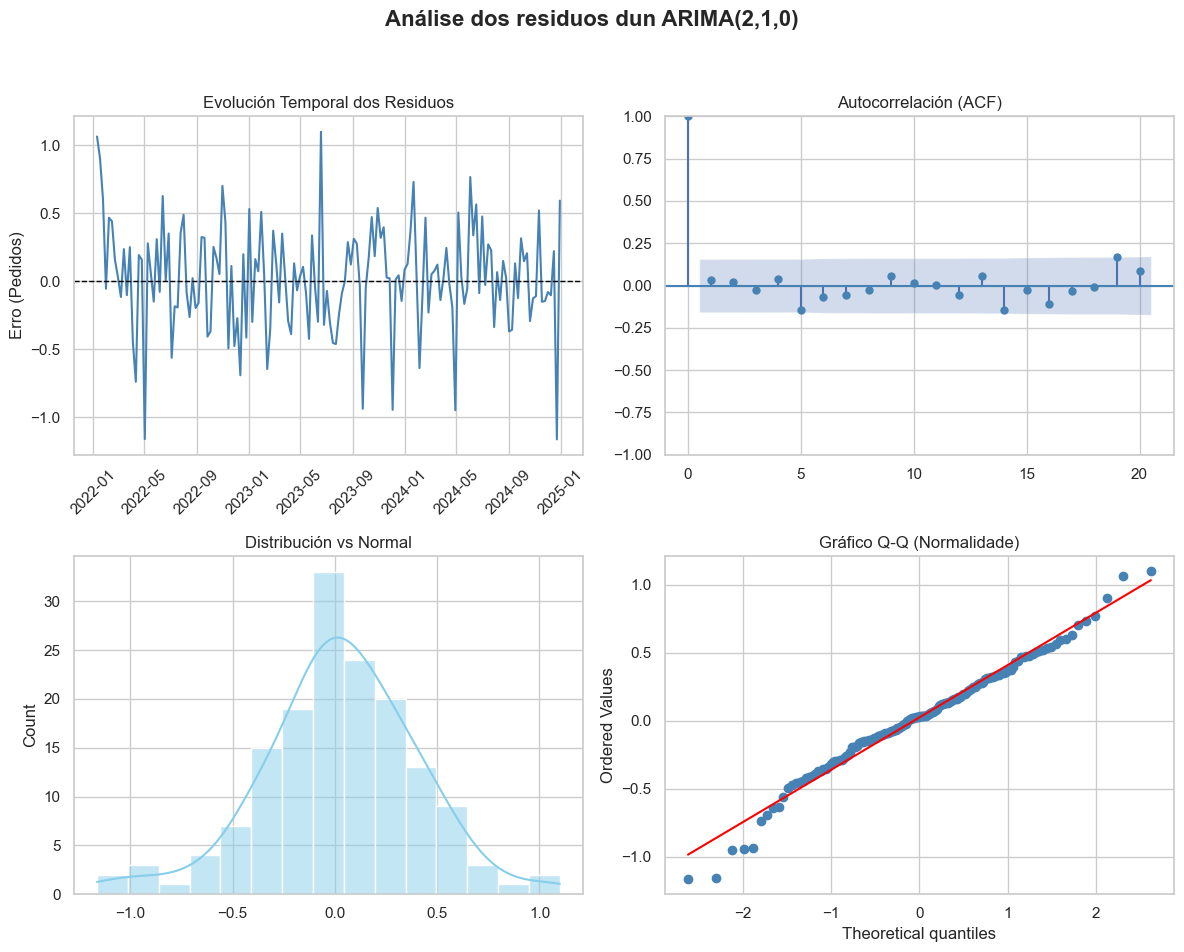


📋 --- INFORME ESTATÍSTICO: Análise dos residuos dun ARIMA(2,1,0) ---
1️⃣  Sesgo (Media=0):  p-value = 0.4307 ✅ (Aceptamos H0: Non hai sesgo)
2️⃣  Normalidade (Shapiro): p-value = 0.0458 ⚠️ (Rexeitamos H0: Non son perfectamente normais)
------------------------------------------------------------


In [86]:
ft.analizar_residuos_arima(modelo_final,lags=20, 
                           titulo= 'Análise dos residuos dun ARIMA(2,1,0)')

Graficamente non observamos problemas de correlación ou heterocedasticidade. En relación á normalidade, os residuos presentan certa asimetría co cal é posible que non se vaia cumprir.

In [87]:
modelo_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              n_pedidos   No. Observations:                  157
Model:               SARIMAX(2, 1, 0)   Log Likelihood                 -65.707
Date:                Tue, 23 Dec 2025   AIC                            137.414
Time:                        16:36:11   BIC                            146.525
Sample:                    01-03-2022   HQIC                           141.115
                         - 12-30-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4293      0.084     -5.139      0.000      -0.593      -0.266
ar.L2         -0.3105      0.082     -3.807      0.000      -0.470      -0.151
sigma2         0.1374      0.013     10.404      0.000       0.112       0.163
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):                11.10
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.90   Skew:                            -0.46
Prob(H) (two-sided):                  0.72   Kurtosis:                         3.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Analiticamente, non rexeitamos a homocedasticidade (p-valor (B-P) = 0.68), tampouco temos problemas de correlación (p-valor (L-J) = 0.57) nin se rexeita a hipótese de media 0, (p-valor = 0.49). Co cal o modelo así axustado é válido. A normalidade non se cumpre.

#### Predicións

Da mesma forma que no cluster 2, axustamos o modelo para os datos transformados (log), co cal á hora de predecir debemos facer a transformación inversa (exp):

--- 🔮 VALIDACIÓN ROLLING WINDOW: Cluster 3 ---
   Variables en modelo: 0
   (Test aliñado correctamente con 0s nas columnas de outliers históricos)
   Usando orde ARIMAX: (2, 1, 0)
🚀 Iniciando Rolling Window ARIMAX (38 semanas)...
   ℹ️ Aviso: O modelo non ten variables exóxenas (Arima Puro).
   > Semana 10/38: Pred=3.39


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


   > Semana 20/38: Pred=3.14
   > Semana 30/38: Pred=2.62


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


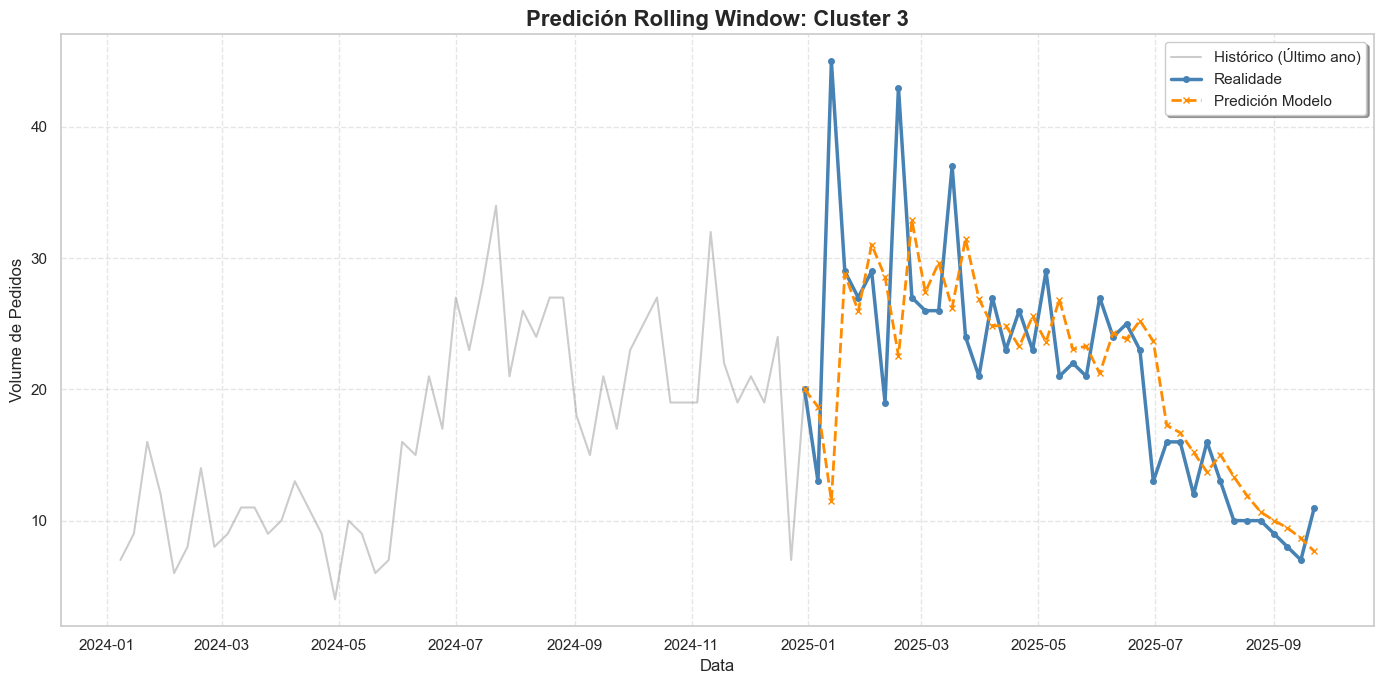

In [88]:
modelo = 'Cluster 3'
print(f"--- 🔮 VALIDACIÓN ROLLING WINDOW: {modelo} ---")

# 2. ALIÑACIÓN DE COLUMNAS (CRÍTICO)
# X_train ten columnas de outliers que X_test non ten.
# Creamos esas columnas en X_test e enchémolas con 0 (o futuro non ten eses erros pasados)
datos_arima[modelo]['X_test_final'] = datos_arima[modelo]['X_test'].reindex(columns=datos_arima[modelo]['X_train_final'].columns, fill_value=0)

print(f"   Variables en modelo: {len(datos_arima[modelo]['X_train_final'].columns)}")
print(f"   (Test aliñado correctamente con 0s nas columnas de outliers históricos)")


print(f"   Usando orde ARIMAX: {datos_arima[modelo]['order']}")

# 4. EXECUCIÓN DO ROLLING WINDOW
# Usamos a función 'arimax' porque confirmamos que NON hai estacionalidade
preds_rolling_log = ft.rolling_window_arimax(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'], # Pasamos o Test coas columnas corrixidas
    order=datos_arima[modelo]['order'],
    trend='n',             # Sen tendencia (xa diferenciamos ou non é significativa)
    verbose=True           # Para ver o progreso semana a semana
)

# Desfacemos a transformación log
preds_rolling = np.exp(preds_rolling_log)
datos_arima[modelo]['y_train'] = np.exp(datos_arima[modelo]['y_train'])
datos_arima[modelo]['y_test'] = np.exp(datos_arima[modelo]['y_test'])

# Gardamos as predicións no dicionario
datos_arima[modelo]['predicions'] = preds_rolling

# 6. REPRESENTACIÓN GRÁFICA
ft.plot_predicciones_rolling(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    y_pred=preds_rolling,
    titulo=f"Predición Rolling Window: {modelo}"
)

"Obsérvase un deterioro nas métricas de rendemento durante o primeiro trimestre de 2025 (RMSE elevado). A inspección visual revela un cambio estrutural no comportamento da serie (Concept Drift): a media e a varianza dos pedidos en 2025 son significativamente superiores ás do histórico 2022-2024.

Dado que o modelo SARIMAX basea as súas predicións en patróns históricos (autocorrelación), é incapaz de anticipar un cambio de escala tan brusco sen información exóxena que o explique. O modelo compórtase correctamente de forma reactiva (a predición sobe tras observar o dato real), pero non pode anticipar a magnitude destes picos inéditos."

#### Medidas de adecuación das predicións

In [89]:
modelo = 'Cluster 3'
# 5. CÁLCULO DE MÉTRICAS
# m=1 porque non hai estacionalidade no modelo (comparas contra o valor da semana anterior)
metricas = ft.calcular_metricas_completas(
    y_true=datos_arima[modelo]['y_test'],
    y_pred=datos_arima[modelo]['predicions'],
    y_train=datos_arima[modelo]['y_train'],
    m=1, 
    etiqueta=f"{modelo} (Rolling)"
)

--- 📊 AVALIACIÓN: Cluster 3 (Rolling) ---
MAE:  4.59
RMSE: 7.65
MAPE: 20.73%
MASE: 1.42 (Non Estacional (m=1))
⚠️ CONCLUSIÓN: O modelo non supera ao benchmark (MASE > 1).


Neste último sector obtemos un rendemento bastante peor: MAPE = 20.78% e MASE = 1.38. Isto débese principalmente aos tres primeiros meses do 2025, onde se observan semanas con volume de envíos claramente superior ao habitual nos clientes deste sector. **Interesa ver se os datos destas semanas se deben a algún feito coñecido**

En particular, podemos calcular as métricas prescindindo do primeiro trimestre do ano (onde se ven comportamentos anómalos), para avaliar así o rendemento do modelo no período de comportamento máis estable do sector.

In [90]:
modelo = 'Cluster 3'

print(f"--- 📉 ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: {modelo} ---")

# 1. Definimos a data de corte (Inicio do Q2)
start_date_Q2 = '2025-04-01'

# 2. Filtramos as series (Reutilizamos as variables que xa tes en memoria)
# y_test: A realidade completa
# preds_rolling: A predición completa (xa invertida se usaches logs)
y_true_clean = datos_arima[modelo]['y_test'].loc[start_date_Q2:]
y_pred_clean = datos_arima[modelo]['predicions'].loc[start_date_Q2:]

print(f"   Datos totais 2025: {len(datos_arima[modelo]['y_test'])} semanas")
print(f"   Datos analizados (Abr-Dec): {len(y_true_clean)} semanas")

if len(y_true_clean) > 0:
    # 3. Cálculo das Métricas Filtradas usando a túa función
    # TRUCO MESTRE: Pasamos 'y_train' completo. 
    # Por que? Porque o MASE compara o erro do test contra a historia do train.
    # O histórico non cambia aínda que miremos menos meses de test.
    metricas_clean = ft.calcular_metricas_completas(
        y_true=y_true_clean,
        y_pred=y_pred_clean,
        y_train=datos_arima[modelo]['y_train'], # Orixinal completo
        m=1, # Ou 52 se fose o Global/Cluster 1
        etiqueta=f"{modelo} (Sen Q1)"
    )
    
    # 4. Comparativa Visual (Opcional pero queda moi ben)
    print("\n   --- MELLORA OBTIDA AO ELIMINAR Q1 ---")
    # 'metricas' é o dicionario que calculaches no paso anterior co total
    for key in ['MAE', 'RMSE', 'MAPE', 'MASE']:
        valor_total = metricas[key]
        valor_clean = metricas_clean[key]
        diff = valor_total - valor_clean
        
        # Se diff > 0, o erro baixou (Mellora)
        # Se diff < 0, o erro subiu (Empeora)
        estado = "✅ Mellora" if diff > 0 else "❌ Empeora"
        print(f"   {key}: {valor_total:.2f} -> {valor_clean:.2f} | Dif: {diff:.2f} ({estado})")

else:
    print("⚠️ Erro: Non quedan datos despois do corte.")

datos_arima[modelo]['metricas'] = metricas_clean

--- 📉 ANÁLISE DE SENSIBILIDADE (SEN Q1 2025) PARA: Cluster 3 ---
   Datos totais 2025: 38 semanas
   Datos analizados (Abr-Dec): 25 semanas
--- 📊 AVALIACIÓN: Cluster 3 (Sen Q1) ---
MAE:  2.68
RMSE: 3.46
MAPE: 17.21%
MASE: 0.83 (Non Estacional (m=1))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).

   --- MELLORA OBTIDA AO ELIMINAR Q1 ---
   MAE: 4.59 -> 2.68 | Dif: 1.92 (✅ Mellora)
   RMSE: 7.65 -> 3.46 | Dif: 4.19 (✅ Mellora)
   MAPE: 20.73 -> 17.21 | Dif: 3.51 (✅ Mellora)
   MASE: 1.42 -> 0.83 | Dif: 0.59 (✅ Mellora)


Vemos como o MAPE cae do 20.78% ao 18.46%, mentres que o MASE baixa de 1.38 ata 0.84. Isto indica que, para o ano 2025 completo, o modelo así axustado non mellora á predición "inocente", é dicir, a predecir como volume da próxima semana o valor da semana previa. Porén, ao avaliar o modelo unicamente a partir do mes de abril, este presenta un mellor rendemento ca o preditor naïve.

Gardamos a información da análise de intervención e atípicos para o Prophet:

In [91]:
modelo = 'Cluster 3'
# 1. Inicializamos o dicionario mestre (se non existe xa)
if 'export_para_prophet' not in locals():
    export_para_prophet = {}

print(f"--- 💾 GARDADO FINAL PARA PROPHET: {modelo} ---")

# 3. Chamamos á función de empaquetado
df_prophet = ft.preparar_datos_para_prophet(
    y_train=datos_arima[modelo]['y_train'],
    y_test=datos_arima[modelo]['y_test'],
    X_train=datos_arima[modelo]['X_train_final'],
    X_test=datos_arima[modelo]['X_test_final'],
    nombre_cluster=modelo
)

# 4. Gardamos no dicionario
export_para_prophet[modelo] = df_prophet

# 5. Verificación
print(f"\n✅ Datos exportados para {modelo}.")
print(f"   Dimensións: {df_prophet.shape}")
print(f"   Columnas incluídas: {list(df_prophet.columns)}")
print("\nMostra das últimas filas (incluíndo 2025):")
print(df_prophet.tail())

--- 💾 GARDADO FINAL PARA PROPHET: Cluster 3 ---
   💾 Empaquetando datos de Cluster 3 para Prophet...

✅ Datos exportados para Cluster 3.
   Dimensións: (195, 2)
   Columnas incluídas: ['semana', 'n_pedidos']

Mostra das últimas filas (incluíndo 2025):
        semana  n_pedidos
190 2025-08-25       10.0
191 2025-09-01        9.0
192 2025-09-08        8.0
193 2025-09-15        7.0
194 2025-09-22       11.0


#### Rendemento dos modelos por cluster

Imos calcular un promedio ponderado dos tres clusters para ter unhas medidas de rendemento xerais e podamos comparar se é mellor considerar un único modelo de predición para todos os clientes (menos interpretable) ou ben é mellor diferenciar entre os distintos clusters. Ten máis sentido esto segundo posto que, no caso contrario, estamos a predecir o mesmo volume de envíos para todos os clientes, mentres que diferenciando entre clusters, en función do tipo de cliente (cluster ao que pertence), teremos unha predición distinta.

Unha primeira media ponderada podería calcularse tendo en conta a proporción de envíos que representan cada un dos clusters do volume total de pedidos.

--- ⚖️ COMPARATIVA FINAL ROBUSTA: GLOBAL vs PONDERADA ---

--- 🏆 RESULTADOS FINAIS ---
Métrica    | Modelo Único | Suma Clusters | Mellora
--------------------------------------------------
MAE        | 7.90         | 3.58         | 4.32
RMSE       | 11.15        | 4.72         | 6.43
MAPE       | 8.18       % | 11.53      % | -3.35%
MASE       | 0.60         | 0.59         | 0.00


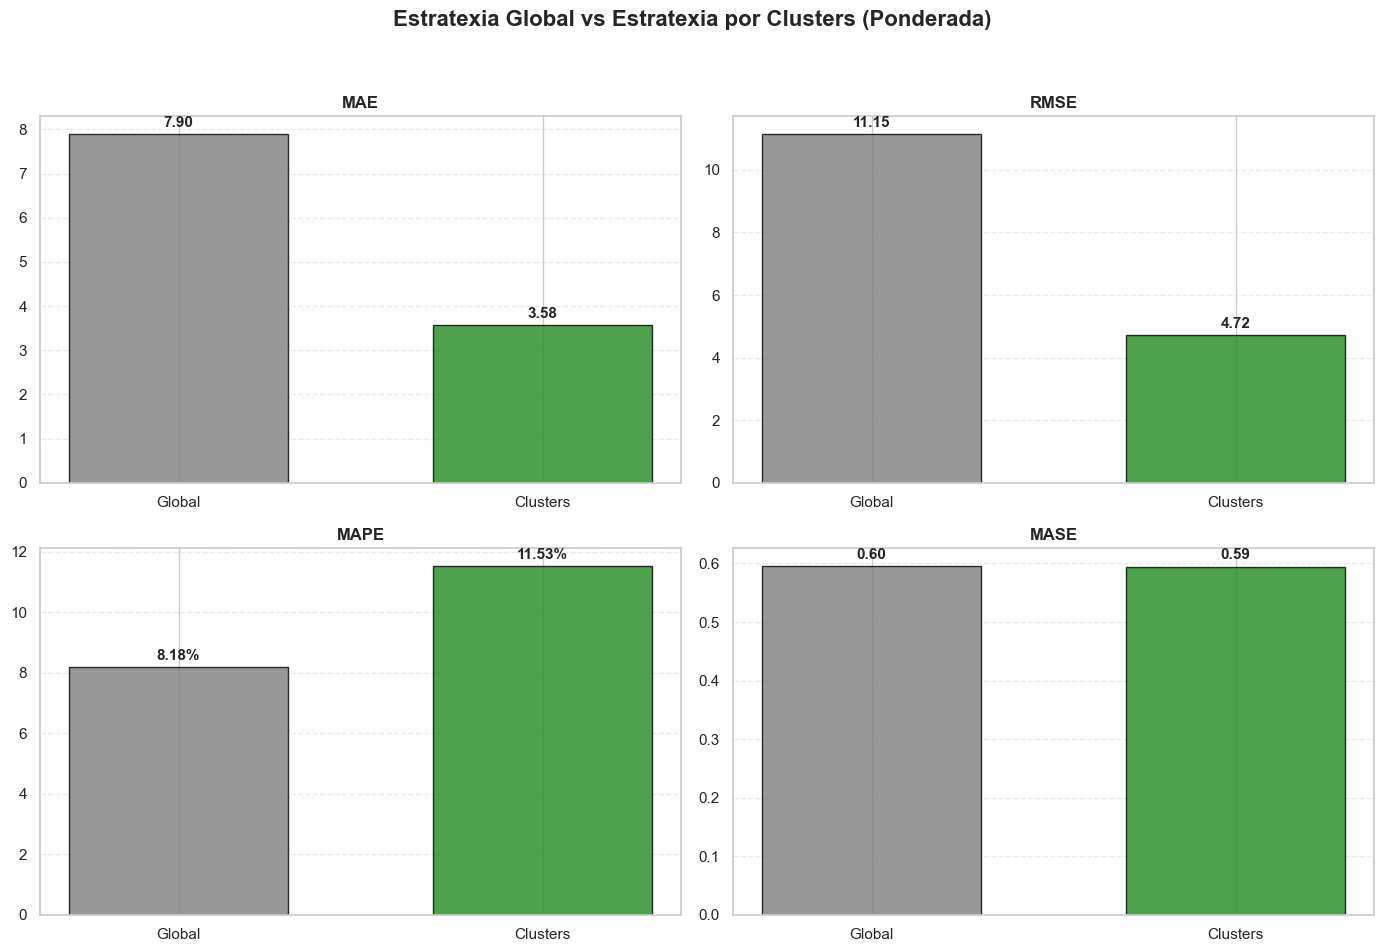

In [92]:
print("--- ⚖️ COMPARATIVA FINAL ROBUSTA: GLOBAL vs PONDERADA ---")

# 1. CÁLCULO DOS PESOS REALES (Automático)
# Usamos o dicionario 'datos' orixinal que ten os DataFrames crus coa columna 'n_pedidos'
volumen_total = datos['Global']['n_pedidos'].sum()

clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
lista_metricas = []

for c in clusters:
    # A. Recuperamos o volume para o peso
    vol_cluster = datos[c]['n_pedidos'].sum()
    peso = vol_cluster / volumen_total
    
    # B. Recuperamos as métricas que gardaches no paso anterior
    # Xa non hai "if c == 'Cluster 3'", porque xa gardaste a versión correcta dentro do dicionario
    m = datos_arima[c]['metricas']
    
    # C. Engadimos á lista
    lista_metricas.append({
        'Cluster': c,
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE'],
        'MASE': m['MASE'],
        'Peso': peso
    })

# Convertemos a DataFrame para operar fácil
df_comp = pd.DataFrame(lista_metricas)

# 2. CÁLCULO PONDERADO (Vectorial)
# Suma(Métrica * Peso) para cada columna
w_mae  = (df_comp['MAE'] * df_comp['Peso']).sum()
w_rmse = (df_comp['RMSE'] * df_comp['Peso']).sum()
w_mape = (df_comp['MAPE'] * df_comp['Peso']).sum()
w_mase = (df_comp['MASE'] * df_comp['Peso']).sum()

# 3. RECUPERAR O GLOBAL
# Tamén o lemos do dicionario
met_global = datos_arima['Global']['metricas']

# 4. TABOA DE RESULTADOS
print("\n--- 🏆 RESULTADOS FINAIS ---")
print(f"{'Métrica':<10} | {'Modelo Único':<12} | {'Suma Clusters':<12} | {'Mellora'}")
print("-" * 50)
print(f"{'MAE':<10} | {met_global['MAE']:<12.2f} | {w_mae:<12.2f} | {met_global['MAE'] - w_mae:.2f}")
print(f"{'RMSE':<10} | {met_global['RMSE']:<12.2f} | {w_rmse:<12.2f} | {met_global['RMSE'] - w_rmse:.2f}")
print(f"{'MAPE':<10} | {met_global['MAPE']:<11.2f}% | {w_mape:<11.2f}% | {met_global['MAPE'] - w_mape:.2f}%")
print(f"{'MASE':<10} | {met_global['MASE']:<12.2f} | {w_mase:<12.2f} | {met_global['MASE'] - w_mase:.2f}")

# 5. VISUALIZACIÓN GRÁFICA
metrics_names = ['MAE', 'RMSE', 'MAPE', 'MASE']
vals_global = [met_global['MAE'], met_global['RMSE'], met_global['MAPE'], met_global['MASE']]
vals_weighted = [w_mae, w_rmse, w_mape, w_mase]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Estratexia Global vs Estratexia por Clusters (Ponderada)', fontsize=16, fontweight='bold')
axes_flat = axes.flatten()
colors = ['gray', 'forestgreen']

for i, metric in enumerate(metrics_names):
    ax = axes_flat[i]
    bars = ax.bar(['Global', 'Clusters'], [vals_global[i], vals_weighted[i]], 
                  color=colors, alpha=0.8, edgecolor='black', width=0.6)
    
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    fmt = '%.2f%%' if metric == 'MAPE' else '%.2f'
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=11, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Modelos Prophet

Probaremos agora cunha aproximación diferente, axustando os modelos Prophet. Estos son uns modelos aditivos de series temporais con compoñentes interpretables:

$y(t) = g(t) + s(t) + h(t) + \epsilon_t$,

onde

$g(t)$ é a tendencia.

$s(t)$ é a estacionalidade.

$h(t)$ é o efecto dos festivos ou eventos especiais.

$\epsilon_t$ o erro.

Comezaremos aplicando ditos modelos ao conxunto total dos nosos datos, e posteriormente a cada cluster por separado, vendo se melloramos as nosas predicións. 

Como estes modelos nos permiten incluír o efecto de ebentos especiais, debemos crear un Dataframe que conteña as datas do **Black Friday**. Como no EDA observamos que o efecto de dita celebración se extende a todo o mes de novembro (a comezos do mes habitúa a aumentar o volume de pedidos), incluímos unha fiestra para indicar que o efecto comeza 3 semanas antes da semana onde se celebra o **Black Friday**.

In [ ]:
# LISTA DOS FESTIVOS:
festivos = [
    '2022-04-14', '2022-04-15', '2022-04-18',
    '2022-05-26', '2023-04-06', '2023-04-07', '2023-04-10',
    '2023-05-18', '2024-03-28', '2024-03-29', '2024-04-01',
    '2024-05-20', '2025-04-17', '2025-04-18',
    '2025-04-21', '2025-05-29'
]
df_festivos_prophet = ft.preparar_festivos_prophet(festivos)
# Dicionario para gardar resultados:
resultados_prophet = {}

Modifiquemos os nosos datos de entrenamento e test para que sexan válidos para o modelo Prophet. Cómpre sinalar que dito modelo precisa que incorporemos os datos mediante un dataframe con dúas columnas $ds$ e $y$. A primeira debe ser datos de datas e a segunda a nosa variable de interese.

Unha vez creados os dataframes da forma que precisa o modelo Prophet, pasamos a construír un dataframe que conteña a información sobre os festivos a ter en conta na nosa base de datos. Comezamos cargando os festivos que engadimos no EDA e, como os nosos datos son semanais, pasámolos ao luns da semana correspondente. Ademáis, debemos ter en conta que, ao ter datos semanais, os efectos dalgúns festivos captúranse directamente coa estacionalidade anual, co cal só debemos incluír aqueles que que cambian de data dependendo do ano. 

Engadimos agora a información sobre o **Black Friday**. En particular, apoiarémonos na análise de intervención feita durante o axuste dos modelos ARIMA. Isto é, non en tódolos clusters o efecto do Black Friday era o mesmo. Daquela recuperamos a construción das variables dummys creadas anteriormente.

### Modelo xeral

Da mesma forma que para os modelos ARIMA, comezaremos axustando un modelo xeral ao conxunto completo dos nosos datos e, posteriormente, axustaremos a cada cluster un modelo e compararemos os rendementos das dúas estratexias.

Comezamos daquela axustando o modelo para todos os clientes en xeral. O modelo Prophet dispón de bastantes parámetros que podemos modificar ao noso gusto co obxectivo de axustar un mellor modelo.

$\cdot$ A función de tendencia $g(t)$ pode ser lienal (por defecto) ou loxística. No segundo caso trataríase dun crecemento que está acotado superiormente por algún motivo de tipo loxístico (por exemplo que a empresa tivese un número máximo de camións dispoñibles). 

$\cdot$ Os puntos de cambio na función de tendencia. Por defecto están situados nos primeiros 80% dos datos da serie coa que se axusta o modelo. Podemos axustar a flexibilidade e a localización de ditos puntos.

$\cdot$ Datas especiais: xa construímos o noso dataframe cos festivos que teremos en conta no noso modelo. Podemos xogar coas fiestras para indicar a influenza de cada festivo. Ademáis, podemos ver cal é o efecto de cada unha destas datas.

$\cdot$ Estacionalidade: $s(t)$ estímase mediante sumas de Fourier. Podemos modificar o número de termos da suma (orde), que nos determina como de rápido cambia a estacionalidade. Por defecto toma o valor 10, se queremos aumentar os cambios de frecuencia (menos suave) aumentamos dito parámetro. Por outra banda, se notamos que a estacionalidade na predición non é unha constante aditiva, senón que cambia ca tendencia, debemos incluír estacionalidade multiplicativa. En dito caso, o efecto das datas especiais tamén debería ser modelado como multiplicativo.

$\cdot$ Outliers: Prophet é capaz de manexa-los atípicos, mais só se os axustamos como cambios na tendencia. A consecuencia é que os intervalos de predición (incertidumbre do modelo) espera futuros cambios na tendencia similares, é dicir, teremos moita incertidumbre. Daquela, a mellor maneira de manexar os outliers é eliminándoos, posto que Prophet non ten problemas en traballar con datos faltantes.


Unha vez probado o modelo Prophet, e tendo en conta os hiperparámetros que podemos modificar para mellorar o modelo, podemos seleccionar o mellor modelo mediante validación cruzada, a partires dunha malla de valores para os hiperparámetros. Este proceso realízase dentro do conxunto de entrenamento, dividindo novamente o mesmo en mostras de entrenamento e test. En particular, este método simula múltiples conxuntos de test dentro da mostra de entrenamento. De entre todos os modelos, escolleremos aquel que minimice o RMSE.

In [94]:
modelo = 'Global'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Global
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (5): ['bf_pre', 'bf_peak', 'bf_post']...
   Variables exóxenas detectadas (5): ['bf_pre', 'bf_peak', 'bf_post', 'outlier_20241223', 'outlier_20231225']


In [95]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")


--- 🔧 TUNING: Global ---
🚀 Iniciando Grid Search con 64 combinacións...


16:36:22 - cmdstanpy - INFO - Chain [1] start processing
16:36:23 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:26 - cmdstanpy - INFO - Chain [1] start processing
16:36:26 - cmdstanpy - INFO - Chain [1] done processing
16:36:28 - cmdstanpy - INFO - Chain [1] start processing
16:36:28 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=20.9564


16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:38 - cmdstanpy - INFO - Chain [1] start processing
16:36:38 - cmdstanpy - INFO - Chain [1] done processing
16:36:40 - cmdstanpy - INFO - Chain [1] start processing
16:36:40 - cmdstanpy - INFO - Chain [1] done processing
16:36:41 - cmdstanpy - INFO - Chain [1] start processing
16:36:41 - cmdstanpy - INFO - Chain [1]

   > Combinación 10/64: RMSE=20.4243


...

16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] done processing
16:38:37 - cmdstanpy - INFO - Chain [1] done processing
16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] done processing
16:38:37 - cmdstanpy - INFO - Chain [1] start processing
16:38:37 - cmdstanpy - INFO - Chain [1] done processing
16:38:37 - cmdstanpy - INFO - Chain [1] done processing
16:38:38 - cmdstanpy - INFO - Chain [1] done processing
16:38:38 - cmdstanpy - INFO - Chain [1] start processing
16:38:38 - cmdstanpy - INFO - Chain [1] done processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing
16:38:40 - cmdstanpy - INFO - Chain [1] start processing
16:38:40 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=20.1084


16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] done processing
16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] done processing
16:38:51 - cmdstanpy - INFO - Chain [1] done processing
16:38:51 - cmdstanpy - INFO - Chain [1] done processing
16:38:51 - cmdstanpy - INFO - Chain [1] start processing
16:38:51 - cmdstanpy - INFO - Chain [1] done processing
16:38:52 - cmdstanpy - INFO - Chain [1] done processing
16:38:52 - cmdstanpy - INFO - Chain [1] start processing
16:38:52 - cmdstanpy - INFO - Chain [1] done processing
16:38:53 - cmdstanpy - INFO - Chain [1] start processing
16:38:53 - cmdstanpy - INFO - Chain [1] start processing
16:38:53 - cmdstanpy - INFO - Chain [1] start processing
16:38:53 - cmdstanpy - INFO - Chain [1


✅ Grid Search Completado.
   Mellor RMSE: 19.4172
   Parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'additive'}


16:38:59 - cmdstanpy - INFO - Chain [1] done processing


In [96]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'],  # Usamos os que gañaron no tuning
    verbose=True
)

16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Global ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=117.12


16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:26 - cmdstanpy - INFO - Chain [1] start processing
16:40:26 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=117.06


16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:27 - cmdstanpy - INFO - Chain [1] done processing
16:40:27 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=93.26


16:40:27 - cmdstanpy - INFO - Chain [1] start processing
16:40:28 - cmdstanpy - INFO - Chain [1] done processing
16:40:28 - cmdstanpy - INFO - Chain [1] start processing
16:40:28 - cmdstanpy - INFO - Chain [1] done processing
16:40:28 - cmdstanpy - INFO - Chain [1] start processing
16:40:28 - cmdstanpy - INFO - Chain [1] done processing
16:40:28 - cmdstanpy - INFO - Chain [1] start processing
16:40:28 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Global ---


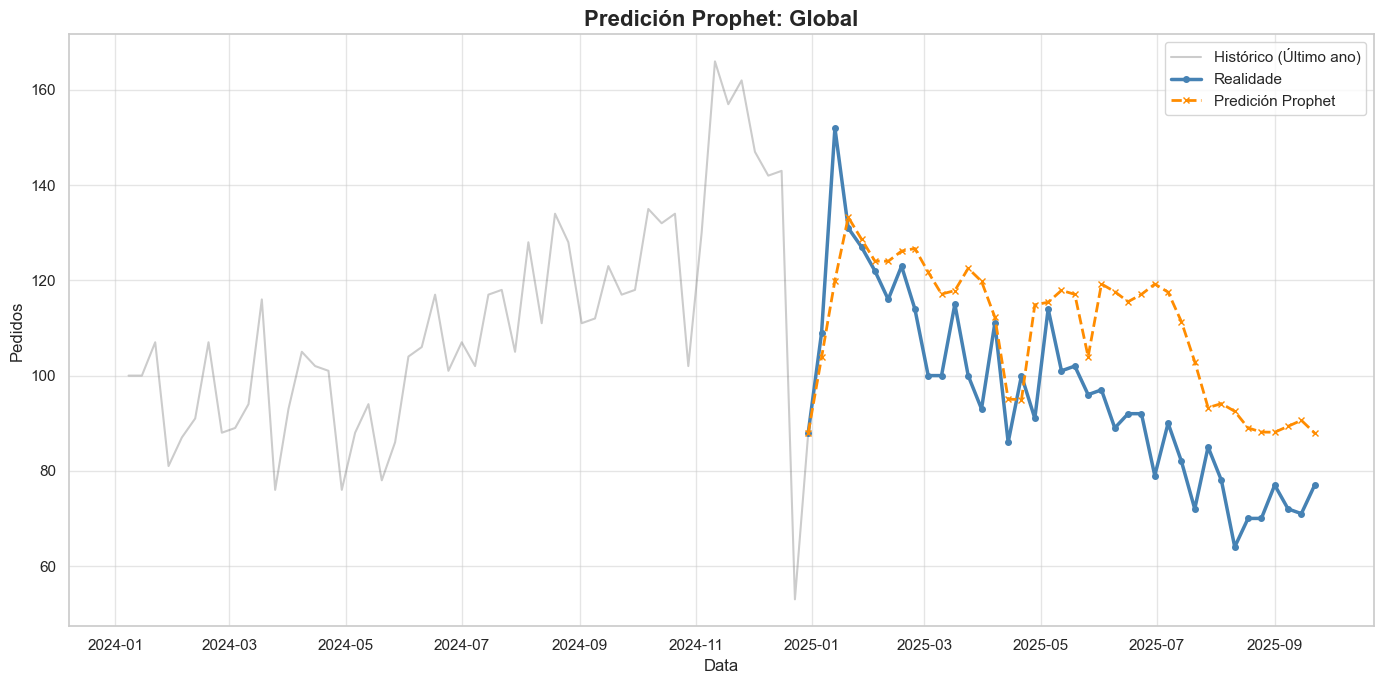

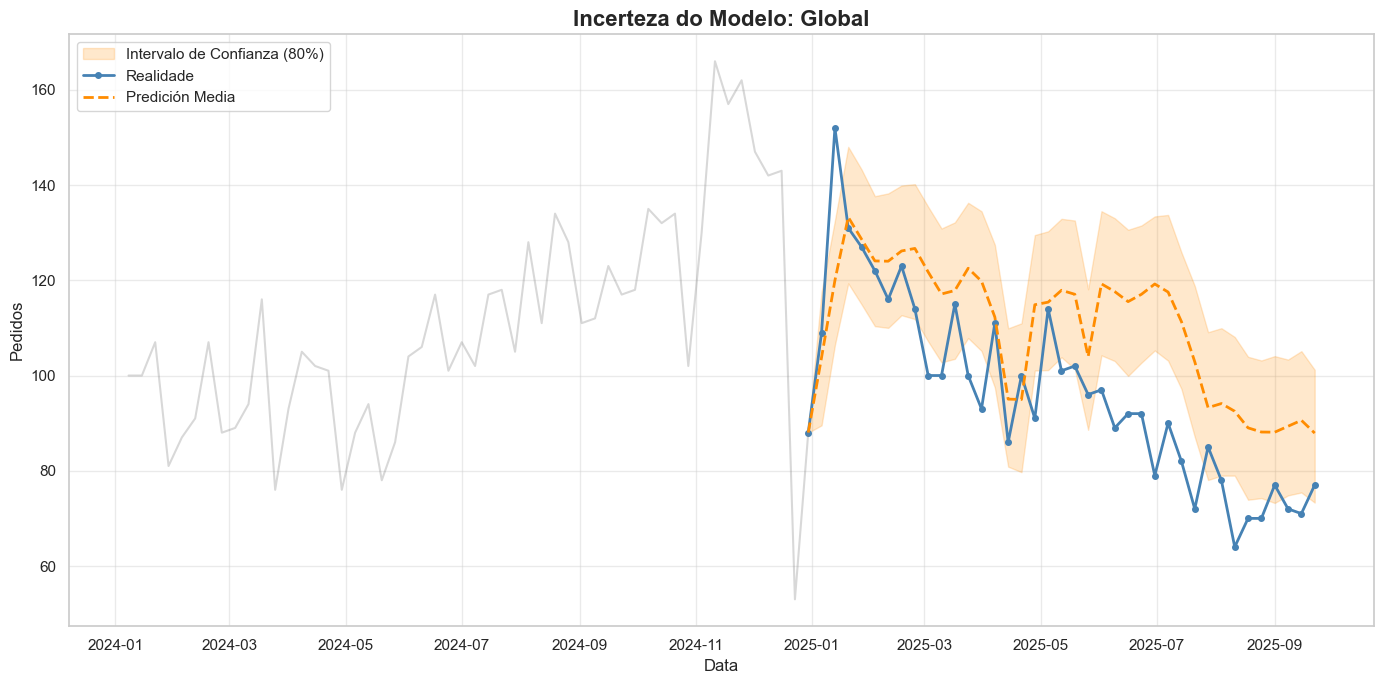

In [97]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

E avaliamos o rendemento do modelo:

Neste caso, como temos estacionalidade anual, debemos modificar a función que calcula o MASE posto que agora temos que comparar coa predición naïve do valor $x_t$ co valor observado $s=52$ instantes previos $x_{t-52}$, polo tanto debemos cambiar o denominador de dita medida do erro:

In [98]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Global ---
MAE:  16.19
RMSE: 19.19
MAPE: 18.53%
MASE: 0.72 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como o MAPE = 18.70% e o MASE = 0.73, co cal o modelo predice mellor ca o naïve estacional (predecir o valor dunha semana como a do ano previo). 

Vemos graficamente as distintas compoñentes do modelo. Como aplicamos a metodoloxía $\textit{Rolling-Window}$, temos axustado 39 modelos (un por semana de horizonte). Así, representaremos as compoñentes do último modelo por ser o máis actual (se por exemplo queremos usar o modelo para semanas futuras este será o de partida):

16:40:56 - cmdstanpy - INFO - Chain [1] start processing
16:40:56 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


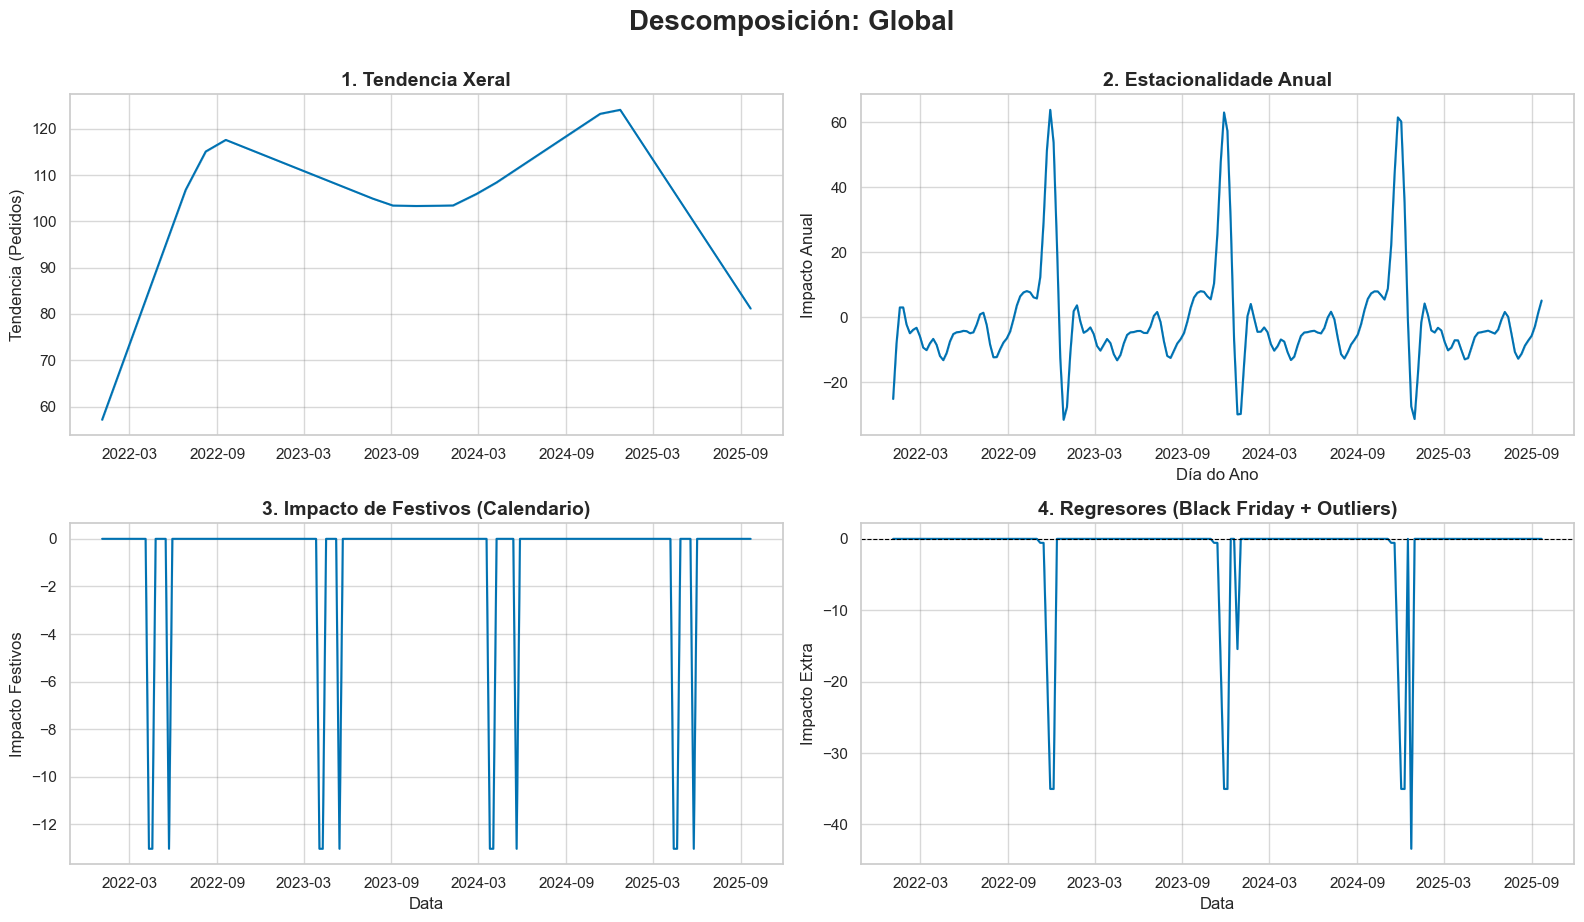

In [100]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Da mesma forma que fixemos para os modelos ARIMA, podemos pensar agora en axustar un modelo para cada cluster de clientes e ver se desta forma construímos un modelo mellor.

### Cluster 1:

Debemos repetir o proceso anterior para os datos do cluster 1, que recordemos que representaba aos clientes de transporte, retail e electrónica.

In [101]:
modelo = 'Cluster 1'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 1
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (2): ['bf_peak', 'bf_post']...
   Variables exóxenas detectadas (2): ['bf_peak', 'bf_post']


In [102]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['additive']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

17:01:58 - cmdstanpy - INFO - Chain [1] start processing
17:01:58 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 1 ---
🚀 Iniciando Grid Search con 64 combinacións...


17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:00 - cmdstanpy - INFO - Chain [1] start processing
17:02:00 - cmdstanpy - INFO - Chain [1] done processing
17:02:02 - cmdstanpy - INFO - Chain [1] start processing
17:02:02 - cmdstanpy - INFO - Chain [1] start processing
17:02:02 - cmdstanpy - INFO - Chain [1] done processing
17:02:02 - cmdstanpy - INFO - Chain [1]

   > Combinación 5/64: RMSE=18.3319


17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] done processing
17:02:10 - cmdstanpy - INFO - Chain [1] start processing
17:02:11 - cmdstanpy - INFO - Chain [1] done processing
17:02:12 - cmdstanpy - INFO - Chain [1] start processing
17:02:12 - cmdstanpy - INFO - Chain [1] done processing
17:02:12 - cmdstanpy - INFO - Chain [1] start processing
17:02:12 - cmdstanpy - INFO - Chain [1]

...

17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] done processing
17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] start processing
17:03:48 - cmdstanpy - INFO - Chain [1] done processing
17:03:48 - cmdstanpy - INFO - Chain [1] done processing
17:03:48 - cmdstanpy - INFO - Chain [1] done processing
17:03:48 - cmdstanpy - INFO - Chain [1] done processing
17:03:49 - cmdstanpy - INFO - Chain [1] done processing
17:03:49 - cmdstanpy - INFO - Chain [1] start processing
17:03:49 - cmdstanpy - INFO - Chain [1] done processing
17:03:51 - cmdstanpy - INFO - Chain [1] start processing
17:03:51 - cmdstanpy - INFO - Chain [1] start processing
17:03:51 - cmdstanpy - INFO - Chain [1] start processing
17:03:51 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=15.1280


17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] done processing
17:04:01 - cmdstanpy - INFO - Chain [1] done processing
17:04:01 - cmdstanpy - INFO - Chain [1] done processing
17:04:01 - cmdstanpy - INFO - Chain [1] done processing
17:04:01 - cmdstanpy - INFO - Chain [1] start processing
17:04:01 - cmdstanpy - INFO - Chain [1] done processing
17:04:02 - cmdstanpy - INFO - Chain [1] done processing
17:04:02 - cmdstanpy - INFO - Chain [1] start processing
17:04:02 - cmdstanpy - INFO - Chain [1] done processing
17:04:03 - cmdstanpy - INFO - Chain [1] start processing
17:04:03 - cmdstanpy - INFO - Chain [1] start processing
17:04:03 - cmdstanpy - INFO - Chain [1] start processing
17:04:03 - cmdstanpy - INFO - Chain [1


✅ Grid Search Completado.
   Mellor RMSE: 13.9096
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 0.01, 'holidays_prior_scale': 1.0, 'seasonality_mode': 'additive'}


17:04:09 - cmdstanpy - INFO - Chain [1] done processing


In [103]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Cluster 1 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=38.98


17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:56 - cmdstanpy - INFO - Chain [1] done processing
17:04:56 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1]

   > Semana 20/38: Pred=36.86


17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:57 - cmdstanpy - INFO - Chain [1] 

   > Semana 30/38: Pred=30.05


17:04:57 - cmdstanpy - INFO - Chain [1] start processing
17:04:57 - cmdstanpy - INFO - Chain [1] done processing
17:04:58 - cmdstanpy - INFO - Chain [1] start processing
17:04:58 - cmdstanpy - INFO - Chain [1] done processing
17:04:58 - cmdstanpy - INFO - Chain [1] start processing
17:04:58 - cmdstanpy - INFO - Chain [1] done processing
17:04:58 - cmdstanpy - INFO - Chain [1] start processing
17:04:58 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 1 ---


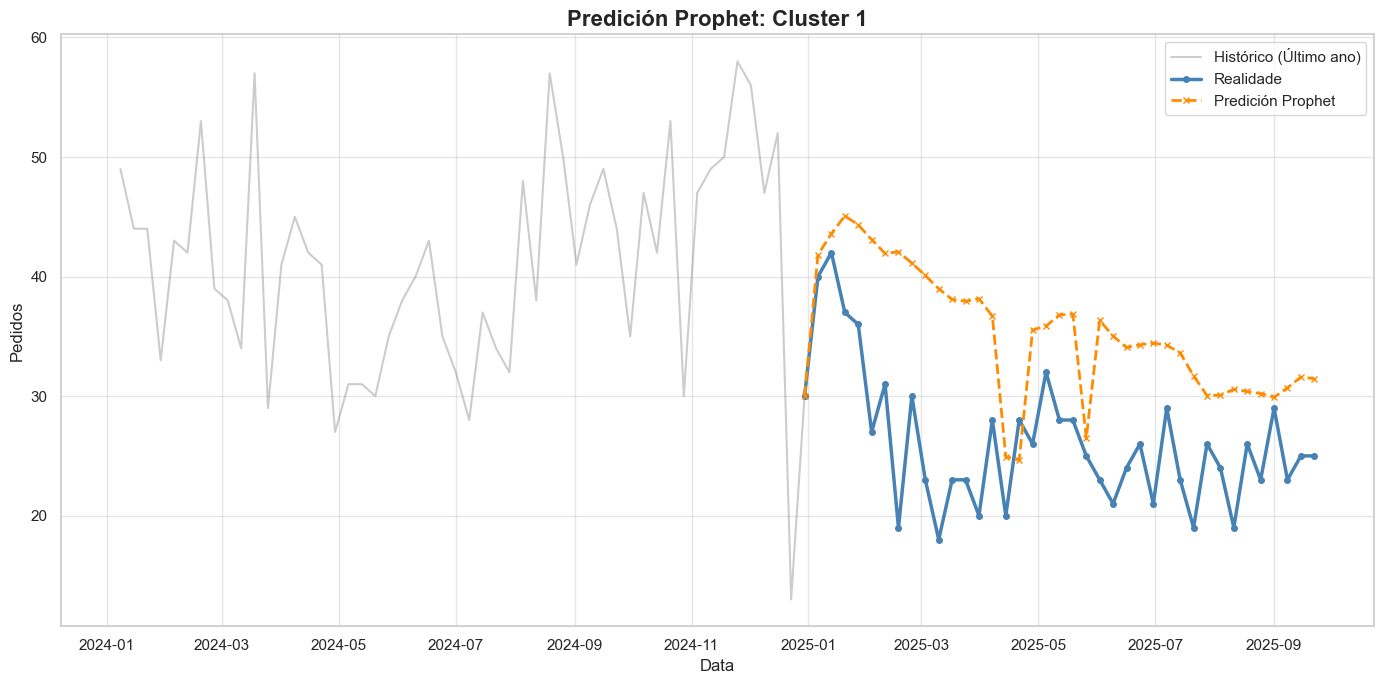

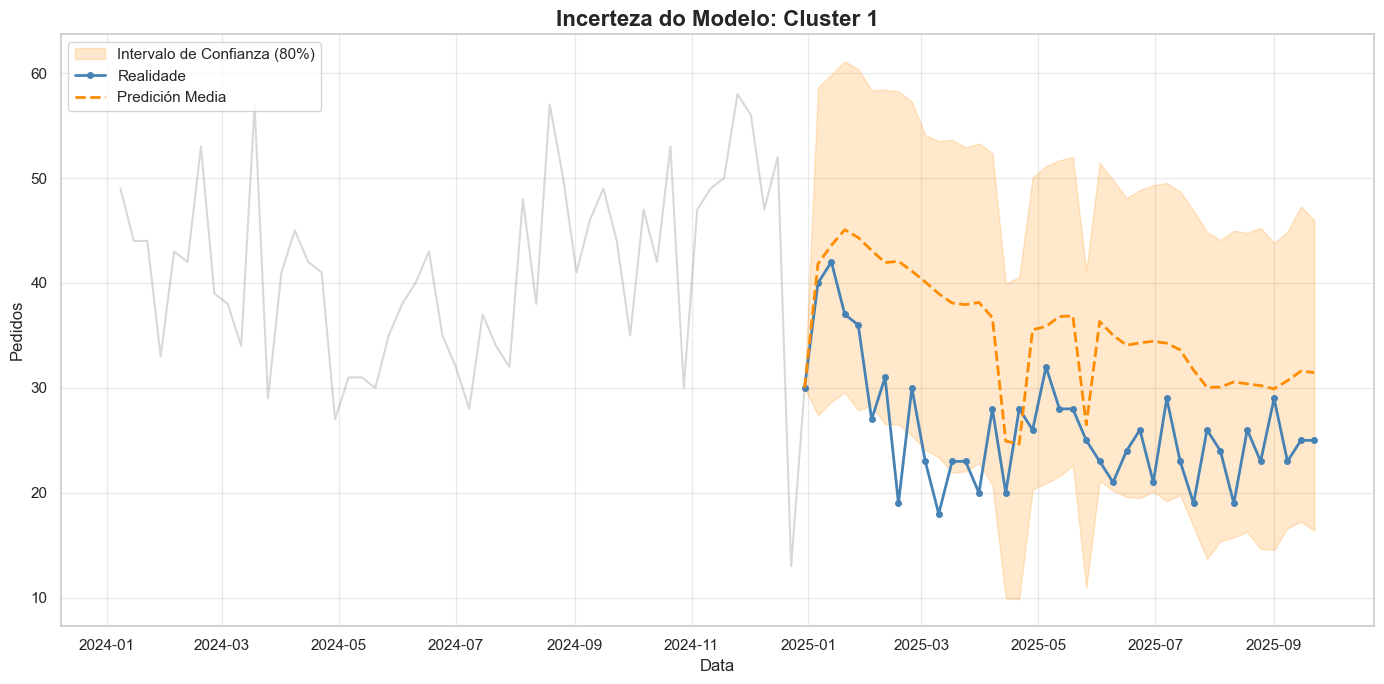

In [104]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [105]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 1 ---
MAE:  9.46
RMSE: 10.87
MAPE: 40.44%
MASE: 0.62 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como neste caso o MAPE é lixeiramente superior (40.44%) mais o MASE é bastante pequeno (0.62). 

17:27:38 - cmdstanpy - INFO - Chain [1] start processing
17:27:38 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


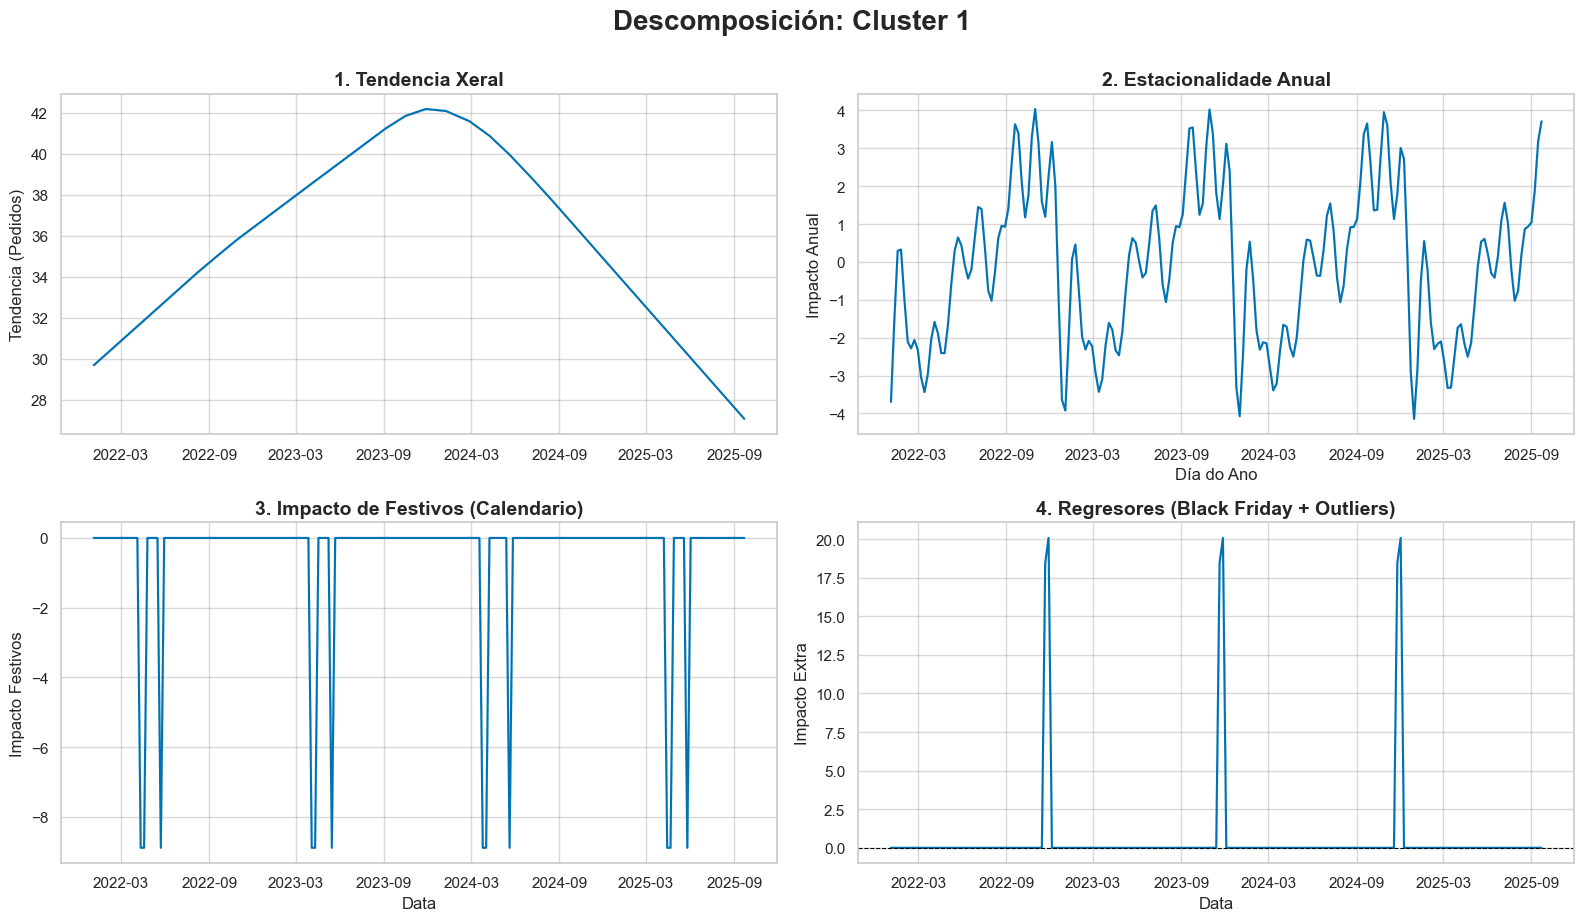

In [106]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Representemos as compoñentes do modelo (o último axutado no Rolling-Window)

### Cluster 2

Facemos o propio para os clientes do cluster 2, que estaba formado polos clientes de paquetería e froita:

In [107]:
modelo = 'Cluster 2'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 2
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']...
   Variables exóxenas detectadas (3): ['outlier_20220131', 'outlier_20241223', 'outlier_20231225']


In [108]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

18:06:56 - cmdstanpy - INFO - Chain [1] start processing
18:06:56 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 2 ---
🚀 Iniciando Grid Search con 64 combinacións...


18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
Optimization terminated abnormally. Falling back to Newton.
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - INFO - Chain [1] done processing
18:06:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:58 - 

   > Combinación 5/64: RMSE=13.9270


18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] done processing
18:07:08 - cmdstanpy - INFO - Chain [1] start processing
18:07:08 - 

...

18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] done processing
18:09:02 - cmdstanpy - INFO - Chain [1] done processing
18:09:02 - cmdstanpy - INFO - Chain [1] start processing
18:09:02 - cmdstanpy - INFO - Chain [1] done processing
18:09:02 - cmdstanpy - INFO - Chain [1] done processing
18:09:02 - cmdstanpy - INFO - Chain [1] done processing
18:09:03 - cmdstanpy - INFO - Chain [1] done processing
18:09:03 - cmdstanpy - INFO - Chain [1] start processing
18:09:03 - cmdstanpy - INFO - Chain [1] done processing
18:09:04 - cmdstanpy - INFO - Chain [1] start processing
18:09:04 - cmdstanpy - INFO - Chain [1] start processing
18:09:04 - cmdstanpy - INFO - Chain [1] start processing
18:09:05 - cmdstanpy - INFO - Chain [1

   > Combinación 60/64: RMSE=11.2383


18:09:16 - cmdstanpy - INFO - Chain [1] done processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] start processing
18:09:17 - cmdstanpy - INFO - Chain [1] done processing
18:09:17 - cmdstanpy - INFO - Chain [1] done processing
18:09:17 - cmdstanpy - INFO - Chain [1] done processing
18:09:18 - cmdstanpy - INFO - Chain [1] done processing
18:09:18 - cmdstanpy - INFO - Chain [1] done processing
18:09:18 - cmdstanpy - INFO - Chain [1] done processing
18:09:19 - cmdstanpy - INFO - Chain [1] start processing
18:09:19 - cmdstanpy - INFO - Chain [1] done processing
18:09:20 - cmdstanpy - INFO - Chain [1] start processing
18:09:20 - cmdstanpy - INFO - Chain [1] start processing
18:09:20 - cmdstanpy - INFO - Chain [1]


✅ Grid Search Completado.
   Mellor RMSE: 8.6413
   Parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 1.0, 'holidays_prior_scale': 0.01, 'seasonality_mode': 'multiplicative'}


18:09:28 - cmdstanpy - INFO - Chain [1] done processing


In [109]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing



--- 🔮 ROLLING WINDOW: Cluster 2 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1]

   > Semana 10/38: Pred=56.65


18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:52 - cmdstanpy - INFO - Chain [1] start processing
18:10:52 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=57.31


18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:53 - cmdstanpy - INFO - Chain [1] start processing
18:10:53 - cmdstanpy - INFO - Chain [1] done processing
18:10:54 - cmdstanpy - INFO - Chain [1] start processing
18:10:54 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=50.92


18:10:54 - cmdstanpy - INFO - Chain [1] start processing
18:10:54 - cmdstanpy - INFO - Chain [1] done processing
18:10:54 - cmdstanpy - INFO - Chain [1] start processing
18:10:54 - cmdstanpy - INFO - Chain [1] done processing
18:10:54 - cmdstanpy - INFO - Chain [1] start processing
18:10:54 - cmdstanpy - INFO - Chain [1] done processing
18:10:54 - cmdstanpy - INFO - Chain [1] start processing
18:10:54 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 2 ---


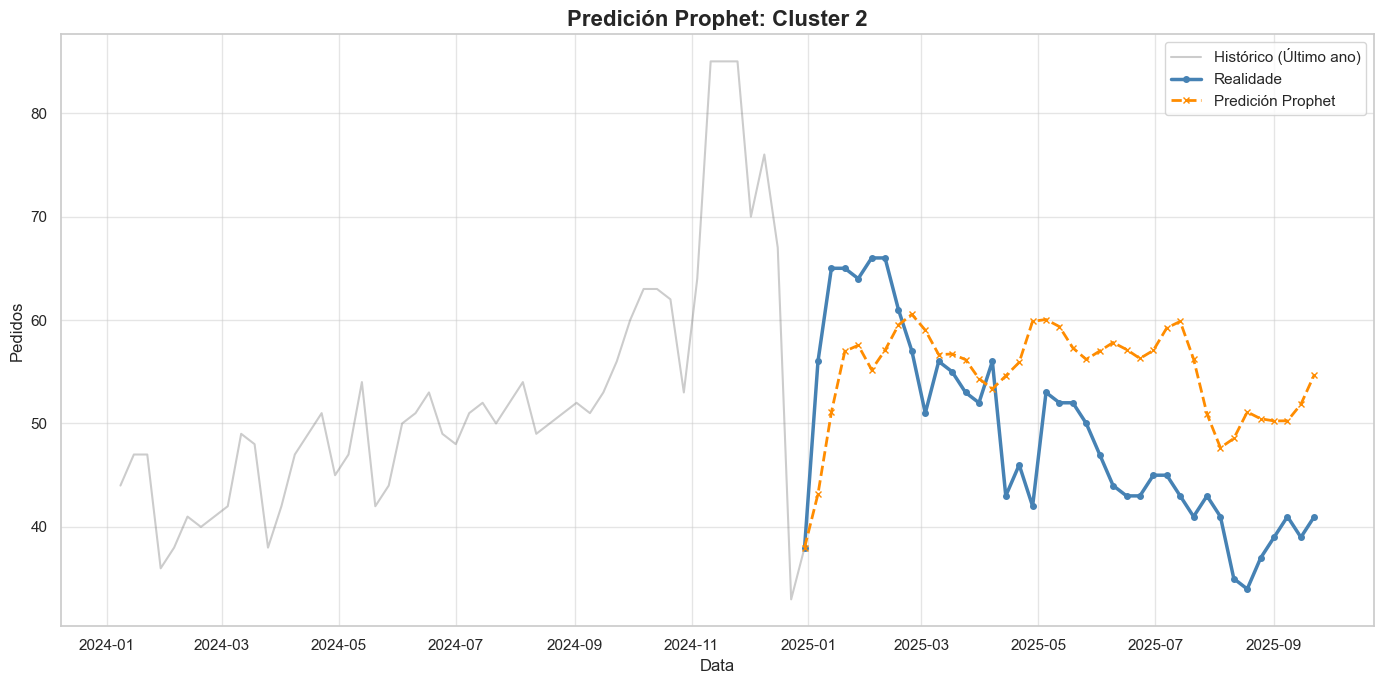

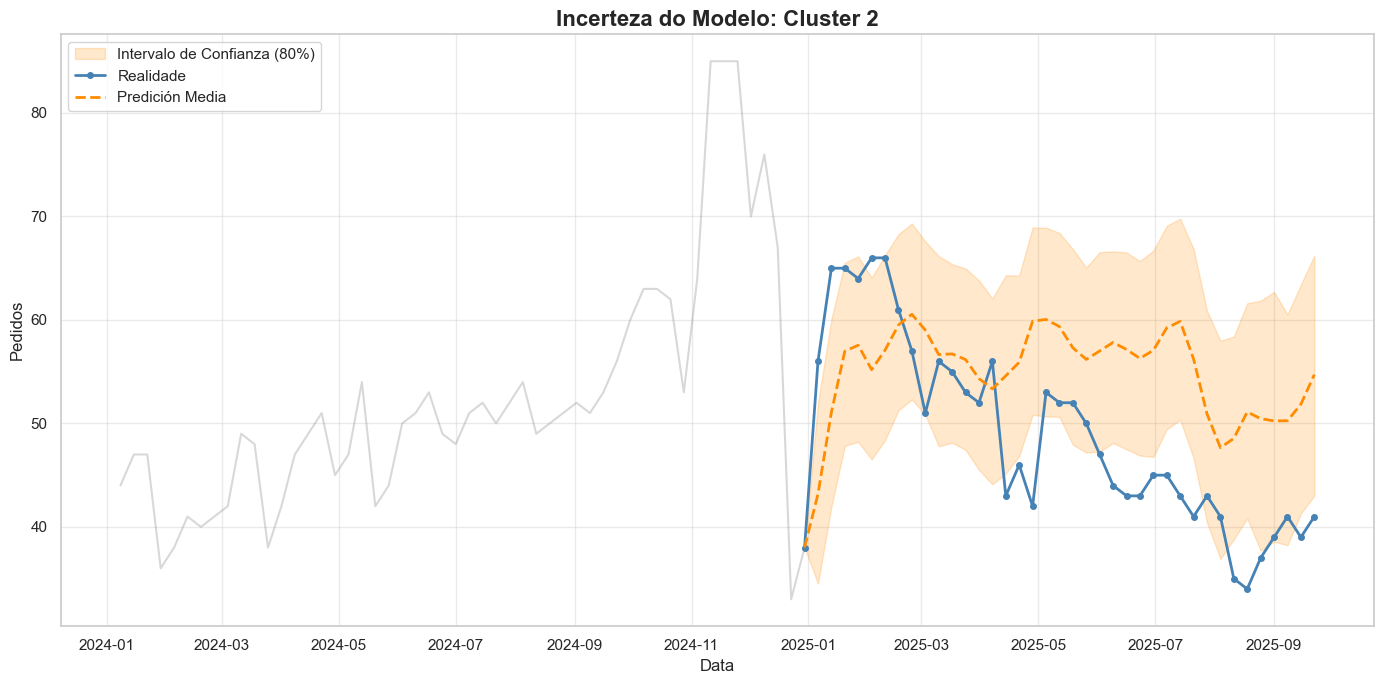

In [110]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [111]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 2 ---
MAE:  9.61
RMSE: 10.70
MAPE: 21.34%
MASE: 0.66 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


18:46:06 - cmdstanpy - INFO - Chain [1] start processing
18:46:06 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


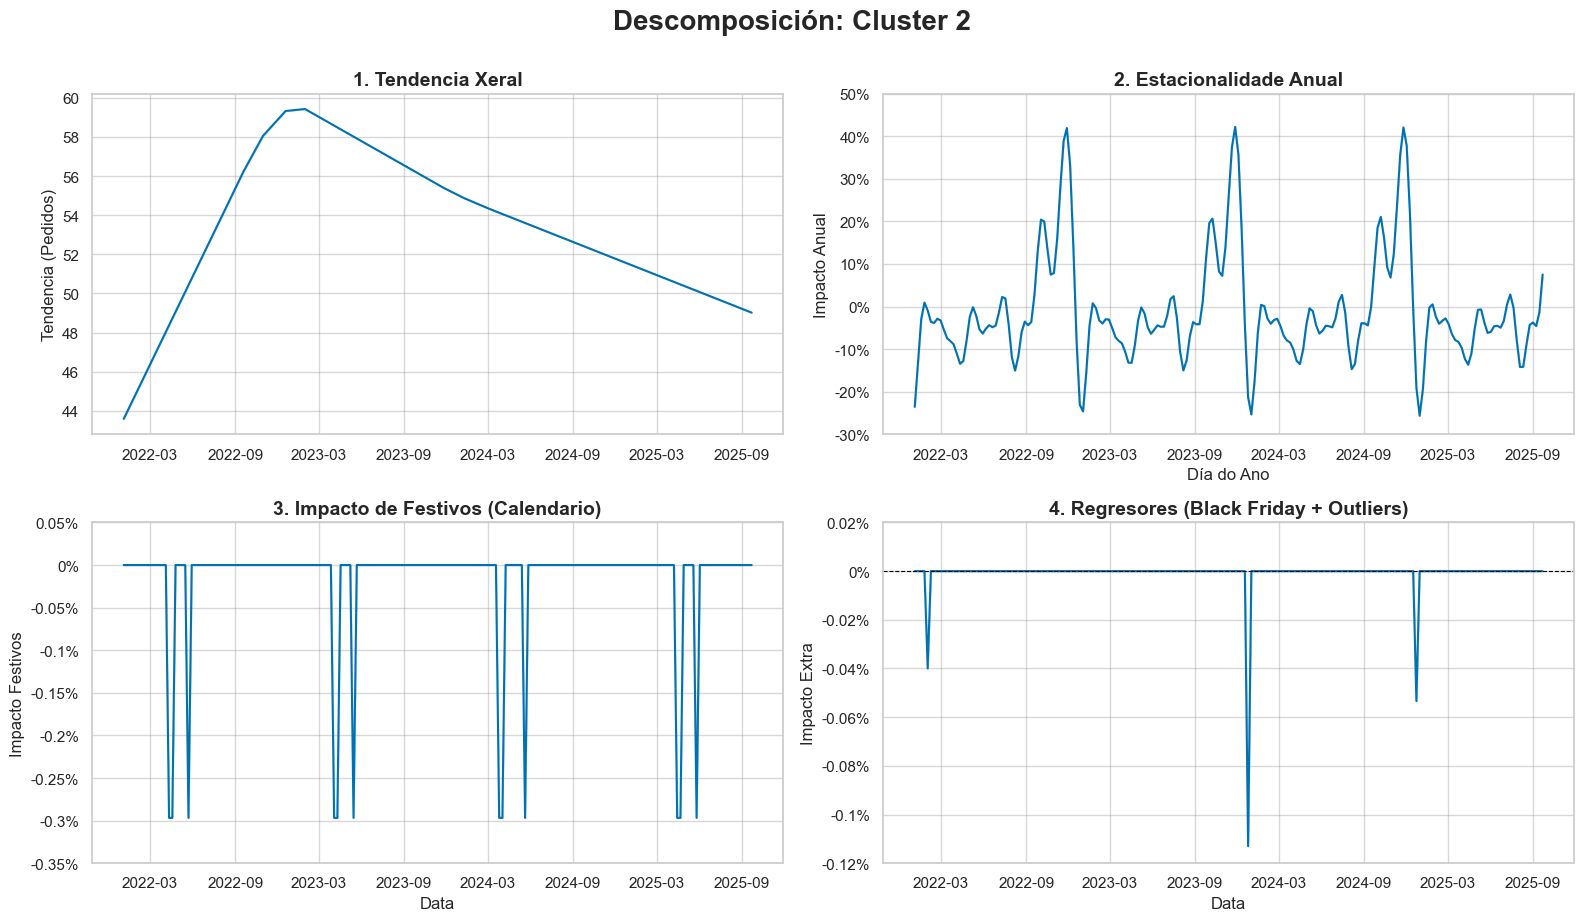

In [112]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Vemos como o MAPE = 17.91% e o MASE = 0.56. Novamente un bo modelo.

Representamos as compoñentes do modelo (o último axutado no Rolling-Window)

### Cluster 3

Por último, axustamos os modelos Prophet ao noso último cluster, que contén aos clientes de alimentación e industria:

Neste cluster aplicabamos transformación $log$ pola interpretación gráfica. Porén, como para este cluster nin o efecto do Black Friday nin os correspondentes outliers atopados eran significativos, empregar estacionalidade muktiplicativa pode causar malos resultados no Prophet.

Ademáis, por estos mesmos motivos (ausencia de regresores externos), á hora de establexer a malla de parámetros non deixamos que o modelo sexa moi conservador á hora de establecer os puntos de cambio, pois poderiamos caer nun problema de sobreaxuste aos datos de entrenamento.

In [113]:
modelo = 'Cluster 3'
print(f"\nINICIANDO PROCESO PARA: {modelo}")

resultados_prophet[modelo] = {}
# 1. Preparación Automática
# Esta función renomea columnas e detecta os regresores (bf_*, outlier_*)
resultados_prophet[modelo]['train_df'], resultados_prophet[modelo]['test_df'],resultados_prophet[modelo]['regresores'] = ft.preparar_datos_prophet_final(
    df_input=export_para_prophet[modelo], 
    fecha_corte='2024-12-30' # A mesma que en ARIMA
)
# Gardamos no dicionario

print(f"   Variables exóxenas detectadas ({len(resultados_prophet[modelo]['regresores'])}): {resultados_prophet[modelo]['regresores']}")


INICIANDO PROCESO PARA: Cluster 3
   🔧 Prophet Prep: Train=157, Test=38
   📌 Regresores detectados (0): []...
   Variables exóxenas detectadas (0): []


In [114]:
print(f"\n--- 🔧 TUNING: {modelo} ---")

# 1. Definimos a grella de busca
param_grid = {
    'changepoint_prior_scale': [0.5, 0.8, 0.9], 
    'seasonality_prior_scale': [0.01, 1.0, 5.0, 10.0],      
    'holidays_prior_scale':    [0.01, 1.0, 5.0, 10.0], 
    'seasonality_mode':        ['multiplicative']      # Global adoita ser estable -> Aditivo
}

# 2. Executamos Grid Search con Cross Validation
resultados_prophet[modelo]['params'], df_resultados_tuning = ft.realizar_tuning_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    param_grid=param_grid,
    metric='rmse',
    verbose=True
)
# Gardamos no dicionario

print(f"   ✅ Mellores parámetros: {resultados_prophet[modelo]['params']}")

19:12:52 - cmdstanpy - INFO - Chain [1] start processing
19:12:52 - cmdstanpy - INFO - Chain [1] done processing



--- 🔧 TUNING: Cluster 3 ---
🚀 Iniciando Grid Search con 48 combinacións...


19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:54 - cmdstanpy - INFO - Chain [1] start processing
19:12:54 - cmdstanpy - INFO - Chain [1] done processing
19:12:56 - cmdstanpy - INFO - Chain [1] start processing
19:12:56 - cmdstanpy - INFO - Chain [1] start processing
19:12:56 - cmdstanpy - INFO - Chain [1] start processing
19:12:56 - cmdstanpy - INFO - Chain [1

   > Combinación 5/48: RMSE=6.1089


19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:05 - cmdstanpy - INFO - Chain [1] start processing
19:13:05 - cmdstanpy - INFO - Chain [1] done processing
19:13:07 - cmdstanpy - INFO - Chain [1] start processing
19:13:07 - cmdstanpy - INFO - Chain [1] start processing
19:13:07 - cmdstanpy - INFO - Chain [1] start processing
19:13:07 - cmdstanpy - INFO - Chain [1

...

19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] start processing
19:14:30 - cmdstanpy - INFO - Chain [1] done processing
19:14:30 - cmdstanpy - INFO - Chain [1] done processing
19:14:30 - cmdstanpy - INFO - Chain [1] done processing
19:14:30 - cmdstanpy - INFO - Chain [1] done processing
19:14:30 - cmdstanpy - INFO - Chain [1] done processing
19:14:31 - cmdstanpy - INFO - Chain [1] done processing
19:14:31 - cmdstanpy - INFO - Chain [1] start processing
19:14:31 - cmdstanpy - INFO - Chain [1] done processing
19:14:32 - cmdstanpy - INFO - Chain [1] start processing
19:14:32 - cmdstanpy - INFO - Chain [1] start processing
19:14:32 - cmdstanpy - INFO - Chain [1] start processing
19:14:32 - cmdstanpy - INFO - Chain [1

   > Combinación 45/48: RMSE=6.2490


19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] start processing
19:14:43 - cmdstanpy - INFO - Chain [1] done processing
19:14:43 - cmdstanpy - INFO - Chain [1] done processing
19:14:43 - cmdstanpy - INFO - Chain [1] done processing
19:14:43 - cmdstanpy - INFO - Chain [1] done processing
19:14:43 - cmdstanpy - INFO - Chain [1] done processing
19:14:44 - cmdstanpy - INFO - Chain [1] done processing
19:14:44 - cmdstanpy - INFO - Chain [1] start processing
19:14:44 - cmdstanpy - INFO - Chain [1] done processing
19:14:45 - cmdstanpy - INFO - Chain [1] start processing
19:14:45 - cmdstanpy - INFO - Chain [1] start processing
19:14:45 - cmdstanpy - INFO - Chain [1] start processing
19:14:45 - cmdstanpy - INFO - Chain [1


✅ Grid Search Completado.
   Mellor RMSE: 5.7767
   Parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}
   ✅ Mellores parámetros: {'changepoint_prior_scale': 0.8, 'seasonality_prior_scale': 5.0, 'holidays_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}


19:14:49 - cmdstanpy - INFO - Chain [1] done processing


In [115]:
print(f"\n--- 🔮 ROLLING WINDOW: {modelo} ---")

# 1. Execución
resultados_prophet[modelo]['df_rw'] = ft.rolling_window_prophet(
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    regresores=resultados_prophet[modelo]['regresores'],
    holidays_df=df_festivos_prophet,
    params=resultados_prophet[modelo]['params'], # Usamos os que gañaron no tuning
    verbose=True
)

19:15:40 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing



--- 🔮 ROLLING WINDOW: Cluster 3 ---
🚀 Iniciando Prophet Rolling Window (38 pasos)...


19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] 

   > Semana 10/38: Pred=27.23


19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:41 - cmdstanpy - INFO - Chain [1] start processing
19:15:41 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] 

   > Semana 20/38: Pred=17.25


19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:42 - cmdstanpy - INFO - Chain [1] start processing
19:15:42 - cmdstanpy - INFO - Chain [1]

   > Semana 30/38: Pred=19.15


19:15:42 - cmdstanpy - INFO - Chain [1] done processing
19:15:43 - cmdstanpy - INFO - Chain [1] start processing
19:15:43 - cmdstanpy - INFO - Chain [1] done processing
19:15:43 - cmdstanpy - INFO - Chain [1] start processing
19:15:43 - cmdstanpy - INFO - Chain [1] done processing
19:15:43 - cmdstanpy - INFO - Chain [1] start processing
19:15:43 - cmdstanpy - INFO - Chain [1] done processing
19:15:43 - cmdstanpy - INFO - Chain [1] start processing
19:15:43 - cmdstanpy - INFO - Chain [1] done processing



--- 📊 ANÁLISE GRÁFICA: Cluster 3 ---


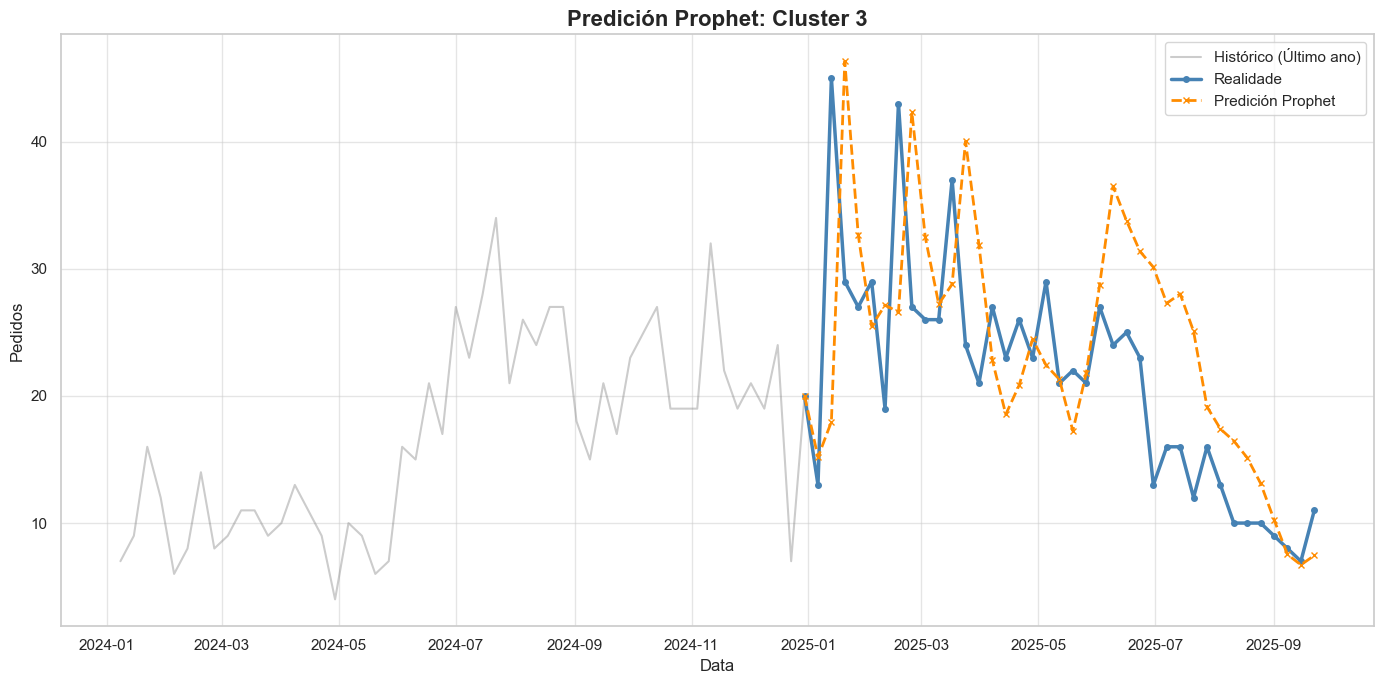

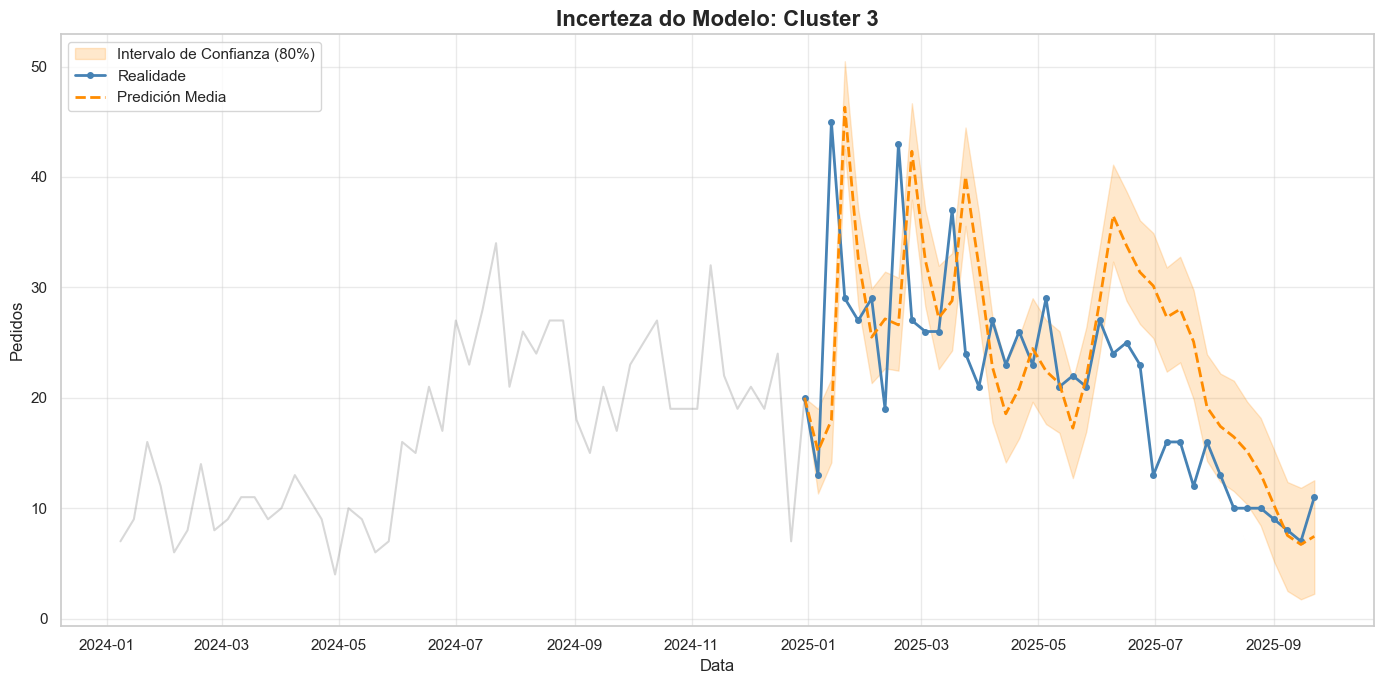

In [116]:
print(f"\n--- 📊 ANÁLISE GRÁFICA: {modelo} ---")

# A. Predición vs Realidade (Estilo ARIMA)
ft.plot_prophet_rolling(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Predición Prophet: {modelo}"
)

# B. Intervalos de Confianza (Exclusivo Prophet)
ft.plot_prophet_intervalos(
    train_df=resultados_prophet[modelo]['train_df'],
    results_df=resultados_prophet[modelo]['df_rw'],
    titulo=f"Incerteza do Modelo: {modelo}"
)

In [117]:
# 2. Cálculo de Métricas (Reutilizamos a función do TFM)
# Necesitamos Series con índice datetime para a función
resultados_prophet[modelo]['metricas'] = ft.calcular_metricas_completas(
    y_true=resultados_prophet[modelo]['df_rw'].set_index('ds')['y'],
    y_pred=resultados_prophet[modelo]['df_rw'].set_index('ds')['yhat'],
    y_train=resultados_prophet[modelo]['train_df'].set_index('ds')['y'],
    m=52, # Ciclo anual
    etiqueta=f"Prophet - {modelo}"
)

--- 📊 AVALIACIÓN: Prophet - Cluster 3 ---
MAE:  7.34
RMSE: 9.50
MAPE: 35.84%
MASE: 0.97 (Estacional (m=52))
✅ CONCLUSIÓN: O modelo aporta valor (MASE < 1).


Vemos como o MAPE é relativamente elevado (35.84 %), por estar avaliando valores baixos (erros de apenas 6 pedidos son tan significativos). Porén, vemos un mellor comportamento do modelo fronte ao preditor naïve estacional (MASE = 0.97).

19:15:57 - cmdstanpy - INFO - Chain [1] start processing
19:15:57 - cmdstanpy - INFO - Chain [1] done processing


   🎨 Xerando compoñentes...


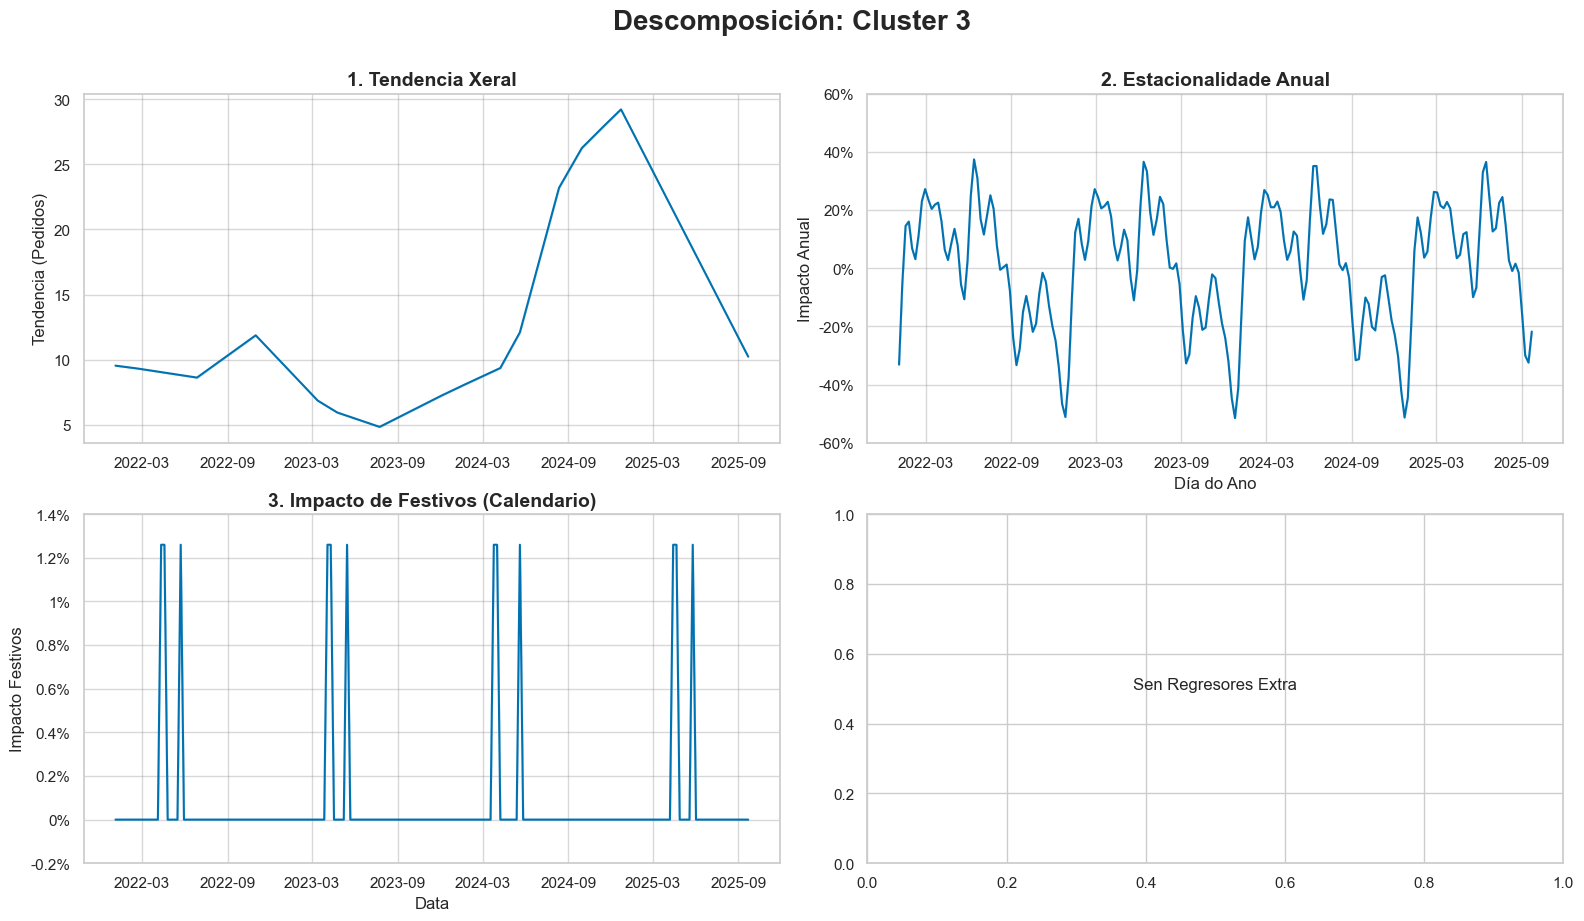

In [118]:
# C. Compoñentes (Para entender que aprendeu)
# Necesitamos recuperar o modelo 'm' da última iteración. 
# Como a función rolling non o devolve, podemos adestrar un rápido coa historia completa
# ou modificala. O máis rápido para ver compoñentes é adestrar un modelo final:
print("   🎨 Xerando compoñentes...")
m_final = ft.entrenar_prophet(
    pd.concat([resultados_prophet[modelo]['train_df'], 
               resultados_prophet[modelo]['test_df']]), # Adestramos con todo para ver a foto completa
    resultados_prophet[modelo]['regresores'], 
    holidays=df_festivos_prophet, 
    **resultados_prophet[modelo]['params']
)

ft.plot_componentes_prophet_custom(
    model=m_final,
    train_df=resultados_prophet[modelo]['train_df'],
    test_df=resultados_prophet[modelo]['test_df'],
    titulo=f"Descomposición: {modelo}"
)

Representamos as compoñentes do modelo:

In [228]:
print(resultados_prophet['Cluster 1']['metricas'])
print(resultados_prophet['Cluster 2']['metricas'])
print(resultados_prophet['Cluster 3']['metricas'])
print(resultados_prophet['Global']['metricas'])

{'MAE': 9.459882611648183, 'RMSE': np.float64(10.873328633731933), 'MAPE': np.float64(40.44098891124806), 'MASE': np.float64(0.6158014099337007)}
{'MAE': 9.610879593619105, 'RMSE': np.float64(10.699361799348175), 'MAPE': np.float64(21.336508075512477), 'MASE': np.float64(0.6634729502498395)}
{'MAE': 7.338288801921543, 'RMSE': np.float64(9.504615058727063), 'MAPE': np.float64(35.84144713820159), 'MASE': np.float64(0.9704286199014635)}
{'MAE': 16.32421337818235, 'RMSE': np.float64(19.43229373800728), 'MAPE': np.float64(18.695044449324982), 'MASE': np.float64(0.7262891545377741)}


In [226]:
modelo = 'Cluster 3'
print(datos_arima[modelo]['metricas'])
print(resultados_prophet[modelo]['metricas'])

{'MAE': 2.7310301163926307, 'RMSE': np.float64(3.4512055939239485), 'MAPE': np.float64(18.464094548614224), 'MASE': np.float64(0.8419776643423921)}
{'MAE': 7.338288801921543, 'RMSE': np.float64(9.504615058727063), 'MAPE': np.float64(35.84144713820159), 'MASE': np.float64(0.9704286199014635)}


#### Comparación de rendementos:

Da mesma forma que fixemos nos ARIMA, podemos comparar os resultados do modelo Prophet xeral coa ponderación dos modelos por Cluster:

--- ⚖️ COMPARATIVA FINAL: GLOBAL vs CLUSTERS PONDERADOS ---
Volume Total: 19869 pedidos.
Pesos calculados:
   > Cluster 1: 35.30%
   > Cluster 2: 51.94%
   > Cluster 3: 12.76%

Métrica    | Modelo Único    | Clusters Pond.  | Mellora
------------------------------------------------------------
MAE        | 16.32           | 9.27            | +7.06  ✅
RMSE       | 19.43           | 10.61           | +8.82  ✅
MAPE       | 18.70         % | 29.93         % | -11.24% ❌
MASE       | 0.73            | 0.69            | +0.04  ✅


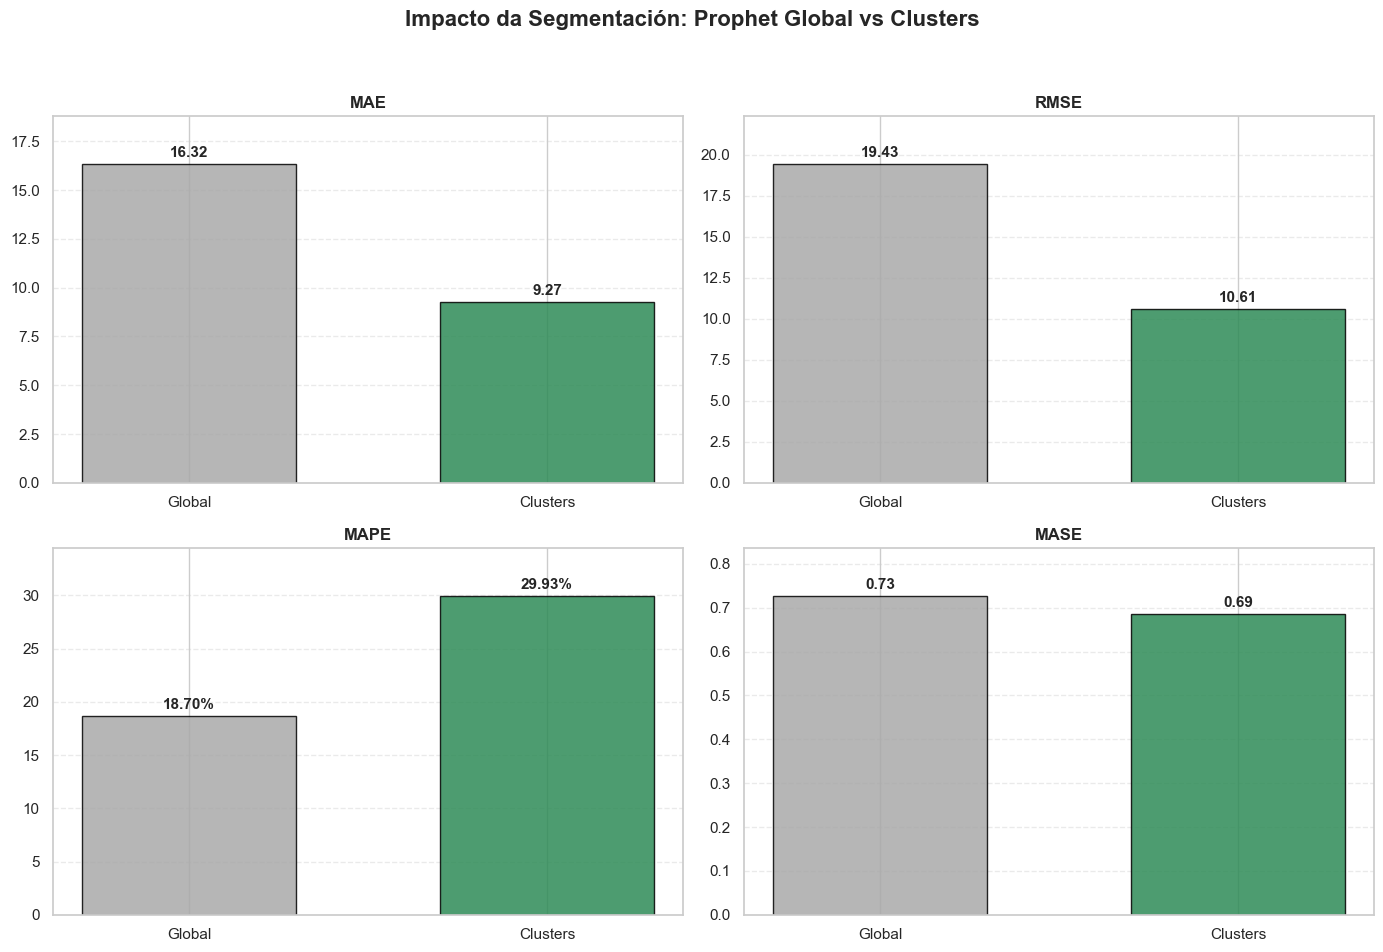

In [227]:
print("--- ⚖️ COMPARATIVA FINAL: GLOBAL vs CLUSTERS PONDERADOS ---")

# 1. CÁLCULO DOS PESOS (Baseado no volume real de pedidos)
# Usamos o dicionario 'datos' orixinal para saber canto pesa cada cluster
volumen_total = datos['Global']['n_pedidos'].sum()

clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
lista_metricas = []

print(f"Volume Total: {volumen_total} pedidos.")
print("Pesos calculados:")

for c in clusters:
    # A. Calculamos o peso do cluster
    vol_cluster = datos[c]['n_pedidos'].sum()
    peso = vol_cluster / volumen_total
    print(f"   > {c}: {peso:.2%}")
    
    # B. Recuperamos as métricas gardadas
    # NOTA: Se para o Cluster 3 gardaches as métricas "Sen Q1" no paso anterior,
    # este código usaráas automaticamente.
    m = resultados_prophet[c]['metricas']
    
    lista_metricas.append({
        'Cluster': c,
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE'],
        'MASE': m['MASE'],
        'Peso': peso
    })

# Convertemos a DataFrame para facilitar o cálculo
df_comp = pd.DataFrame(lista_metricas)

# 2. CÁLCULO PONDERADO (A media dos clusters axustada polo seu tamaño)
w_mae  = (df_comp['MAE'] * df_comp['Peso']).sum()
w_rmse = (df_comp['RMSE'] * df_comp['Peso']).sum()
w_mape = (df_comp['MAPE'] * df_comp['Peso']).sum()
w_mase = (df_comp['MASE'] * df_comp['Peso']).sum()

# 3. RECUPERAMOS MÉTRICAS DO GLOBAL
met_global = resultados_prophet['Global']['metricas']

# 4. TÁBOA DE RESULTADOS NUMÉRICOS
print("\n" + "="*60)
print(f"{'Métrica':<10} | {'Modelo Único':<15} | {'Clusters Pond.':<15} | {'Mellora'}")
print("-" * 60)

# Función auxiliar para imprimir filas
def print_row(name, val_g, val_w, is_percent=False):
    diff = val_g - val_w
    # Se a diferenza é positiva, o erro baixou (Mellora ✅)
    icon = "✅" if diff > 0 else "❌"
    
    if is_percent:
        print(f"{name:<10} | {val_g:<14.2f}% | {val_w:<14.2f}% | {diff:+.2f}% {icon}")
    else:
        print(f"{name:<10} | {val_g:<14.2f}  | {val_w:<14.2f}  | {diff:+.2f}  {icon}")

print_row("MAE", met_global['MAE'], w_mae)
print_row("RMSE", met_global['RMSE'], w_rmse)
print_row("MAPE", met_global['MAPE'], w_mape, is_percent=True)
print_row("MASE", met_global['MASE'], w_mase)
print("="*60)

# 5. VISUALIZACIÓN GRÁFICA
metrics_names = ['MAE', 'RMSE', 'MAPE', 'MASE']
vals_global = [met_global['MAE'], met_global['RMSE'], met_global['MAPE'], met_global['MASE']]
vals_weighted = [w_mae, w_rmse, w_mape, w_mase]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Impacto da Segmentación: Prophet Global vs Clusters', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()
colors = ['#A9A9A9', '#2E8B57'] # Gris (Global) vs Verde (Clusters)

for i, metric in enumerate(metrics_names):
    ax = axes_flat[i]
    
    # Pintamos as barras
    bars = ax.bar(['Global', 'Clusters'], [vals_global[i], vals_weighted[i]], 
                  color=colors, alpha=0.85, edgecolor='black', width=0.6)
    
    # Títulos e Estética
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Engadimos o valor enriba da barra
    fmt = '%.2f%%' if metric == 'MAPE' else '%.2f'
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=11, fontweight='bold')
    
    # Marges para que non toque o teito
    ax.set_ylim(0, max(vals_global[i], vals_weighted[i]) * 1.15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

{'MAE': 7.895479296102856, 'RMSE': np.float64(11.123920773395263), 'MAPE': np.float64(8.181451733730235), 'MASE': np.float64(0.5958852298945552)}
{'MAE': 7.338288801921543, 'RMSE': np.float64(9.504615058727063), 'MAPE': np.float64(35.84144713820159), 'MASE': np.float64(0.9704286199014635)}
